# Panel Builder – S&P 500 (2015–2025)

Este notebook construye el panel final firm-month utilizado en las estimaciones econométricas.

Input:
- data/raw/ (insumos Refinitiv descargados por ETL)

Output principal:
- data/clean/panel_master.parquet

Outputs auxiliares:
- data/clean/data_dictionary.csv
- data/clean/lineage_log.csv
- outputs/logs/panel_build_*.log
- outputs/qa/qa_report.md

El notebook NO estima modelos.

## 1) Imports


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import logging
from datetime import datetime
from typing import Dict, List

## 2) Configuración y Paths

Input:
- data/raw/

Output:
- data/clean/panel_master.parquet

Notas:
- Todos los paths son relativos al root del proyecto.

In [2]:
from pathlib import Path

def detect_project_root(markers=("requirements.txt", ".git", "README.md")) -> Path:
    """
    Detecta el root del repo buscando 'markers' hacia arriba desde el cwd.
    Funciona si corrés el notebook desde /notebooks o desde el root.
    """
    here = Path.cwd().resolve()
    for parent in [here] + list(here.parents):
        if any((parent / m).exists() for m in markers):
            return parent
    return here  # fallback

# Root del proyecto (robusto)
PROJECT_ROOT = detect_project_root()

RAW      = PROJECT_ROOT / "data" / "raw"
CLEAN    = PROJECT_ROOT / "data" / "clean"
INTERIM  = PROJECT_ROOT / "data" / "intermediate"

OUTPUTS  = PROJECT_ROOT / "outputs"
LOGS     = OUTPUTS / "logs"
QA       = OUTPUTS / "qa"

# Crear directorios necesarios
for p in [RAW, INTERIM, CLEAN, LOGS, QA]:
    p.mkdir(parents=True, exist_ok=True)

PANEL_PATH = CLEAN / "panel_master.parquet"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("RAW         =", RAW)
print("CLEAN       =", CLEAN)
print("OUTPUTS     =", OUTPUTS)

PROJECT_ROOT = C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main
RAW         = C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw
CLEAN       = C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\clean
OUTPUTS     = C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs


In [3]:
mp = pd.read_parquet(INTERIM / "market_power_monthly.parquet")
print(mp.columns.tolist())

share_cols = [c for c in mp.columns if "market_share" in c]
print("\nVariables market share en market_power_monthly:")
print(share_cols)

print("\nMissingness:")
print(mp[share_cols].isna().mean().sort_values(ascending=False))

['ticker', 'date', 'sector', 'revenue', 'total_sales_all', 'sector_sales', 'industry_group_sales', 'industry_sales', 'subindustry_sales', 'gics_sector_name', 'gics_industry_group_name', 'gics_industry_name', 'gics_subindustry_name', 'market_share_raw', 'market_share_w', 'market_share_sector', 'market_share_industry_group', 'market_share_industry', 'market_share_subindustry']

Variables market share en market_power_monthly:
['market_share_raw', 'market_share_w', 'market_share_sector', 'market_share_industry_group', 'market_share_industry', 'market_share_subindustry']

Missingness:
market_share_raw               0.0
market_share_w                 0.0
market_share_sector            0.0
market_share_industry_group    0.0
market_share_industry          0.0
market_share_subindustry       0.0
dtype: float64


## 3) Logging

In [4]:
log_file = LOGS / f"panel_build_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

logging.basicConfig(
    filename=log_file,
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Inicio Panel Builder")

In [5]:
print("PROJECT_ROOT =", PROJECT_ROOT)
print("RAW         =", RAW, RAW.exists())
print("INTERIM     =", INTERIM, INTERIM.exists())
print("CLEAN       =", CLEAN, CLEAN.exists())

for folder in [RAW, INTERIM, CLEAN]:
    print(f"\n--- {folder} ---")
    if folder.exists():
        for f in sorted(folder.glob("*")):
            print(f.name)

PROJECT_ROOT = C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main
RAW         = C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw True
INTERIM     = C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate True
CLEAN       = C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\clean True

--- C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw ---
bonds_empresas
bonds_meta.csv
bonds_meta.parquet
cds_spreads_daily.parquet
company_metadata.csv
company_metadata.parquet
equity_prices_daily.csv
equity_prices_daily.parquet
fundamentals_extended_q.csv
fundamentals_extended_q.parquet
fundamentals_with_market_share.csv
fundamentals_with_market_share_sp500.csv
gics_industry_group_sales_quarterly_sp500.csv
iboxx_credit_indices_daily.parquet
iboxx_credit_indices_monthly.parquet
macro_controls_daily.csv
macro_controls_daily.parquet
market_power_proxies_focus_quarterly.csv
market_power_proxies_sp500_quarterly.csv
market_prices_daily.csv
market_pri

## 4) Carga de insumos

Input:
- spreads bonos
- curvas UST
- equity returns
- fundamentals
- índices crediticios
- mappings sectoriales

Chequeos:
- assert no vacío
- rango temporal esperado

In [6]:
from pathlib import Path
from typing import Dict
import pandas as pd
import logging

def read_dataset(filename: str, folders: list[Path]) -> pd.DataFrame:
    """
    Busca un archivo en varias carpetas y lo lee.
    Soporta .parquet y .csv según extensión.
    """
    tried = []

    for folder in folders:
        path = folder / filename
        tried.append(str(path))
        if path.exists():
            print(f"📂 Leyendo: {path}")
            if path.suffix == ".parquet":
                return pd.read_parquet(path)
            elif path.suffix == ".csv":
                return pd.read_csv(path)

    raise FileNotFoundError(
        f"No se encontró {filename} en ninguna de estas ubicaciones:\n" + "\n".join(tried)
    )

def audit_df(df: pd.DataFrame, name: str):
    print(f"\n{'='*80}")
    print(f"AUDIT: {name}")
    print(f"{'='*80}")

    print("shape:", df.shape)

    key_candidates = ["issuer", "ticker", "ric", "ric_base", "isin", "cusip", "date", "period_end"]
    present_keys = [c for c in key_candidates if c in df.columns]
    print("key-like cols:", present_keys)

    for dcol in ["date", "period_end"]:
        if dcol in df.columns:
            s = pd.to_datetime(df[dcol], errors="coerce")
            print(f"{dcol}: min={s.min()} max={s.max()} nulls={s.isna().sum()}")

    for c in ["issuer", "ticker", "ric", "ric_base", "isin", "cusip"]:
        if c in df.columns:
            print(f"{c}: unique={df[c].nunique(dropna=True)} nulls={df[c].isna().sum()}")

    print("\nhead:")
    print(df.head(2))

def load_base_inputs() -> Dict[str, pd.DataFrame]:
    data = {}

    # Orden de búsqueda: clean -> intermediate -> raw
    search_order = [CLEAN, INTERIM, RAW]

    data["spreads_raw"] = read_dataset("oas_spreads_monthly_bond.parquet", search_order)
    data["equity_daily"] = read_dataset("equity_returns_daily.parquet", search_order)
    data["market_daily"] = read_dataset("market_prices_daily.parquet", search_order)
    data["fundamentals_q"] = read_dataset("fundamentals_extended_q.parquet", search_order)
    data["company_metadata"] = read_dataset("company_metadata.parquet", search_order)

    for name, df in data.items():
        assert not df.empty, f"{name} vacío"
        logging.info(f"{name} cargado: {df.shape}")
        print(f"✅ {name}: {df.shape}")
        audit_df(df, name)

    return data

raw_data = load_base_inputs()



📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\oas_spreads_monthly_bond.parquet
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\clean\equity_returns_daily.parquet
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\market_prices_daily.parquet
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\fundamentals_extended_q.parquet
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\company_metadata.parquet
✅ spreads_raw: (331272, 5)

AUDIT: spreads_raw
shape: (331272, 5)
key-like cols: ['date']
date: min=2015-01-05 00:00:00 max=2025-12-31 00:00:00 nulls=3643

head:
     bond_ric       date  oas_bps     Issuer Ticker
0  001055AD4= 2015-01-30    209.7  AFLAC INC    AFL
1  001055AD4= 2015-02-27    196.8  AFLAC INC    AFL
✅ equity_daily: (1336936, 5)

AUDIT: equity_daily
shape: (1336936, 5)
key-like cols: ['ric', 'date']
date: min=2015-01-05 00:00:00 max=2025-12-31 00:00:00 nul

In [7]:
def audit_keys_detail(df: pd.DataFrame, name: str):
    print(f"\n{'#'*100}")
    print(f"DETAIL AUDIT: {name}")
    print(f"{'#'*100}")

    print("shape:", df.shape)
    print("\ncolumns:")
    print(list(df.columns))

    for c in ["issuer", "Issuer", "ticker", "Ticker", "ric", "ric_base", "bond_ric", "Instrument", "isin", "cusip"]:
        if c in df.columns:
            print(f"\nColumn: {c}")
            print("  nulls :", df[c].isna().sum())
            print("  unique:", df[c].nunique(dropna=True))
            print("  sample:", df[c].dropna().astype(str).head(5).tolist())

    for dcol in ["date", "period_end"]:
        if dcol in df.columns:
            s = pd.to_datetime(df[dcol], errors="coerce")
            print(f"\nDate col: {dcol}")
            print("  min   :", s.min())
            print("  max   :", s.max())
            print("  nulls :", s.isna().sum())

    # duplicados por combinaciones razonables
    candidate_keys = [
        ["Issuer", "date"],
        ["Ticker", "date"],
        ["ric", "date"],
        ["ticker", "date"],
        ["issuer", "date"],
        ["bond_ric", "date"],
        ["Instrument", "date"],
        ["ticker", "period_end"],
        ["issuer", "period_end"],
    ]

    print("\nDuplicate checks:")
    for keys in candidate_keys:
        if all(k in df.columns for k in keys):
            dup = df.duplicated(keys).sum()
            print(f"  duplicates by {keys}: {dup}")

    print("\nhead:")
    print(df.head(3))

audit_keys_detail(raw_data["spreads_raw"], "spreads_raw")
audit_keys_detail(raw_data["equity_daily"], "equity_daily")
audit_keys_detail(raw_data["fundamentals_q"], "fundamentals_q")
audit_keys_detail(raw_data["company_metadata"], "company_metadata")



####################################################################################################
DETAIL AUDIT: spreads_raw
####################################################################################################
shape: (331272, 5)

columns:
['bond_ric', 'date', 'oas_bps', 'Issuer', 'Ticker']

Column: Issuer
  nulls : 0
  unique: 341
  sample: ['AFLAC INC', 'AFLAC INC', 'AFLAC INC', 'AFLAC INC', 'AFLAC INC']

Column: Ticker
  nulls : 0
  unique: 328
  sample: ['AFL', 'AFL', 'AFL', 'AFL', 'AFL']

Column: bond_ric
  nulls : 0
  unique: 9448
  sample: ['001055AD4=', '001055AD4=', '001055AD4=', '001055AD4=', '001055AD4=']

Date col: date
  min   : 2015-01-05 00:00:00
  max   : 2025-12-31 00:00:00
  nulls : 3643

Duplicate checks:
  duplicates by ['Issuer', 'date']: 300345
  duplicates by ['Ticker', 'date']: 300354
  duplicates by ['bond_ric', 'date']: 0

head:
     bond_ric       date  oas_bps     Issuer Ticker
0  001055AD4= 2015-01-30    209.7  AFLAC INC    AFL
1  001055AD

In [8]:
df = raw_data["spreads_raw"].copy()

# -------------------------------------------------
# 1. ¿Cuántos bonos por issuer-date?
# -------------------------------------------------
tmp = df.groupby(["Issuer", "date"])["bond_ric"].nunique()

print("\nBonos por issuer-date:")
print(tmp.describe())

# -------------------------------------------------
# 2. Duplicados exactos
# -------------------------------------------------
print("\nDuplicados por bond_ric-date:")
print(df.duplicated(["bond_ric", "date"]).sum())

# -------------------------------------------------
# 3. NaT en fechas
# -------------------------------------------------
print("\nNaT en date:", df["date"].isna().sum())

# -------------------------------------------------
# 4. Distribución de fechas
# -------------------------------------------------
print("\nFechas únicas (sample):")
print(sorted(df["date"].dropna().unique())[:10])


Bonos por issuer-date:
count    30740.000000
mean        10.658068
std         28.153496
min          1.000000
25%          2.000000
50%          4.000000
75%         10.000000
max        724.000000
Name: bond_ric, dtype: float64

Duplicados por bond_ric-date:
0

NaT en date: 3643

Fechas únicas (sample):
[Timestamp('2015-01-05 00:00:00'), Timestamp('2015-01-13 00:00:00'), Timestamp('2015-01-27 00:00:00'), Timestamp('2015-01-29 00:00:00'), Timestamp('2015-01-30 00:00:00'), Timestamp('2015-02-23 00:00:00'), Timestamp('2015-02-24 00:00:00'), Timestamp('2015-02-26 00:00:00'), Timestamp('2015-02-27 00:00:00'), Timestamp('2015-03-16 00:00:00')]


## 4.1) Construcción puente de `bonds_monthly_spreads`

Este bloque construye un archivo intermedio `bonds_monthly_spreads.parquet` a partir del insumo disponible `oas_spreads_monthly_bond.parquet`.

### Objetivo

Compatibilizar los outputs del notebook de descargas (`01_descarga_datos.ipynb`) con la lógica esperada por el notebook de construcción del panel (`02_construccion_panel.ipynb`), sin reescribir la estructura completa del pipeline.

### Qué hace

- Lee la serie mensual de OAS por bono descargada desde Refinitiv.
- Estandariza nombres de columnas al formato esperado por la sección de spreads.
- Crea la variable `spread_bps` usando `oas_bps` como proxy de spread mensual por bono.
- Completa columnas requeridas por el pipeline aunque no estén disponibles en esta etapa:
  - `ytm`
  - `residual_maturity_years`
- Genera un archivo de metadata mínima de bonos (`bonds_meta.parquet`) para que el bloque siguiente pueda hacer el merge sin error.
- Guarda los outputs en disco para que el resto del notebook corra sin cambios.

### Nota metodológica

En esta versión puente, el spread por bono proviene del **Option-Adjusted Spread (OAS)** descargado directamente desde Refinitiv.  
Por eso, `spread_bps = oas_bps`.

Las columnas `ytm` y `residual_maturity_years` se dejan como faltantes (`NaN`) si no están disponibles en los insumos actuales. Esto permite preservar la estructura del pipeline sin alterar la lógica principal de agregación firm-month.

In [9]:
# ==========================================================
# 4.1 Cargar bonds_monthly_spreads desde CLEAN
# - usa únicamente el archivo enriquecido generado en notebook 01
# - armoniza nombres de columnas reales del archivo
# - guarda copia operativa en INTERIM
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ----------------------------------------------------------
# Helpers
# ----------------------------------------------------------
def standardize_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out

def to_eom(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s, errors="coerce").dt.to_period("M").dt.to_timestamp("M")

def read_any(path: Path) -> pd.DataFrame:
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    elif path.suffix == ".csv":
        return pd.read_csv(path)
    else:
        raise ValueError(f"Formato no soportado: {path}")

def coalesce_first_nonnull(df: pd.DataFrame, candidates: list[str]) -> pd.Series:
    valid = [c for c in candidates if c in df.columns]
    if not valid:
        return pd.Series(pd.NA, index=df.index, dtype="object")

    out = df[valid[0]].copy()
    for c in valid[1:]:
        out = out.fillna(df[c])
    return out

def ensure_expected_columns_from_clean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # ------------------------------------------------------
    # Armonización basada en las columnas reales observadas
    # ------------------------------------------------------
    out["issuer"] = coalesce_first_nonnull(out, ["issuer", "Issuer", "Issuer_x", "Issuer_y"]).astype("string").str.strip()
    out["ticker"] = coalesce_first_nonnull(out, ["ticker", "Ticker", "Ticker_x", "Ticker_y"]).astype("string").str.strip()

    if "bond_ric" not in out.columns:
        if "Instrument" in out.columns:
            out["bond_ric"] = out["Instrument"]
        else:
            raise KeyError("No encontré bond_ric ni Instrument en el archivo de CLEAN.")

    if "date" not in out.columns:
        raise KeyError("No encontré la columna date en el archivo de CLEAN.")

    # spread
    if "spread_bps" not in out.columns:
        if "oas" in out.columns:
            out["spread_bps"] = out["oas"]
        elif "oas_bps" in out.columns:
            out["spread_bps"] = out["oas_bps"]
        else:
            raise KeyError("No encontré spread_bps ni oas/oas_bps en el archivo de CLEAN.")

    # columnas opcionales pero esperadas
    if "ytm" not in out.columns:
        out["ytm"] = np.nan

    if "residual_maturity_years" not in out.columns:
        out["residual_maturity_years"] = np.nan

    if "amount_issued" not in out.columns:
        out["amount_issued"] = np.nan

    # ------------------------------------------------------
    # Tipos
    # ------------------------------------------------------
    out["bond_ric"] = out["bond_ric"].astype("string").str.strip()
    out["date"] = to_eom(out["date"])

    for c in ["spread_bps", "ytm", "residual_maturity_years", "amount_issued"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    # limpiar strings vacíos
    for c in ["issuer", "ticker", "bond_ric"]:
        out[c] = out[c].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

    # ------------------------------------------------------
    # Selección final
    # ------------------------------------------------------
    out = (
        out[
            [
                "issuer",
                "ticker",
                "bond_ric",
                "date",
                "spread_bps",
                "ytm",
                "residual_maturity_years",
                "amount_issued",
            ]
        ]
        .dropna(subset=["issuer", "bond_ric", "date", "spread_bps"])
        .drop_duplicates(subset=["bond_ric", "date"])
        .sort_values(["issuer", "bond_ric", "date"])
        .reset_index(drop=True)
    )

    return out

# ----------------------------------------------------------
# 0) Paths
# ----------------------------------------------------------
CLEAN_BONDS_PARQ = CLEAN / "bonds_monthly_spreads.parquet"
CLEAN_BONDS_CSV  = CLEAN / "bonds_monthly_spreads.csv"

OUT_BONDS_PARQ = INTERIM / "bonds_monthly_spreads.parquet"
OUT_BONDS_CSV  = INTERIM / "bonds_monthly_spreads.csv"

# ----------------------------------------------------------
# 1) Leer SOLO desde CLEAN
# ----------------------------------------------------------
if CLEAN_BONDS_PARQ.exists():
    source_used = CLEAN_BONDS_PARQ
elif CLEAN_BONDS_CSV.exists():
    source_used = CLEAN_BONDS_CSV
else:
    raise FileNotFoundError(
        f"No encontré bonds_monthly_spreads en CLEAN:\n{CLEAN_BONDS_PARQ}\n{CLEAN_BONDS_CSV}"
    )

raw_clean = read_any(source_used)
raw_clean = standardize_cols(raw_clean)

print(f"\n📂 Fuente original utilizada: {source_used}")
print("\nColumnas originales:")
print(raw_clean.columns.tolist())

# ----------------------------------------------------------
# 2) Armonizar columnas y construir dataset operativo
# ----------------------------------------------------------
bonds_monthly_spreads = ensure_expected_columns_from_clean(raw_clean)

# ----------------------------------------------------------
# 3) Guardar copia operativa en INTERIM
# ----------------------------------------------------------
bonds_monthly_spreads.to_parquet(OUT_BONDS_PARQ, index=False)
bonds_monthly_spreads.to_csv(OUT_BONDS_CSV, index=False)

print(f"\n✅ Archivo operativo guardado en INTERIM:")
print(OUT_BONDS_PARQ)
print(OUT_BONDS_CSV)

# ----------------------------------------------------------
# 4) QA final del archivo que efectivamente se usará
# ----------------------------------------------------------
print("\n=== bonds_monthly_spreads preview ===")
print(bonds_monthly_spreads.head())

print("\nFilas:", len(bonds_monthly_spreads))
print("Bond RIC únicos:", bonds_monthly_spreads["bond_ric"].nunique())
print("Issuer únicos:", bonds_monthly_spreads["issuer"].nunique())
print("Rango fechas:", bonds_monthly_spreads["date"].min(), "->", bonds_monthly_spreads["date"].max())

print("\n=== QA bonds_monthly_spreads ===")
print("Shape:", bonds_monthly_spreads.shape)

print("\nDuplicados bond_ric-date:",
      bonds_monthly_spreads.duplicated(["bond_ric", "date"]).sum())

print("Duplicados issuer-date:",
      bonds_monthly_spreads.duplicated(["issuer", "date"]).sum())

print("\nBonos por issuer-date:")
print(
    bonds_monthly_spreads
    .groupby(["issuer", "date"])["bond_ric"]
    .nunique()
    .describe()
)

print("\nMissing por columna (%):")
print((bonds_monthly_spreads.isna().mean() * 100).sort_values(ascending=False))

print("\nSpreads negativos:")
print((bonds_monthly_spreads["spread_bps"] < 0).sum())

print("\nSpread_bps summary:")
print(bonds_monthly_spreads["spread_bps"].describe())

print("\nYTM summary:")
print(bonds_monthly_spreads["ytm"].describe())
print("YTM missing (%):", round(bonds_monthly_spreads["ytm"].isna().mean() * 100, 2))

print("\nResidual maturity summary:")
print(bonds_monthly_spreads["residual_maturity_years"].describe())
print("Residual maturity missing (%):", round(bonds_monthly_spreads["residual_maturity_years"].isna().mean() * 100, 2))

print("\nTicker por issuer:")
issuer_ticker_map = (
    bonds_monthly_spreads[["issuer", "ticker"]]
    .dropna()
    .drop_duplicates()
)
print(issuer_ticker_map.groupby("issuer")["ticker"].nunique().describe())
print("Issuers con más de 1 ticker:",
      (issuer_ticker_map.groupby("issuer")["ticker"].nunique() > 1).sum())

# ----------------------------------------------------------
# 5) Crear bonds_meta para que el siguiente bloque no falle
# ----------------------------------------------------------
meta_candidates = [
    CLEAN / "bonds_universe_full.parquet",
    CLEAN / "bonds_universe_full.csv",
    RAW / "bonds_universe_full.parquet",
    RAW / "bonds_universe_full.csv",
]

meta_path = None
for p in meta_candidates:
    if p.exists():
        meta_path = p
        break

if meta_path is not None:
    bonds_meta = read_any(meta_path)
    bonds_meta = standardize_cols(bonds_meta)

    meta_rename = {}
    for c in bonds_meta.columns:
        cl = c.lower().strip()
        if cl == "issuer":
            meta_rename[c] = "issuer"
        elif cl == "ticker":
            meta_rename[c] = "ticker"
        elif cl in {"bond_ric", "ric", "source_ric", "instrument"}:
            meta_rename[c] = "bond_ric"

    bonds_meta = bonds_meta.rename(columns=meta_rename)

    if "issuer" not in bonds_meta.columns and "Issuer" in bonds_meta.columns:
        bonds_meta["issuer"] = bonds_meta["Issuer"]
    if "ticker" not in bonds_meta.columns and "Ticker" in bonds_meta.columns:
        bonds_meta["ticker"] = bonds_meta["Ticker"]

    keep_cols = [c for c in bonds_meta.columns if c in {"issuer", "ticker", "bond_ric", "sector_source"}]
    bonds_meta = bonds_meta[keep_cols].drop_duplicates(subset=["bond_ric"]).copy()

else:
    bonds_meta = (
        bonds_monthly_spreads[["issuer", "ticker", "bond_ric"]]
        .drop_duplicates(subset=["bond_ric"])
        .copy()
    )

print("\n=== QA bonds_meta ===")
print("Shape:", bonds_meta.shape)
print("Duplicados bond_ric:", bonds_meta.duplicated(["bond_ric"]).sum())

if {"issuer", "ticker"}.issubset(bonds_meta.columns):
    tmp_map = bonds_meta[["issuer", "ticker"]].dropna().drop_duplicates()
    print("Issuers con más de 1 ticker en bonds_meta:",
          (tmp_map.groupby("issuer")["ticker"].nunique() > 1).sum())

OUT_META_PARQ = RAW / "bonds_meta.parquet"
OUT_META_CSV  = RAW / "bonds_meta.csv"

bonds_meta.to_parquet(OUT_META_PARQ, index=False)
bonds_meta.to_csv(OUT_META_CSV, index=False)

print(f"\n✅ Guardado bonds_meta en:\n{OUT_META_PARQ}\n{OUT_META_CSV}")
print("\n=== bonds_meta preview ===")
print(bonds_meta.head())


📂 Fuente original utilizada: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\clean\bonds_monthly_spreads.parquet

Columnas originales:
['bond_ric', 'date', 'oas', 'Issuer_x', 'Ticker_x', 'Maturity', 'Issuer_y', 'Ticker_y', 'ISIN', 'Coupon', 'Principal_Currency', 'Amount_Issued_USD', 'source_file', 'residual_maturity_years']

✅ Archivo operativo guardado en INTERIM:
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\bonds_monthly_spreads.parquet
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\bonds_monthly_spreads.csv

=== bonds_monthly_spreads preview ===
                issuer ticker    bond_ric       date  spread_bps  ytm  \
0  ABBOTT LABORATORIES    ABT  002819AC4= 2015-01-31       134.6  NaN   
1  ABBOTT LABORATORIES    ABT  002819AC4= 2015-02-28       142.7  NaN   
2  ABBOTT LABORATORIES    ABT  002819AC4= 2015-03-31       148.6  NaN   
3  ABBOTT LABORATORIES    ABT  002819AC4= 2015-04-30       165.0  NaN   
4  ABBOTT LAB

## 5) Spreads por firma

Input:
- bonds_monthly_spreads

Output:
- spread firm-month

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

# -------------------------------------------------
# Helpers de IO (parquet/csv)
# -------------------------------------------------
def load_any_existing(candidates: list[Path]) -> tuple[pd.DataFrame, Path]:
    for p in candidates:
        if p.exists():
            if p.suffix == ".parquet":
                return pd.read_parquet(p), p
            elif p.suffix == ".csv":
                return pd.read_csv(p), p
    raise FileNotFoundError(
        "No se encontró ninguno de los archivos candidatos:\n" +
        "\n".join(str(p) for p in candidates)
    )

def coerce_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

# -------------------------------------------------
# Inputs (prioridad: INTERIM -> CLEAN -> RAW)
# -------------------------------------------------
BONDS_SPREADS_CANDIDATES = [
    INTERIM / "bonds_monthly_spreads.parquet",
    CLEAN   / "bonds_monthly_spreads.parquet",
    RAW     / "bonds_monthly_spreads.parquet",
    INTERIM / "bonds_monthly_spreads.csv",
    CLEAN   / "bonds_monthly_spreads.csv",
    RAW     / "bonds_monthly_spreads.csv",
]

bonds, bonds_source_path = load_any_existing(BONDS_SPREADS_CANDIDATES)
bonds = bonds.copy()

print(f"\n📂 Leyendo bonds desde: {bonds_source_path}")

# -------------------------------------------------
# Limpieza básica
# -------------------------------------------------
bonds["date"] = pd.to_datetime(bonds["date"], errors="coerce")
bonds["issuer"] = bonds["issuer"].astype("string").str.strip()
bonds["bond_ric"] = bonds["bond_ric"].astype("string").str.strip()

if "ticker" in bonds.columns:
    bonds["ticker"] = bonds["ticker"].astype("string").str.strip()

bonds = coerce_numeric(bonds, ["spread_bps", "ytm", "residual_maturity_years", "amount_issued"])

# QA rápido antes del drop
print("\n=== QA previo del archivo leído ===")
print("Columnas:", bonds.columns.tolist())

if "residual_maturity_years" in bonds.columns:
    print("\nResumen residual_maturity_years (raw):")
    print(bonds["residual_maturity_years"].describe())
    print("NA% residual_maturity_years:", round(bonds["residual_maturity_years"].isna().mean() * 100, 2))
else:
    print("\n⚠️ No existe la columna residual_maturity_years en el archivo leído.")

if "ytm" in bonds.columns:
    print("\nResumen ytm (raw):")
    print(bonds["ytm"].describe())
    print("NA% ytm:", round(bonds["ytm"].isna().mean() * 100, 2))

bonds = (
    bonds
    .dropna(subset=["issuer", "bond_ric", "date", "spread_bps"])
    .drop_duplicates(subset=["bond_ric", "date"])
    .sort_values(["issuer", "bond_ric", "date"])
    .copy()
)

print("\n=== bonds (spreads por bono) — preview ===")
print(bonds.head(5))

print("\n=== QA input bonds ===")
print("Shape:", bonds.shape)
print("Duplicados bond_ric-date:", bonds.duplicated(["bond_ric", "date"]).sum())
print("Duplicados issuer-date:", bonds.duplicated(["issuer", "date"]).sum())
print("Issuers únicos:", bonds["issuer"].nunique())
print("Bond RIC únicos:", bonds["bond_ric"].nunique())
print("Rango fechas:", bonds["date"].min(), "->", bonds["date"].max())

if "residual_maturity_years" in bonds.columns:
    print("\nResumen residual_maturity_years (post-clean):")
    print(bonds["residual_maturity_years"].describe())
    print("NA% residual_maturity_years:", round(bonds["residual_maturity_years"].isna().mean() * 100, 2))

# -------------------------------------------------
# Detectar columna de monto (si existe)
# -------------------------------------------------
amount_candidates = [
    c for c in bonds.columns
    if "amount" in c.lower() and ("issued" in c.lower() or "issue" in c.lower())
]
if not amount_candidates:
    amount_candidates = [c for c in bonds.columns if "amount" in c.lower()]
amount_col = amount_candidates[0] if amount_candidates else None

print("\namount_col detectada:", amount_col)

# -------------------------------------------------
# Función agregadora issuer-date
# -------------------------------------------------
def agg_func(df: pd.DataFrame) -> pd.Series:
    if amount_col and amount_col in df.columns:
        w = pd.to_numeric(df[amount_col], errors="coerce")
    else:
        w = pd.Series(np.nan, index=df.index)

    out = {}

    # spread promedio
    if w.notna().sum() > 0 and w.sum() > 0:
        out["spread_mean_bps"] = np.average(df["spread_bps"], weights=w)
    else:
        out["spread_mean_bps"] = df["spread_bps"].mean()

    # ytm promedio
    if "ytm" in df.columns:
        y = pd.to_numeric(df["ytm"], errors="coerce")
        if w.notna().sum() > 0 and w.sum() > 0 and y.notna().sum() > 0:
            mask = y.notna() & w.notna()
            out["ytm_mean"] = np.average(y[mask], weights=w[mask]) if mask.sum() > 0 and w[mask].sum() > 0 else y.mean()
        else:
            out["ytm_mean"] = y.mean()
    else:
        out["ytm_mean"] = np.nan

    # maturidad residual promedio
    if "residual_maturity_years" in df.columns:
        m = pd.to_numeric(df["residual_maturity_years"], errors="coerce")
        if w.notna().sum() > 0 and w.sum() > 0 and m.notna().sum() > 0:
            mask = m.notna() & w.notna()
            out["residual_maturity_mean"] = np.average(m[mask], weights=w[mask]) if mask.sum() > 0 and w[mask].sum() > 0 else m.mean()
        else:
            out["residual_maturity_mean"] = m.mean()
    else:
        out["residual_maturity_mean"] = np.nan

    # contar bonos distintos
    out["n_bonds"] = df["bond_ric"].nunique()

    return pd.Series(out)

# -------------------------------------------------
# Agregar a nivel empresa-fecha
# -------------------------------------------------
bonds_monthly_spreads_firm = (
    bonds
    .groupby(["issuer", "date"], as_index=False)
    .apply(agg_func)
    .reset_index(drop=True)
    .sort_values(["issuer", "date"])
)

# -------------------------------------------------
# QA output firm-month
# -------------------------------------------------
print("\n=== QA bonds_monthly_spreads_firm ===")
print("Shape:", bonds_monthly_spreads_firm.shape)
print("Duplicados issuer-date:", bonds_monthly_spreads_firm.duplicated(["issuer", "date"]).sum())
print("Issuers únicos:", bonds_monthly_spreads_firm["issuer"].nunique())
print("Rango fechas:", bonds_monthly_spreads_firm["date"].min(), "->", bonds_monthly_spreads_firm["date"].max())

print("\nMissing por columna (%):")
print((bonds_monthly_spreads_firm.isna().mean() * 100).sort_values(ascending=False))

print("\nResumen spread_mean_bps:")
print(bonds_monthly_spreads_firm["spread_mean_bps"].describe())

print("\nSpreads negativos firm-level:")
print((bonds_monthly_spreads_firm["spread_mean_bps"] < 0).sum())

print("\nResumen n_bonds:")
print(bonds_monthly_spreads_firm["n_bonds"].describe())

if "residual_maturity_mean" in bonds_monthly_spreads_firm.columns:
    print("\nResumen residual_maturity_mean:")
    print(bonds_monthly_spreads_firm["residual_maturity_mean"].describe())
    print("NA% residual_maturity_mean:", round(bonds_monthly_spreads_firm["residual_maturity_mean"].isna().mean() * 100, 2))

print("\nPreview firm-level:")
print(bonds_monthly_spreads_firm.head())

# -------------------------------------------------
# Guardar intermedio
# -------------------------------------------------
OUT_FIRM_PARQ = INTERIM / "bonds_monthly_spreads_firmlevel.parquet"
OUT_FIRM_CSV  = INTERIM / "bonds_monthly_spreads_firmlevel.csv"

bonds_monthly_spreads_firm.to_parquet(OUT_FIRM_PARQ, index=False)
bonds_monthly_spreads_firm.to_csv(OUT_FIRM_CSV, index=False)

print(f"\n✅ Firm-level spreads guardado:\n{OUT_FIRM_PARQ}\n{OUT_FIRM_CSV}")


📂 Leyendo bonds desde: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\bonds_monthly_spreads.parquet

=== QA previo del archivo leído ===
Columnas: ['issuer', 'ticker', 'bond_ric', 'date', 'spread_bps', 'ytm', 'residual_maturity_years', 'amount_issued']

Resumen residual_maturity_years (raw):
count    327629.000000
mean         13.376371
std           8.256595
min           0.229979
25%           6.543463
50%          10.954141
75%          20.041068
max          37.659138
Name: residual_maturity_years, dtype: float64
NA% residual_maturity_years: 0.0

Resumen ytm (raw):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: ytm, dtype: float64
NA% ytm: 100.0

=== bonds (spreads por bono) — preview ===
                issuer ticker    bond_ric       date  spread_bps  ytm  \
0  ABBOTT LABORATORIES    ABT  002819AC4= 2015-01-31       134.6  NaN   
1  ABBOTT LABORATORIES    ABT  002819AC4= 2015-02-28       142

### 5.1) QA spreads

In [11]:
# =====================================================
# QA básica de spreads (sanity check) – MISMA CELDA QUE TENÍAS
# =====================================================
df = bonds.copy()

print("\n--- Estadísticas generales ---")
print(df["spread_bps"].describe())

print("\n--- NAs en spread_bps ---")
print(df["spread_bps"].isna().mean())

print("\n--- Conteo de bonos únicos ---")
print("n bond_ric:", df["bond_ric"].nunique())

print("\n--- Conteo de emisores únicos ---")
print("n issuer:", df["issuer"].nunique())

print("\n--- Rango temporal ---")
print(df["date"].min(), "→", df["date"].max())

print("\n--- Checks por issuer-date (pre-aggregate) ---")
tmp = df.groupby(["issuer", "date"]).size()
print("issuer-date grupos:", tmp.shape[0])
print("max filas por issuer-date:", tmp.max())


--- Estadísticas generales ---
count      327629.0
mean     143.300153
std      111.914424
min        -20800.1
25%            94.7
50%           138.3
75%           182.8
max          6427.7
Name: spread_bps, dtype: Float64

--- NAs en spread_bps ---
0.0

--- Conteo de bonos únicos ---
n bond_ric: 5805

--- Conteo de emisores únicos ---
n issuer: 271

--- Rango temporal ---
2015-01-31 00:00:00 → 2025-12-31 00:00:00

--- Checks por issuer-date (pre-aggregate) ---
issuer-date grupos: 28701
max filas por issuer-date: 724


## 6. Mapping issuer → ticker → sector

Input:
- Carpeta con excels `bonds_empresas/` (provenientes del proceso de bonos / armado manual)

Output:
- `data/clean/issuer_ticker_sector.parquet`
- `data/clean/issuer_ticker_sector.csv`

Chequeos:
- Se encuentra la carpeta `bonds_empresas/`
- Columnas mínimas detectadas: issuer + (ticker y/o sector)
- Deduplicación por issuer

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def _normalize_colname(c: str) -> str:
    return str(c).strip().lower().replace(" ", "_")

def _clean_str(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.strip()
    return s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

def _base_ticker(s: pd.Series) -> pd.Series:
    s = _clean_str(s).str.upper()

    # Quitar sufijo tipo RIC equity: A.N -> A ; MSFT.OQ -> MSFT
    s = s.str.replace(r"\..*$", "", regex=True)

    # Normalizaciones útiles por consistencia
    s = s.str.replace("/", ".", regex=False)
    s = s.str.replace("-", ".", regex=False)

    return s

# -------------------------------------------------
# 1) Fuente 1: bonds -> issuer / ticker
# -------------------------------------------------
BONDS_FILE = PROJECT_ROOT / "data" / "inputs" / "new_bonds" / "bonds_sp500_filtered.parquet"
if not BONDS_FILE.exists():
    raise FileNotFoundError(f"No encontré {BONDS_FILE}")

print(f"📁 bonds source file: {BONDS_FILE.name}")

bonds_raw = pd.read_parquet(BONDS_FILE).copy()
bonds_raw.columns = [_normalize_colname(c) for c in bonds_raw.columns]

required_bonds = ["issuer", "ticker"]
missing_bonds = [c for c in required_bonds if c not in bonds_raw.columns]
if missing_bonds:
    raise KeyError(f"Faltan columnas en bonds_sp500_filtered: {missing_bonds}")

issuer_map_raw = bonds_raw[["issuer", "ticker"]].copy()
issuer_map_raw["issuer"] = _clean_str(issuer_map_raw["issuer"])
issuer_map_raw["ticker"] = _clean_str(issuer_map_raw["ticker"])
issuer_map_raw["ticker_base"] = _base_ticker(issuer_map_raw["ticker"])

issuer_map_raw = issuer_map_raw.dropna(subset=["issuer", "ticker_base"]).copy()

print("\n=== issuer_map_raw (preview) ===")
print(issuer_map_raw.head(10))

print("\n=== issuer_map_raw (QA) ===")
print("Filas:", len(issuer_map_raw))
print("Issuer únicos:", issuer_map_raw["issuer"].nunique())
print("Ticker únicos:", issuer_map_raw["ticker"].nunique())
print("Ticker_base únicos:", issuer_map_raw["ticker_base"].nunique())

issuer_ticker_counts = (
    issuer_map_raw[["issuer", "ticker_base"]]
    .dropna()
    .drop_duplicates()
    .groupby("issuer")["ticker_base"]
    .nunique()
)
print("\nTicker por issuer:")
print(issuer_ticker_counts.describe())
print("Issuers con más de 1 ticker:", (issuer_ticker_counts > 1).sum())

ticker_issuer_counts = (
    issuer_map_raw[["issuer", "ticker_base"]]
    .dropna()
    .drop_duplicates()
    .groupby("ticker_base")["issuer"]
    .nunique()
)
print("\nIssuer por ticker:")
print(ticker_issuer_counts.describe())
print("Tickers con más de 1 issuer:", (ticker_issuer_counts > 1).sum())

# -------------------------------------------------
# 2) Fuente 2: market power -> ticker_base / sector
# -------------------------------------------------
MP_PARQ = INTERIM / "market_power_monthly.parquet"
MP_CSV  = INTERIM / "market_power_monthly.csv"

if MP_PARQ.exists():
    mp_raw = pd.read_parquet(MP_PARQ).copy()
    mp_path = MP_PARQ
elif MP_CSV.exists():
    mp_raw = pd.read_csv(MP_CSV).copy()
    mp_path = MP_CSV
else:
    raise FileNotFoundError("No encontré market_power_monthly ni en parquet ni csv")

print(f"\n📁 market power source file: {mp_path.name}")

mp_raw.columns = [str(c).strip() for c in mp_raw.columns]

if "ticker" not in mp_raw.columns:
    raise KeyError("market_power_monthly debe tener columna 'ticker'")

# Priorizar 'sector', si no usar gics_sector_name
if "sector" in mp_raw.columns:
    sector_col = "sector"
elif "gics_sector_name" in mp_raw.columns:
    sector_col = "gics_sector_name"
else:
    raise KeyError("No encontré ni 'sector' ni 'gics_sector_name' en market_power_monthly")

ticker_sector_raw = mp_raw[["ticker", sector_col]].copy()
ticker_sector_raw = ticker_sector_raw.rename(columns={sector_col: "sector"})

ticker_sector_raw["ticker"] = _clean_str(ticker_sector_raw["ticker"])
ticker_sector_raw["ticker_base"] = _base_ticker(ticker_sector_raw["ticker"])
ticker_sector_raw["sector"] = _clean_str(ticker_sector_raw["sector"])

ticker_sector_raw = ticker_sector_raw.dropna(subset=["ticker_base", "sector"]).copy()

print("\n=== ticker_sector_raw (preview) ===")
print(ticker_sector_raw.head(10))

print("\n=== ticker_sector_raw (QA) ===")
print("Filas:", len(ticker_sector_raw))
print("Ticker únicos:", ticker_sector_raw["ticker"].nunique())
print("Ticker_base únicos:", ticker_sector_raw["ticker_base"].nunique())
print("Sector únicos:", ticker_sector_raw["sector"].nunique())

ticker_sector_counts = (
    ticker_sector_raw[["ticker_base", "sector"]]
    .dropna()
    .drop_duplicates()
    .groupby("ticker_base")["sector"]
    .nunique()
)
print("\nSector por ticker:")
print(ticker_sector_counts.describe())
print("Tickers con más de 1 sector:", (ticker_sector_counts > 1).sum())

# -------------------------------------------------
# 3) Intersección / QA previo al merge
# -------------------------------------------------
issuer_bases = set(issuer_map_raw["ticker_base"].dropna().unique())
sector_bases = set(ticker_sector_raw["ticker_base"].dropna().unique())
common_bases = issuer_bases.intersection(sector_bases)

print("\n=== INTERSECCIÓN issuer_map_raw vs ticker_sector_raw ===")
print("Ticker_base en bonds:", len(issuer_bases))
print("Ticker_base en market_power:", len(sector_bases))
print("Comunes:", len(common_bases))

# -------------------------------------------------
# 4) Construcción conservadora del mapping final
# -------------------------------------------------
issuer_ticker = (
    issuer_map_raw
    .sort_values(["issuer", "ticker_base", "ticker"])
    .groupby("issuer", as_index=False)
    .agg({
        "ticker": lambda s: s.dropna().iloc[0] if s.dropna().shape[0] > 0 else pd.NA,
        "ticker_base": lambda s: s.dropna().iloc[0] if s.dropna().shape[0] > 0 else pd.NA,
    })
)

ticker_sector = (
    ticker_sector_raw
    .sort_values(["ticker_base", "ticker", "sector"])
    .groupby("ticker_base", as_index=False)
    .agg({
        "sector": lambda s: s.dropna().iloc[0] if s.dropna().shape[0] > 0 else pd.NA,
    })
)

issuer_map_final = issuer_ticker.merge(
    ticker_sector,
    on="ticker_base",
    how="left",
    validate="m:1"
)

print("\n=== issuer_map_final (preview) ===")
print(issuer_map_final.head(10))

print("\n=== issuer_map_final (QA) ===")
print("Filas:", len(issuer_map_final))
print("Issuer únicos:", issuer_map_final["issuer"].nunique())
print("Ticker únicos:", issuer_map_final["ticker"].nunique())
print("Ticker_base únicos:", issuer_map_final["ticker_base"].nunique())
print("ticker NA%:", issuer_map_final["ticker"].isna().mean())
print("sector NA%:", issuer_map_final["sector"].isna().mean())
print("Duplicados issuer:", issuer_map_final.duplicated(["issuer"]).sum())

# -------------------------------------------------
# 5) Export CLEAN
# -------------------------------------------------
OUT_MAP_PARQ = CLEAN / "issuer_ticker_sector.parquet"
OUT_MAP_CSV  = CLEAN / "issuer_ticker_sector.csv"

issuer_map_final.to_parquet(OUT_MAP_PARQ, index=False)
issuer_map_final.to_csv(OUT_MAP_CSV, index=False)

print(f"\n✅ Mapping guardado:")
print(f"- {OUT_MAP_PARQ}")
print(f"- {OUT_MAP_CSV}")

📁 bonds source file: bonds_sp500_filtered.parquet

=== issuer_map_raw (preview) ===
     issuer ticker ticker_base
0  AT&T INC      T           T
1  AT&T INC      T           T
2  AT&T INC      T           T
3  AT&T INC      T           T
4  AT&T INC      T           T
5  AT&T INC      T           T
6  AT&T INC      T           T
7  AT&T INC      T           T
8  AT&T INC      T           T
9  AT&T INC      T           T

=== issuer_map_raw (QA) ===
Filas: 9463
Issuer únicos: 341
Ticker únicos: 328
Ticker_base únicos: 328

Ticker por issuer:
count    341.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: ticker_base, dtype: float64
Issuers con más de 1 ticker: 0

Issuer por ticker:
count    328.000000
mean       1.039634
std        0.195396
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: issuer, dtype: float64
Tickers con más de 1 issuer: 13

📁 market power source fil

## 7. Merge spreads + mapping

Input:
- `bonds_monthly_spreads_firmlevel.parquet`
- `issuer_ticker_sector.parquet`

Output:
- `data/intermediate/spreads_firm_enriched.parquet`

Objetivo:
- Incorporar ticker y sector al panel firm-month de spreads.
- No modificar definiciones de spreads.
- No alterar número de observaciones (salvo por joins left).

Chequeos:
- No se pierden filas del spread firm-level.
- % de ticker NA razonable.
- Llave: issuer-date.

In [13]:
# ==========================================================
# 7. Merge spreads firm-level + mapping issuer→ticker/sector
# ==========================================================

import pandas as pd

# -------------------------------------------------
# Cargar spreads firm-level
# -------------------------------------------------
SPREADS_FIRM_PARQ = INTERIM / "bonds_monthly_spreads_firmlevel.parquet"
SPREADS_FIRM_CSV  = INTERIM / "bonds_monthly_spreads_firmlevel.csv"

if SPREADS_FIRM_PARQ.exists():
    spreads_firm = pd.read_parquet(SPREADS_FIRM_PARQ)
elif SPREADS_FIRM_CSV.exists():
    spreads_firm = pd.read_csv(SPREADS_FIRM_CSV)
else:
    raise FileNotFoundError("No encontré bonds_monthly_spreads_firmlevel en INTERIM.")

spreads_firm["date"] = pd.to_datetime(spreads_firm["date"], errors="coerce")
spreads_firm["issuer"] = spreads_firm["issuer"].astype("string").str.strip()

print("Spreads firm-level shape:", spreads_firm.shape)

# -------------------------------------------------
# Cargar mapping issuer→ticker→sector
# -------------------------------------------------
MAP_PARQ = CLEAN / "issuer_ticker_sector.parquet"
MAP_CSV  = CLEAN / "issuer_ticker_sector.csv"

if MAP_PARQ.exists():
    issuer_map = pd.read_parquet(MAP_PARQ)
elif MAP_CSV.exists():
    issuer_map = pd.read_csv(MAP_CSV)
else:
    raise FileNotFoundError("No encontré issuer_ticker_sector en CLEAN.")

issuer_map["issuer"] = issuer_map["issuer"].astype("string").str.strip()

print("Mapping shape:", issuer_map.shape)

# -------------------------------------------------
# Merge LEFT (no perder observaciones de spreads)
# -------------------------------------------------
n_before = spreads_firm.shape[0]

spreads_firm_enriched = spreads_firm.merge(
    issuer_map,
    on="issuer",
    how="left",
    validate="m:1"
)

n_after = spreads_firm_enriched.shape[0]

# -------------------------------------------------
# Chequeos
# -------------------------------------------------
print("\n=== QA Merge ===")
print("Filas antes:", n_before)
print("Filas después:", n_after)
print("Δ filas:", n_after - n_before)

assert n_before == n_after, "El merge cambió el número de filas (revisar claves)."

# % NA ticker / sector
if "ticker" in spreads_firm_enriched.columns:
    print("Ticker NA%:", spreads_firm_enriched["ticker"].isna().mean())

if "sector" in spreads_firm_enriched.columns:
    print("Sector NA%:", spreads_firm_enriched["sector"].isna().mean())

# Chequeo duplicados issuer-date
dup = spreads_firm_enriched.duplicated(subset=["issuer", "date"]).sum()
print("Duplicados issuer-date:", dup)
assert dup == 0, "Hay duplicados issuer-date tras el merge."

print("\nIssuers sin match en mapping:",
      spreads_firm_enriched["ticker"].isna().sum() if "ticker" in spreads_firm_enriched.columns else "ticker no existe")

print("\nPreview:")
print(spreads_firm_enriched.head())

# -------------------------------------------------
# Guardar intermedio
# -------------------------------------------------
OUT_ENRICHED_PARQ = INTERIM / "spreads_firm_enriched.parquet"
OUT_ENRICHED_CSV  = INTERIM / "spreads_firm_enriched.csv"

spreads_firm_enriched.to_parquet(OUT_ENRICHED_PARQ, index=False)
spreads_firm_enriched.to_csv(OUT_ENRICHED_CSV, index=False)

print("\n✅ spreads_firm_enriched guardado en:")
print("-", OUT_ENRICHED_PARQ)
print("-", OUT_ENRICHED_CSV)

Spreads firm-level shape: (28701, 6)
Mapping shape: (341, 4)

=== QA Merge ===
Filas antes: 28701
Filas después: 28701
Δ filas: 0
Ticker NA%: 0.0
Sector NA%: 0.0
Duplicados issuer-date: 0

Issuers sin match en mapping: 0

Preview:
                issuer       date  spread_mean_bps  ytm_mean  \
0  ABBOTT LABORATORIES 2015-01-31       137.400000       NaN   
1  ABBOTT LABORATORIES 2015-02-28       140.666667       NaN   
2  ABBOTT LABORATORIES 2015-03-31       147.933333       NaN   
3  ABBOTT LABORATORIES 2015-04-30       157.100000       NaN   
4  ABBOTT LABORATORIES 2015-05-31       166.566667       NaN   

   residual_maturity_mean  n_bonds ticker ticker_base       sector  
0               24.104951      3.0    ABT         ABT  Health Care  
1               24.028291      3.0    ABT         ABT  Health Care  
2               23.943418      3.0    ABT         ABT  Health Care  
3               23.861282      3.0    ABT         ABT  Health Care  
4               23.776409      3.0    A

## 8) Rolling CAPM: construcción de beta e idiosyncratic volatility

Este bloque estima medidas mensuales de riesgo accionario a partir de retornos diarios de las acciones y del mercado.

### Objetivo

Construir dos variables firm-level de frecuencia mensual:

- `beta_252`: beta de mercado estimada con una ventana móvil de 252 ruedas;
- `ivol_252`: volatilidad idiosincrática, medida como el desvío estándar de los residuos de la regresión CAPM en esa misma ventana.

### Procedimiento

Para cada firma, se estima de forma rolling la regresión:

\[
r_{i,t} = \alpha_i + \beta_i r_{m,t} + \varepsilon_{i,t}
\]

usando una ventana móvil de 252 observaciones diarias.

A partir de cada ventana se obtienen:

- la pendiente estimada (`beta_252`);
- el desvío estándar de los residuos (`ivol_252`).

Luego, estas medidas diarias se mensualizan conservando la **última observación disponible de cada mes** para cada firma.

### Nota de implementación

En esta versión refactorizada, la estimación rolling se implementa con `numpy` en lugar de `statsmodels`, para evitar dependencias adicionales del entorno y mantener la reproducibilidad del pipeline.

In [14]:
# ==========================================================
# 8. Rolling CAPM -> Beta e IVOL (sin statsmodels)
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def read_dataset(filename_candidates, folders):
    for folder in folders:
        for fname in filename_candidates:
            path = folder / fname
            if path.exists():
                print(f"📂 Leyendo: {path}")
                if path.suffix == ".parquet":
                    return pd.read_parquet(path)
                elif path.suffix == ".csv":
                    return pd.read_csv(path)
    tried = [str(folder / fname) for folder in folders for fname in filename_candidates]
    raise FileNotFoundError("No se encontró ninguno de estos archivos:\n" + "\n".join(tried))

def standardize_columns(df):
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out

def rolling_capm_numpy(sub, ret_col="ret", mkt_col="mkt_ret", window=252, min_obs=None):
    """
    Rolling CAPM con numpy.
    """
    if min_obs is None:
        min_obs = int(window * 0.5)

    sub = sub.sort_values("date").copy()

    sub[ret_col] = pd.to_numeric(sub[ret_col], errors="coerce")
    sub[mkt_col] = pd.to_numeric(sub[mkt_col], errors="coerce")
    sub = sub.replace([np.inf, -np.inf], np.nan)

    if len(sub) < window:
        return pd.DataFrame(columns=["date", "beta_252", "ivol_252"])

    results = []

    y_all = sub[ret_col].astype(float).to_numpy()
    x_all = sub[mkt_col].astype(float).to_numpy()
    d_all = pd.to_datetime(sub["date"]).to_numpy()

    for i in range(window, len(sub) + 1):
        y = y_all[i - window:i]
        x = x_all[i - window:i]
        d = d_all[i - 1]

        valid = np.isfinite(y) & np.isfinite(x)

        if valid.sum() < min_obs:
            continue

        yv = y[valid]
        xv = x[valid]

        if np.var(xv) < 1e-10:
            continue

        X = np.column_stack([np.ones(len(xv)), xv])

        try:
            coef, _, _, _ = np.linalg.lstsq(X, yv, rcond=None)
            alpha, beta = coef
            resid = yv - (alpha + beta * xv)

            if len(resid) > 1:
                ivol = np.std(resid, ddof=1) * np.sqrt(252)
            else:
                ivol = np.nan

        except Exception:
            continue

        results.append({
            "date": d,
            "beta_252": float(beta),
            "ivol_252": float(ivol) if np.isfinite(ivol) else np.nan
        })

    return pd.DataFrame(results)

# -------------------------------------------------
# 1) Load equity daily returns
# -------------------------------------------------
search_order = [CLEAN, INTERIM, RAW]

equity = read_dataset(
    [
        "equity_returns_daily.parquet",
        "equity_returns_daily.csv",
        "equity_market_returns.parquet",
        "equity_market_returns.csv",
    ],
    search_order
)

equity = standardize_columns(equity)

print("\nColumnas equity (raw):", equity.columns.tolist())

# Normalizar nombres esperados
rename_eq = {}

for c in equity.columns:
    cl = c.lower().strip()

    if cl == "date":
        rename_eq[c] = "date"

    elif cl in {"ticker", "instrument"}:
        rename_eq[c] = "ticker"

    elif cl in {"ric", "source_ric"}:
        rename_eq[c] = "ticker"

    elif cl in {"ret", "return", "daily_return", "equity_ret"}:
        rename_eq[c] = "ret"

    elif cl in {"ret_log", "log_return", "log_ret"}:
        rename_eq[c] = "ret"

    elif cl == "issuer":
        rename_eq[c] = "issuer"

equity = equity.rename(columns=rename_eq).copy()

required_eq = ["date", "ticker", "ret"]
missing_eq = [c for c in required_eq if c not in equity.columns]
if missing_eq:
    raise KeyError(f"Faltan columnas en equity: {missing_eq}. Disponibles: {equity.columns.tolist()}")

equity["date"] = pd.to_datetime(equity["date"], errors="coerce")
equity["ticker"] = equity["ticker"].astype("string").str.strip()
equity["ret"] = pd.to_numeric(equity["ret"], errors="coerce")

if "issuer" in equity.columns:
    equity["issuer"] = equity["issuer"].astype("string").str.strip()

equity = equity.dropna(subset=["date", "ticker"]).sort_values(["ticker", "date"]).copy()

print("\n=== QA equity input ===")
print("Shape:", equity.shape)
print("Tickers:", equity["ticker"].nunique())
print("Rango fechas:", equity["date"].min(), "->", equity["date"].max())
print("Duplicados ticker-date:", equity.duplicated(["ticker", "date"]).sum())
print("Ret NA%:", round(equity["ret"].isna().mean() * 100, 2))

# -------------------------------------------------
# 2) Load market returns / market prices
# -------------------------------------------------
market = read_dataset(
    [
        "market_sp500.parquet",
        "market_sp500.csv",
        "market_returns_daily.parquet",
        "market_returns_daily.csv",
        "market_prices_daily.parquet",
        "market_prices_daily.csv",
    ],
    search_order
)

market = standardize_columns(market)

print("\nColumnas market (raw):", market.columns.tolist())

rename_mkt = {}

for c in market.columns:
    cl = c.lower().strip()

    if cl == "date":
        rename_mkt[c] = "date"

    elif cl in {"mkt_ret", "market_ret", "ret", "return"}:
        rename_mkt[c] = "mkt_ret"

    elif cl in {"mkt_ret_log", "market_ret_log", "ret_log", "log_return", "log_ret"}:
        rename_mkt[c] = "mkt_ret"

    elif cl in {"close", "price", "px_last", "market_price", "index_level"}:
        rename_mkt[c] = "price"

    elif cl in {"mkt_close", "market_close", "close_index"}:
        rename_mkt[c] = "price"

market = market.rename(columns=rename_mkt).copy()

if "mkt_ret" not in market.columns:
    if "price" in market.columns:
        market["price"] = pd.to_numeric(market["price"], errors="coerce")
        market["mkt_ret"] = np.log(market["price"] / market["price"].shift(1))
    else:
        raise KeyError(
            f"No encontré ni 'mkt_ret' ni una columna de precios para construirlo. "
            f"Disponibles: {market.columns.tolist()}"
        )

market["date"] = pd.to_datetime(market["date"], errors="coerce")
market["mkt_ret"] = pd.to_numeric(market["mkt_ret"], errors="coerce")
market = market.dropna(subset=["date"]).sort_values("date").copy()

print("\n=== QA market input ===")
print("Shape:", market.shape)
print("Rango fechas:", market["date"].min(), "->", market["date"].max())
print("Duplicados date:", market.duplicated(["date"]).sum())
print("mkt_ret NA%:", round(market["mkt_ret"].isna().mean() * 100, 2))

# -------------------------------------------------
# 3) Merge equity + market
# -------------------------------------------------
df = equity.merge(
    market[["date", "mkt_ret"]],
    on="date",
    how="left",
    validate="m:1"
)

df = df.sort_values(["ticker", "date"]).copy()

print("\n=== Diagnóstico post-merge equity + market ===")
print("Shape total:", df.shape)
print("Columnas:", df.columns.tolist())
print("Tickers:", df["ticker"].nunique())
print("Rango fechas:", df["date"].min(), "->", df["date"].max())

print("\nNulos en columnas clave:")
print(df[["date", "ticker", "ret", "mkt_ret"]].isna().sum())

print("\nCobertura de market return:")
print(df["mkt_ret"].describe())

print("\nCobertura de equity return:")
print(df["ret"].describe())

print("\nEjemplo filas:")
print(df[["date", "ticker", "ret", "mkt_ret"]].head(10))

coverage_by_ticker = (
    df.groupby("ticker")
      .apply(lambda x: pd.Series({
          "n_total": len(x),
          "n_ret_ok": x["ret"].notna().sum(),
          "n_mkt_ok": x["mkt_ret"].notna().sum(),
          "n_both_ok": x[["ret", "mkt_ret"]].dropna().shape[0],
      }))
      .reset_index()
      .sort_values("n_both_ok", ascending=False)
)

print("\n=== Cobertura por ticker ===")
print(coverage_by_ticker.head(15))
print("\nTickers con >=252 obs válidas:", int((coverage_by_ticker["n_both_ok"] >= 252).sum()))
print("Tickers con >=126 obs válidas:", int((coverage_by_ticker["n_both_ok"] >= 126).sum()))

# -------------------------------------------------
# 4) Rolling CAPM por ticker
# -------------------------------------------------
ROLL_WINDOW = 252

results = []

for ticker, sub in df.groupby("ticker"):
    res = rolling_capm_numpy(sub, ret_col="ret", mkt_col="mkt_ret", window=ROLL_WINDOW)

    if res.empty:
        continue

    res["ticker"] = ticker

    if "issuer" in sub.columns:
        issuer_vals = sub["issuer"].dropna().astype("string").unique()
        res["issuer"] = issuer_vals[0] if len(issuer_vals) > 0 else pd.NA

    results.append(res)

if len(results) == 0:
    raise ValueError("No se pudieron calcular betas/ivol. Revisá cobertura, columnas y fechas.")

equity_features = pd.concat(results, ignore_index=True)
equity_features["date"] = pd.to_datetime(equity_features["date"], errors="coerce")

print("\n=== QA equity_features daily-like ===")
print("Shape:", equity_features.shape)
print("Duplicados ticker-date:", equity_features.duplicated(["ticker", "date"]).sum())
print("beta_252 NA%:", round(equity_features["beta_252"].isna().mean() * 100, 2))
print("ivol_252 NA%:", round(equity_features["ivol_252"].isna().mean() * 100, 2))

# -------------------------------------------------
# 5) Mensualizar
# -------------------------------------------------
equity_features["month"] = equity_features["date"].dt.to_period("M")
equity_features = equity_features.sort_values(["ticker", "date"]).copy()

equity_features_monthly = (
    equity_features
    .groupby(["ticker", "month"], as_index=False)
    .tail(1)
    .copy()
)

equity_features_monthly["date"] = equity_features_monthly["month"].dt.to_timestamp("M")
equity_features_monthly = equity_features_monthly.drop(columns=["month"])

# -------------------------------------------------
# 6) QA output mensual
# -------------------------------------------------
print("\n=== QA equity_features_monthly ===")
print("Shape:", equity_features_monthly.shape)
print("N tickers:", equity_features_monthly["ticker"].nunique())
if "issuer" in equity_features_monthly.columns:
    print("N issuers:", equity_features_monthly["issuer"].nunique())
print("Date range:", equity_features_monthly["date"].min(), "->", equity_features_monthly["date"].max())
print("Duplicados ticker-date:", equity_features_monthly.duplicated(["ticker", "date"]).sum())

if "issuer" in equity_features_monthly.columns:
    print("Duplicados issuer-date:", equity_features_monthly.duplicated(["issuer", "date"]).sum())

print("\nMissing por columna (%):")
print((equity_features_monthly.isna().mean() * 100).sort_values(ascending=False))

print("\nPreview:")
print(equity_features_monthly.head())

# -------------------------------------------------
# 7) Export INTERMEDIATE
# -------------------------------------------------
OUT_EQ_PARQ = INTERIM / "equity_features_monthly.parquet"
OUT_EQ_CSV  = INTERIM / "equity_features_monthly.csv"

equity_features_monthly.to_parquet(OUT_EQ_PARQ, index=False)
equity_features_monthly.to_csv(OUT_EQ_CSV, index=False)

print("\n✅ equity_features_monthly guardado en:")
print("-", OUT_EQ_PARQ)
print("-", OUT_EQ_CSV)

📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\clean\equity_returns_daily.parquet

Columnas equity (raw): ['date', 'ric', 'CLOSE', 'VOLUME', 'ret_log']

=== QA equity input ===
Shape: (1336936, 5)
Tickers: 503
Rango fechas: 2015-01-05 00:00:00 -> 2025-12-31 00:00:00
Duplicados ticker-date: 0
Ret NA%: 0.0
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\market_prices_daily.parquet

Columnas market (raw): ['date', 'mkt_close', 'mkt_ret_log']

=== QA market input ===
Shape: (2766, 3)
Rango fechas: 2015-01-02 00:00:00 -> 2025-12-31 00:00:00
Duplicados date: 0
mkt_ret NA%: 0.04

=== Diagnóstico post-merge equity + market ===
Shape total: (1336936, 6)
Columnas: ['date', 'ticker', 'CLOSE', 'VOLUME', 'ret', 'mkt_ret']
Tickers: 503
Rango fechas: 2015-01-05 00:00:00 -> 2025-12-31 00:00:00

Nulos en columnas clave:
date       0
ticker     0
ret        0
mkt_ret    0
dtype: int64

Cobertura de market return:
count    1336936.0
mean      0.000438
st

In [15]:
print("\nTickers con >=252 obs válidas:", (coverage_by_ticker["n_both_ok"] >= 252).sum())
print("Tickers con >=126 obs válidas:", (coverage_by_ticker["n_both_ok"] >= 126).sum())


Tickers con >=252 obs válidas: 501
Tickers con >=126 obs válidas: 502


In [16]:
print(equity_features_monthly.shape)
print(equity_features_monthly["ivol_252"].describe())
print("NA%:", equity_features_monthly["ivol_252"].isna().mean())

(57822, 4)
count    57822.000000
mean         0.250004
std          0.109104
min          0.060697
25%          0.180954
50%          0.222997
75%          0.288375
max          1.669013
Name: ivol_252, dtype: float64
NA%: 0.0


## 9. Alternativas de volatilidad

### 9.1 IVOL sectorial (ETF sectorial)

Input:
- `data/raw/sector_etfs_daily.csv` con columnas: `date`, `price`, `sector_ric`

Output:
- `data/intermediate/ivol_sector_monthly_60d.parquet`

Definición:
- ret diario = log(price).diff por `sector_ric`
- ivol_sector_daily = rolling std(ret) por `sector_ric` (WINDOW=60, MIN_OBS=45)
- mensualización = promedio del ivol daily dentro del mes (fin de mes)

Chequeos:
- columnas requeridas
- cobertura temporal y NA

---

### 9.2 Volatilidad del mercado (S&P 500)

Este bloque construye una medida mensual de volatilidad agregada del mercado a partir de retornos diarios del S&P 500.

### Procedimiento

1. Se cargan precios o retornos diarios del índice de mercado.
2. Si el archivo ya contiene retornos diarios, se utilizan directamente.
3. Si solo contiene precios, se construyen retornos logarítmicos diarios.
4. Se calcula la volatilidad rolling diaria del mercado como el desvío estándar de los retornos diarios en una ventana móvil de 60 ruedas.
5. La serie diaria se lleva a frecuencia mensual conservando la última observación disponible de cada mes.

### Output

El bloque genera:

- `mkt_vol_monthly_60d.parquet`

con la variable:

- `mkt_vol_60d`

In [17]:
# ==========================================================
# 9.1 Alternativa: Volatilidad Sectorial (ETF sectorial)
# Input: sector_etfs_daily.csv con columnas:
#   - date
#   - price
#   - sector_ric (RIC del ETF sectorial)
# Output: ivol_sector_monthly_{WINDOW}d.parquet
# ==========================================================

import pandas as pd
import numpy as np

WINDOW = 60
MIN_OBS = 45

# -----------------------------
# 1) Load
# -----------------------------
path = RAW / "sector_etfs_daily.csv"
if not path.exists():
    raise FileNotFoundError(f"No encontré {path}")

etf = pd.read_csv(path)

required = {"date", "price", "sector_ric"}
if not required.issubset(etf.columns):
    raise ValueError(f"Faltan columnas. Requeridas: {required}. Tiene: {list(etf.columns)}")

# parse
etf["date"] = pd.to_datetime(etf["date"], errors="coerce")
etf["price"] = pd.to_numeric(etf["price"], errors="coerce")
etf["sector_ric"] = etf["sector_ric"].astype(str)

# limpieza
etf = etf.dropna(subset=["date", "price", "sector_ric"]).copy()
etf = etf.sort_values(["sector_ric", "date"])

# -----------------------------
# 2) Retornos diarios por sector (log-ret)
# -----------------------------
etf["ret"] = (
    etf.groupby("sector_ric")["price"]
       .apply(lambda s: np.log(s).diff())
       .reset_index(level=0, drop=True)
)

# -----------------------------
# 3) IVOL sectorial daily = rolling std(ret)
# -----------------------------
etf["ivol_sector_daily"] = (
    etf.groupby("sector_ric")["ret"]
       .rolling(WINDOW, min_periods=MIN_OBS)
       .std()
       .reset_index(level=0, drop=True)
)

# -----------------------------
# 4) Mensualizar (fin de mes)
# -----------------------------
etf["month"] = etf["date"].dt.to_period("M").dt.to_timestamp("M")

ivol_sector_monthly = (
    etf.groupby(["sector_ric", "month"], as_index=False)
       .agg(ivol_sector=("ivol_sector_daily", "mean"))
       .rename(columns={"month": "date"})
)

# -----------------------------
# 5) Guardar
# -----------------------------
out_path = INTERIM / f"ivol_sector_monthly_{WINDOW}d.parquet"
ivol_sector_monthly.to_parquet(out_path, index=False)

print("✅ IVOL sectorial mensual guardada en:", out_path)
print(ivol_sector_monthly.head())

# -----------------------------
# Diagnóstico (igual estilo que tu notebook)
# -----------------------------
df = ivol_sector_monthly.copy()

print("\n--- Cobertura ---")
print("Sectores (sector_ric):", df["sector_ric"].nunique())
print("Obs:", len(df))
print("Rango:", df["date"].min(), "->", df["date"].max())

print("\n--- Missingness ---")
print("NaN ivol_sector:", df["ivol_sector"].isna().sum())

print("\n--- Estadísticos ---")
print(df["ivol_sector"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

print("\n--- Checks de plausibilidad ---")
print("IVOL <= 0:", (df["ivol_sector"] <= 0).sum())
p95 = df["ivol_sector"].quantile(0.95)
print("IVOL p95:", round(float(p95), 6))

print("\n--- Sectores más volátiles (promedio) ---")
print(df.groupby("sector_ric")["ivol_sector"].mean().sort_values(ascending=False).head(10))

print("\n--- Sectores menos volátiles (promedio) ---")
print(df.groupby("sector_ric")["ivol_sector"].mean().sort_values().head(10))

print("\n--- Ejemplo: meses con IVOL extrema ---")
print(df.sort_values("ivol_sector", ascending=False).head(10)[["sector_ric", "date", "ivol_sector"]])

✅ IVOL sectorial mensual guardada en: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\ivol_sector_monthly_60d.parquet
  sector_ric       date  ivol_sector
0        XLB 2015-01-31          NaN
1        XLB 2015-02-28          NaN
2        XLB 2015-03-31     0.010760
3        XLB 2015-04-30     0.009012
4        XLB 2015-05-31     0.007703

--- Cobertura ---
Sectores (sector_ric): 11
Obs: 1402
Rango: 2015-01-31 00:00:00 -> 2025-12-31 00:00:00

--- Missingness ---
NaN ivol_sector: 22

--- Estadísticos ---
count    1380.000000
mean        0.011876
std         0.006318
min         0.003853
1%          0.004920
5%          0.005970
25%         0.008177
50%         0.010364
75%         0.013404
95%         0.022847
99%         0.041261
max         0.063709
Name: ivol_sector, dtype: float64

--- Checks de plausibilidad ---
IVOL <= 0: 0
IVOL p95: 0.022847

--- Sectores más volátiles (promedio) ---
sector_ric
XLE       0.016518
XLK       0.013558
XLC       0.013219
XLF  

In [18]:
# ==========================================================
# 9.2 Market volatility (S&P 500): rolling std de retornos diarios
# Output: mkt_vol_monthly_{WINDOW}d.parquet con columna mkt_vol_{WINDOW}d
# ==========================================================

import pandas as pd
import numpy as np

WINDOW = 60
MIN_OBS = 45

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def read_dataset(filename_candidates, folders):
    for folder in folders:
        for fname in filename_candidates:
            path = folder / fname
            if path.exists():
                print(f"📂 Leyendo: {path}")
                if path.suffix == ".parquet":
                    return pd.read_parquet(path)
                elif path.suffix == ".csv":
                    return pd.read_csv(path)
    tried = [str(folder / fname) for folder in folders for fname in filename_candidates]
    raise FileNotFoundError("No se encontró ninguno de estos archivos:\n" + "\n".join(tried))


def standardize_columns(df):
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out


# -------------------------------------------------
# 1) Load market daily data
# -------------------------------------------------
search_order = [CLEAN, INTERIM, RAW]

mkt = read_dataset(
    [
        "market_sp500.parquet",
        "market_sp500.csv",
        "market_returns_daily.parquet",
        "market_returns_daily.csv",
        "market_prices_daily.parquet",
        "market_prices_daily.csv",
    ],
    search_order
)

mkt = standardize_columns(mkt)

print("\nColumnas market:", mkt.columns.tolist())

# -------------------------------------------------
# 2) Normalizar columnas
# -------------------------------------------------
rename_mkt = {}

for c in mkt.columns:
    cl = c.lower().strip()

    if cl == "date":
        rename_mkt[c] = "date"

    elif cl in {"mkt_ret", "market_ret", "ret", "return"}:
        rename_mkt[c] = "mkt_ret"

    elif cl in {"mkt_ret_log", "market_ret_log", "ret_log", "log_return", "log_ret"}:
        rename_mkt[c] = "mkt_ret"

    elif cl in {"close", "price", "px_last", "market_price", "index_level"}:
        rename_mkt[c] = "price"

    elif cl in {"mkt_close", "market_close", "close_index"}:
        rename_mkt[c] = "price"

mkt = mkt.rename(columns=rename_mkt).copy()

if "date" not in mkt.columns:
    raise ValueError(f"El dataset de mercado debe tener columna 'date'. Tiene: {list(mkt.columns)}")

mkt["date"] = pd.to_datetime(mkt["date"], errors="coerce").dt.normalize()
mkt = mkt.sort_values("date").copy()

# -------------------------------------------------
# 3) Construir / validar retorno diario
# -------------------------------------------------
if "mkt_ret" in mkt.columns:
    mkt["mkt_ret"] = pd.to_numeric(mkt["mkt_ret"], errors="coerce")
elif "price" in mkt.columns:
    mkt["price"] = pd.to_numeric(mkt["price"], errors="coerce")
    mkt["mkt_ret"] = np.log(mkt["price"] / mkt["price"].shift(1))
else:
    raise ValueError(
        "No encontré ni una columna de retorno ni de precio reconocible en market.\n"
        f"Columnas disponibles: {list(mkt.columns)}"
    )

mkt = mkt.replace([np.inf, -np.inf], np.nan)
mkt = mkt.dropna(subset=["date", "mkt_ret"]).copy()

print("\nPreview market normalizado:")
print(mkt[["date", "mkt_ret"]].head())

# -------------------------------------------------
# 4) Volatilidad rolling diaria
# -------------------------------------------------
mkt["mkt_vol_daily"] = (
    mkt["mkt_ret"]
    .rolling(window=WINDOW, min_periods=MIN_OBS)
    .std()
)

# -------------------------------------------------
# 5) Mensualizar (última observación del mes)
# -------------------------------------------------
mkt["month"] = mkt["date"].dt.to_period("M")

mkt_vol_monthly = (
    mkt.sort_values("date")
       .groupby("month", as_index=False)
       .tail(1)
       .copy()
)

mkt_vol_monthly["date"] = mkt_vol_monthly["month"].dt.to_timestamp("M")
mkt_vol_monthly = mkt_vol_monthly[["date", "mkt_vol_daily"]].rename(
    columns={"mkt_vol_daily": f"mkt_vol_{WINDOW}d"}
)

col = f"mkt_vol_{WINDOW}d"

# -------------------------------------------------
# 6) Guardar
# -------------------------------------------------
out_parquet = INTERIM / f"mkt_vol_monthly_{WINDOW}d.parquet"
out_csv     = INTERIM / f"mkt_vol_monthly_{WINDOW}d.csv"

mkt_vol_monthly.to_parquet(out_parquet, index=False)
mkt_vol_monthly.to_csv(out_csv, index=False)

# -------------------------------------------------
# 7) QA
# -------------------------------------------------
df = mkt_vol_monthly.copy()

print("\n✅ mkt_vol mensual guardada en:")
print("-", out_parquet)
print("-", out_csv)

print("\nPreview:")
print(df.head(10))

print("\nRango:", df["date"].min(), "->", df["date"].max())

print("\nStats:")
print(df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

print("\nNaNs:", df[col].isna().sum())
print("p95:", df[col].quantile(0.95))
print("max:", df[col].max())

print("\nTop 10 meses más volátiles:")
print(df.sort_values(col, ascending=False).head(10))

📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\market_prices_daily.parquet

Columnas market: ['date', 'mkt_close', 'mkt_ret_log']

Preview market normalizado:
        date   mkt_ret
1 2015-01-05 -0.018026
2 2015-01-06 -0.009662
3 2015-01-07  0.012384
4 2015-01-08  0.017589
5 2015-01-09  -0.00834

✅ mkt_vol mensual guardada en:
- C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\mkt_vol_monthly_60d.parquet
- C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\mkt_vol_monthly_60d.csv

Preview:
          date  mkt_vol_60d
19  2015-01-31          NaN
38  2015-02-28          NaN
60  2015-03-31     0.008829
81  2015-04-30     0.006686
101 2015-05-31     0.007146
123 2015-06-30     0.006507
145 2015-07-31     0.006968
166 2015-08-31     0.011671
187 2015-09-30     0.013721
209 2015-10-31     0.014079

Rango: 2015-01-31 00:00:00 -> 2025-12-31 00:00:00

Stats:
count    130.000000
mean       0.009910
std        0.005685
min 

## 10) Fundamentals trimestrales a frecuencia mensual

Este bloque transforma los fundamentals trimestrales a frecuencia mensual mediante forward fill dentro de cada firma.

### Procedimiento

1. Se cargan los fundamentals trimestrales.
2. Se ordenan por firma y fecha.
3. Para cada firma, se construye una grilla mensual entre la primera y la última observación disponible.
4. Los valores trimestrales se expanden a frecuencia mensual mediante `forward fill`.
5. Luego se construyen las variables derivadas del panel, manteniendo las definiciones originales del notebook.

### Nota de implementación

La expansión trimestral a mensual se hace firma por firma para evitar problemas de duplicación de etiquetas al usar `groupby(...).resample(...).reset_index()` en pandas.

In [19]:
# ==========================================================
# 10. Fundamentals Q -> M
# ==========================================================

import pandas as pd
import numpy as np

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def read_dataset(filename_candidates, folders):
    for folder in folders:
        for fname in filename_candidates:
            path = folder / fname
            if path.exists():
                print(f"📂 Leyendo: {path}")
                if path.suffix == ".parquet":
                    return pd.read_parquet(path)
                elif path.suffix == ".csv":
                    return pd.read_csv(path)
    tried = [str(folder / fname) for folder in folders for fname in filename_candidates]
    raise FileNotFoundError("No se encontró ninguno de estos archivos:\n" + "\n".join(tried))

def standardize_columns(df):
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out

def quarterly_to_monthly_ffill(df, firm_col="ticker", date_col="date"):
    """
    Expande fundamentals trimestrales a frecuencia mensual
    usando forward fill dentro de cada firma.
    """
    parts = []

    for firm, sub in df.groupby(firm_col):
        sub = sub.sort_values(date_col).copy()
        sub = sub.dropna(subset=[date_col])

        if sub.empty:
            continue

        sub = sub.drop_duplicates(subset=[date_col], keep="last").copy()
        sub = sub.set_index(date_col)

        monthly_index = pd.date_range(
            start=sub.index.min().to_period("M").to_timestamp("M"),
            end=sub.index.max().to_period("M").to_timestamp("M"),
            freq="M"
        )

        sub_monthly = sub.reindex(sub.index.union(monthly_index)).sort_index().ffill()
        sub_monthly = sub_monthly.loc[monthly_index].copy()
        sub_monthly[firm_col] = firm
        sub_monthly = sub_monthly.reset_index().rename(columns={"index": date_col})

        parts.append(sub_monthly)

    if len(parts) == 0:
        return pd.DataFrame()

    out = pd.concat(parts, ignore_index=True)
    return out

# -------------------------------------------------
# 1) Load fundamentals trimestrales
# -------------------------------------------------
search_order = [CLEAN, INTERIM, RAW]

fundamentals_q = read_dataset(
    [
        "fundamentals_extended_q.parquet",
        "fundamentals_extended_q.csv",
    ],
    search_order
)

fundamentals_q = standardize_columns(fundamentals_q)

print("\nColumnas fundamentals:", fundamentals_q.columns.tolist())

# -------------------------------------------------
# 2) Normalizar columnas clave
# -------------------------------------------------
rename_fund = {}

for c in fundamentals_q.columns:
    cl = c.lower().strip()

    if cl == "date":
        rename_fund[c] = "date"

    elif cl in {"ticker", "instrument"}:
        rename_fund[c] = "ticker"

    elif cl in {"ric", "source_ric"} and "ticker" not in fundamentals_q.columns:
        rename_fund[c] = "ticker"

fundamentals_q = fundamentals_q.rename(columns=rename_fund).copy()

required_fund = ["date", "ticker"]
missing_fund = [c for c in required_fund if c not in fundamentals_q.columns]
if missing_fund:
    raise KeyError(
        f"Faltan columnas clave en fundamentals: {missing_fund}. "
        f"Disponibles: {fundamentals_q.columns.tolist()}"
    )

fundamentals_q["date"] = pd.to_datetime(fundamentals_q["date"], errors="coerce")
fundamentals_q["ticker"] = fundamentals_q["ticker"].astype("string").str.strip()

fundamentals_q = (
    fundamentals_q
    .dropna(subset=["date", "ticker"])
    .sort_values(["ticker", "date"])
    .copy()
)

print("\n=== QA fundamentals_q ===")
print("Shape:", fundamentals_q.shape)
print("N firms:", fundamentals_q["ticker"].nunique())
print("Date range:", fundamentals_q["date"].min(), "->", fundamentals_q["date"].max())
print("Duplicados ticker-date:", fundamentals_q.duplicated(subset=["ticker", "date"]).sum())

# -------------------------------------------------
# 3) Forward fill trimestral -> mensual
# -------------------------------------------------
fund_monthly = quarterly_to_monthly_ffill(
    fundamentals_q,
    firm_col="ticker",
    date_col="date"
)

if fund_monthly.empty:
    raise ValueError("La expansión trimestral a mensual devolvió un DataFrame vacío.")

fund_monthly = fund_monthly.sort_values(["ticker", "date"]).copy()

# -------------------------------------------------
# 4) Mantener mismas transformaciones que tu notebook
# (sin cambiar definiciones)
# -------------------------------------------------

# Coerción numérica de todas las columnas potencialmente relevantes
num_candidates = [
    # versión corta
    "total_debt", "total_assets", "cash", "current_assets", "current_liabilities",
    "net_income", "long_term_debt", "short_term_debt", "revenue", "ebit", "interest_expense",

    # versión larga / Refinitiv-friendly
    "total debt - actual",
    "total assets",
    "cash & short term investments",
    "total current assets",
    "total current liabilities",
    "debt - long-term - total",
    "short-term debt & current portion of long-term debt",
    "revenue from business activities - total",
    "interest expense - broker estimate",
]
for c in num_candidates:
    if c in fund_monthly.columns:
        fund_monthly[c] = pd.to_numeric(fund_monthly[c], errors="coerce")

# ------------------------------
# Resolver nombres efectivos
# ------------------------------
COL_TOTAL_DEBT = None
if "total_debt" in fund_monthly.columns:
    COL_TOTAL_DEBT = "total_debt"
elif "total debt - actual" in fund_monthly.columns:
    COL_TOTAL_DEBT = "total debt - actual"

COL_TOTAL_ASSETS = None
if "total_assets" in fund_monthly.columns:
    COL_TOTAL_ASSETS = "total_assets"
elif "total assets" in fund_monthly.columns:
    COL_TOTAL_ASSETS = "total assets"

COL_CASH = None
if "cash" in fund_monthly.columns:
    COL_CASH = "cash"
elif "cash & short term investments" in fund_monthly.columns:
    COL_CASH = "cash & short term investments"

COL_CURR_ASSETS = None
if "current_assets" in fund_monthly.columns:
    COL_CURR_ASSETS = "current_assets"
elif "total current assets" in fund_monthly.columns:
    COL_CURR_ASSETS = "total current assets"

COL_CURR_LIAB = None
if "current_liabilities" in fund_monthly.columns:
    COL_CURR_LIAB = "current_liabilities"
elif "total current liabilities" in fund_monthly.columns:
    COL_CURR_LIAB = "total current liabilities"

COL_NET_INCOME = "net_income" if "net_income" in fund_monthly.columns else None

COL_ST_DEBT = None
if "short_term_debt" in fund_monthly.columns:
    COL_ST_DEBT = "short_term_debt"
elif "short-term debt & current portion of long-term debt" in fund_monthly.columns:
    COL_ST_DEBT = "short-term debt & current portion of long-term debt"

# ------------------------------
# Ratios
# ------------------------------

# leverage
if COL_TOTAL_DEBT and COL_TOTAL_ASSETS:
    fund_monthly["leverage"] = fund_monthly[COL_TOTAL_DEBT] / fund_monthly[COL_TOTAL_ASSETS]

# log_assets
if COL_TOTAL_ASSETS:
    fund_monthly["log_assets"] = np.log(fund_monthly[COL_TOTAL_ASSETS])
    fund_monthly.loc[fund_monthly[COL_TOTAL_ASSETS] <= 0, "log_assets"] = np.nan

# cash_to_assets
if COL_CASH and COL_TOTAL_ASSETS:
    fund_monthly["cash_to_assets"] = fund_monthly[COL_CASH] / fund_monthly[COL_TOTAL_ASSETS]

# current_ratio
if COL_CURR_ASSETS and COL_CURR_LIAB:
    fund_monthly["current_ratio"] = fund_monthly[COL_CURR_ASSETS] / fund_monthly[COL_CURR_LIAB]

# roa
if COL_NET_INCOME and COL_TOTAL_ASSETS:
    fund_monthly["roa"] = fund_monthly[COL_NET_INCOME] / fund_monthly[COL_TOTAL_ASSETS]

# rollover_12m
if COL_ST_DEBT and COL_TOTAL_DEBT:
    fund_monthly["rollover_12m"] = fund_monthly[COL_ST_DEBT] / fund_monthly[COL_TOTAL_DEBT]
    fund_monthly.loc[fund_monthly[COL_TOTAL_DEBT] <= 0, "rollover_12m"] = np.nan
    print(f"✔ rollover_12m construido usando: {COL_ST_DEBT} / {COL_TOTAL_DEBT}")
else:
    print("⚠️ No se pudo construir rollover_12m.")
    print("COL_ST_DEBT =", COL_ST_DEBT)
    print("COL_TOTAL_DEBT =", COL_TOTAL_DEBT)

# limpiar infinitos generados por divisiones
fund_monthly = fund_monthly.replace([np.inf, -np.inf], np.nan)

# -------------------------------------------------
# 5) QA output mensual
# -------------------------------------------------
print("\n=== QA fund_monthly ===")
print("Shape:", fund_monthly.shape)
print("N firms:", fund_monthly["ticker"].nunique())
print("Date range:", fund_monthly["date"].min(), "->", fund_monthly["date"].max())

dup = fund_monthly.duplicated(subset=["ticker", "date"]).sum()
print("Duplicados ticker-date:", dup)
assert dup == 0, "Hay duplicados ticker-date en fundamentals."

print("\nMissing por columna (%):")
print((fund_monthly.isna().mean() * 100).sort_values(ascending=False).head(20))

key_vars = [
    c for c in [
        "leverage",
        "log_assets",
        "cash_to_assets",
        "current_ratio",
        "roa",
        "rollover_12m",
    ]
    if c in fund_monthly.columns
]
if key_vars:
    print("\nMissing variables clave (%):")
    print((fund_monthly[key_vars].isna().mean() * 100).sort_values(ascending=False))

if "rollover_12m" in fund_monthly.columns:
    print("\nQA rollover_12m:")
    print(fund_monthly["rollover_12m"].describe())
    print("% NaN rollover_12m:", fund_monthly["rollover_12m"].isna().mean() * 100)

print("\nCobertura por firma (mensual):")
coverage = (
    fund_monthly.groupby("ticker")
    .size()
    .describe()
)
print(coverage)

print("\nPreview:")
print(fund_monthly.head())

# -------------------------------------------------
# 6) Export INTERMEDIATE
# -------------------------------------------------
OUT_FUND_PARQ = INTERIM / "fundamentals_monthly_enriched.parquet"
OUT_FUND_CSV  = INTERIM / "fundamentals_monthly_enriched.csv"

fund_monthly.to_parquet(OUT_FUND_PARQ, index=False)
fund_monthly.to_csv(OUT_FUND_CSV, index=False)

print("\n✅ fundamentals_monthly_enriched guardado en:")
print("-", OUT_FUND_PARQ)
print("-", OUT_FUND_CSV)

📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\fundamentals_extended_q.parquet

Columnas fundamentals: ['ric', 'date', 'total assets', 'total liabilities', "total shareholders' equity incl minority intr & hybrid debt", 'total current assets', 'total current liabilities', 'total debt - actual', 'cash & short term investments', 'short-term debt & current portion of long-term debt', 'debt - long-term - total', 'revenue from business activities - total', 'earnings before interest taxes depreciation & amortization', 'net cash flow from operating activities', 'interest expense - broker estimate', 'capital expenditures - total', 'ticker']

=== QA fundamentals_q ===
Shape: (14091, 17)
N firms: 503
Date range: 2015-03-31 00:00:00 -> 2025-12-31 00:00:00
Duplicados ticker-date: 0


c:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\venv\Lib\site-packages\pandas\core\arrays\masked.py:644: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


✔ rollover_12m construido usando: short-term debt & current portion of long-term debt / total debt - actual

=== QA fund_monthly ===
Shape: (41267, 22)
N firms: 503
Date range: 2015-03-31 00:00:00 -> 2025-12-31 00:00:00
Duplicados ticker-date: 0

Missing por columna (%):
rollover_12m                                                   28.492500
leverage                                                       27.605593
total debt - actual                                            27.348729
total current assets                                           15.215548
total current liabilities                                      15.215548
current_ratio                                                  15.215548
interest expense - broker estimate                              9.208326
cash & short term investments                                   5.648581
cash_to_assets                                                  5.648581
capital expenditures - total                                    5.36263

## 11) Poder de mercado (market share) – guardar todas las variantes

Este bloque construye y preserva múltiples proxies de poder de mercado a partir de la fuente específica descargada para market power.

### Objetivo

En esta etapa no se impone una única medida definitiva de market share. En cambio, se guardan simultáneamente distintas variantes para que la elección final de la proxy principal se realice en el notebook de modelos econométricos.

### Variantes preservadas

Se guardan, cuando están disponibles:

- `market_share_raw`: market share ya calculado en el archivo fuente;
- `market_share_w`: versión alternativa ya calculada en el archivo fuente;
- `market_share_sector`: recalculado a nivel `gics_sector_name`;
- `market_share_industry_group`: recalculado a nivel `gics_industry_group_name`;
- `market_share_industry`: recalculado a nivel `gics_industry_name`;
- `market_share_subindustry`: recalculado a nivel `gics_subindustry_name`.

Adicionalmente, se conservan variables auxiliares como:

- `revenue`
- `industry_sales`

### Ventaja metodológica

Esta estrategia permite diferir la selección final de la proxy de poder de mercado al análisis econométrico, donde podrá evaluarse:

- cobertura,
- variabilidad,
- presencia de outliers,
- capacidad explicativa en las regresiones principales y de robustez.

### Output

El bloque genera:

- `INTERIM/market_power_monthly.parquet`
- `INTERIM/market_power_monthly.csv`

con todas las variantes disponibles en formato mensual listo para mergear al panel.

In [20]:
# ==========================================================
# 11. Poder de mercado (Market Share) – mensual
# Construir y guardar TODAS las proxies posibles
# ==========================================================

import pandas as pd
import numpy as np

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def read_first_existing(candidates):
    for path in candidates:
        if path.exists():
            print(f"📂 Leyendo: {path}")
            if path.suffix == ".parquet":
                return pd.read_parquet(path), path
            elif path.suffix == ".csv":
                return pd.read_csv(path), path
    tried = "\n".join(str(p) for p in candidates)
    raise FileNotFoundError(f"No se encontró ninguno de estos archivos:\n{tried}")

def first_existing_col(df, candidates):
    return next((c for c in candidates if c in df.columns), None)

def add_share_from_level(df, level_col, sales_col, out_col):
    """
    Calcula market share dentro del nivel de agregación indicado:
    share_{i,t} = revenue_{i,t} / sum_j revenue_{j,t} en ese nivel
    """
    if level_col not in df.columns or sales_col not in df.columns:
        return pd.Series(np.nan, index=df.index, name=out_col)

    sales = pd.to_numeric(df[sales_col], errors="coerce")

    totals = (
        df.groupby([level_col, "date"], dropna=False)[sales_col]
          .transform("sum")
    )
    totals = pd.to_numeric(totals, errors="coerce")

    out = sales / totals
    out = out.replace([np.inf, -np.inf], np.nan)
    out.name = out_col
    return out

# -------------------------------------------------
# 1) Cargar base específica de market power
# -------------------------------------------------
mp_candidates = [
    RAW / "fundamentals_with_market_share_sp500.csv",
    RAW / "fundamentals_with_market_share_sp500.parquet",
    RAW / "fundamentals_with_market_share.csv",
    RAW / "fundamentals_with_market_share.parquet",
    INTERIM / "fundamentals_with_market_share_sp500.csv",
    INTERIM / "fundamentals_with_market_share_sp500.parquet",
    INTERIM / "fundamentals_with_market_share.csv",
    INTERIM / "fundamentals_with_market_share.parquet",
]

fund, src_path = read_first_existing(mp_candidates)
fund.columns = [str(c).strip() for c in fund.columns]

print("\nArchivo fuente:", src_path)
print("\nColumnas disponibles:")
print(fund.columns.tolist())

# -------------------------------------------------
# 2) Normalizar fecha
# -------------------------------------------------
date_candidates = [
    "date", "period_end", "periodend", "fiscal_date", "report_date",
    "month", "year_month", "datadate"
]
date_col = first_existing_col(fund, date_candidates)

if date_col is None:
    raise KeyError(
        "No encontré columna temporal en la base de market share.\n"
        f"Archivo usado: {src_path}\n"
        f"Busqué: {date_candidates}\n"
        f"Columnas disponibles: {fund.columns.tolist()}"
    )

if date_col != "date":
    fund = fund.rename(columns={date_col: "date"})

fund["date"] = pd.to_datetime(fund["date"], errors="coerce")
fund["date"] = fund["date"].dt.to_period("M").dt.to_timestamp("M")

# -------------------------------------------------
# 3) Normalizar identificador de firma
# -------------------------------------------------
ticker_candidates = ["ticker", "ric", "ric_base", "instrument"]
ticker_col = first_existing_col(fund, ticker_candidates)

if ticker_col is None:
    raise KeyError(f"No encontré columna ticker/ric. Columnas: {fund.columns.tolist()}")

if ticker_col != "ticker":
    fund = fund.rename(columns={ticker_col: "ticker"})

fund["ticker"] = fund["ticker"].astype("string").str.strip()

print("\nColumna usada como identificador de firma:", ticker_col)

# -------------------------------------------------
# 4) Normalizar ventas
# -------------------------------------------------
sales_candidates = ["revenue", "sales", "net_sales", "total_revenue", "rev", "sales_revenue"]
sales_col = first_existing_col(fund, sales_candidates)

if sales_col is not None and sales_col != "revenue":
    fund = fund.rename(columns={sales_col: "revenue"})
    sales_col = "revenue"

if "revenue" not in fund.columns:
    raise KeyError(
        "No encontré columna de ventas para construir market share. "
        f"Columnas disponibles: {fund.columns.tolist()}"
    )

fund["revenue"] = pd.to_numeric(fund["revenue"], errors="coerce")

# -------------------------------------------------
# 5) Verificación de niveles GICS disponibles
# -------------------------------------------------
gics_cols = [
    "gics_sector_name",
    "gics_industry_group_name",
    "gics_industry_name",
    "gics_subindustry_name",
]

print("\nCobertura GICS disponible:")
for c in gics_cols:
    if c in fund.columns:
        print(f"{c}: True | NA% = {round(fund[c].isna().mean() * 100, 2)}")
    else:
        print(f"{c}: False")

# -------------------------------------------------
# 6) Preservar shares ya descargados si existen
# -------------------------------------------------
if "market_share" in fund.columns:
    fund["market_share_raw"] = pd.to_numeric(fund["market_share"], errors="coerce")

if "market_share_raw" in fund.columns:
    fund["market_share_raw"] = pd.to_numeric(fund["market_share_raw"], errors="coerce")

if "market_share_w" in fund.columns:
    fund["market_share_w"] = pd.to_numeric(fund["market_share_w"], errors="coerce")

# -------------------------------------------------
# 7) Construir proxies de market share
# -------------------------------------------------

# 7.1 Share sobre ventas totales de toda la muestra en cada mes
total_sales_all = fund.groupby("date", dropna=False)["revenue"].transform("sum")
total_sales_all = pd.to_numeric(total_sales_all, errors="coerce")

fund["market_share_w"] = pd.to_numeric(fund["revenue"], errors="coerce") / total_sales_all
fund["market_share_w"] = fund["market_share_w"].replace([np.inf, -np.inf], np.nan)

# 7.2 Share dentro de sector
if "gics_sector_name" in fund.columns:
    fund["market_share_sector"] = add_share_from_level(
        fund, "gics_sector_name", "revenue", "market_share_sector"
    )

# 7.3 Share dentro de industry group
if "gics_industry_group_name" in fund.columns:
    fund["market_share_industry_group"] = add_share_from_level(
        fund, "gics_industry_group_name", "revenue", "market_share_industry_group"
    )

# 7.4 Share dentro de industry
if "gics_industry_name" in fund.columns:
    fund["market_share_industry"] = add_share_from_level(
        fund, "gics_industry_name", "revenue", "market_share_industry"
    )

# 7.5 Share dentro de subindustry
if "gics_subindustry_name" in fund.columns:
    fund["market_share_subindustry"] = add_share_from_level(
        fund, "gics_subindustry_name", "revenue", "market_share_subindustry"
    )

# -------------------------------------------------
# 8) Variables auxiliares de ventas por nivel
# -------------------------------------------------
fund["total_sales_all"] = total_sales_all

if "gics_sector_name" in fund.columns:
    fund["sector_sales"] = fund.groupby(
        ["gics_sector_name", "date"], dropna=False
    )["revenue"].transform("sum")

if "gics_industry_group_name" in fund.columns:
    fund["industry_group_sales"] = fund.groupby(
        ["gics_industry_group_name", "date"], dropna=False
    )["revenue"].transform("sum")

if "gics_industry_name" in fund.columns:
    fund["industry_sales"] = fund.groupby(
        ["gics_industry_name", "date"], dropna=False
    )["revenue"].transform("sum")

if "gics_subindustry_name" in fund.columns:
    fund["subindustry_sales"] = fund.groupby(
        ["gics_subindustry_name", "date"], dropna=False
    )["revenue"].transform("sum")

# -------------------------------------------------
# 9) Elegir columna sector base para merge simple
# -------------------------------------------------
if "gics_sector_name" in fund.columns:
    fund["sector"] = fund["gics_sector_name"]
else:
    fund["sector"] = pd.NA

# -------------------------------------------------
# 10) Seleccionar columnas a exportar
# -------------------------------------------------
cols_out = ["ticker", "date", "sector"]

optional_cols = [
    "revenue",
    "total_sales_all",
    "sector_sales",
    "industry_group_sales",
    "industry_sales",
    "subindustry_sales",
    "gics_sector_name",
    "gics_industry_group_name",
    "gics_industry_name",
    "gics_subindustry_name",
    "market_share_raw",
    "market_share_w",
    "market_share_sector",
    "market_share_industry_group",
    "market_share_industry",
    "market_share_subindustry",
]

cols_out += [c for c in optional_cols if c in fund.columns]

mp_out = fund[cols_out].copy()
mp_out = mp_out.dropna(subset=["ticker", "date"]).copy()

# -------------------------------------------------
# 11) QA pre-dedup
# -------------------------------------------------
print("\n=== QA pre-dedup market power ===")
print("Shape:", mp_out.shape)
print("N firms:", mp_out["ticker"].nunique())
print("Rango:", mp_out["date"].min(), "->", mp_out["date"].max())

dup = mp_out.duplicated(subset=["ticker", "date"]).sum()
print("Duplicados ticker-date:", dup)

if dup > 0:
    dup_rows = mp_out[mp_out.duplicated(subset=["ticker", "date"], keep=False)].copy()
    print("\nPreview duplicados:")
    print(dup_rows.head(10))

# -------------------------------------------------
# 12) Resolver duplicados ticker-date
# -------------------------------------------------
if dup > 0:
    mp_out = (
        mp_out.sort_values(["ticker", "date"])
              .drop_duplicates(subset=["ticker", "date"], keep="last")
              .copy()
    )

# -------------------------------------------------
# 13) QA final
# -------------------------------------------------
print("\n=== QA final market power ===")
print("Shape:", mp_out.shape)
print("N firms:", mp_out["ticker"].nunique())
print("Rango:", mp_out["date"].min(), "->", mp_out["date"].max())
print("Duplicados ticker-date:", mp_out.duplicated(subset=["ticker", "date"]).sum())

print("\nMissing por columna (%):")
print((mp_out.isna().mean() * 100).sort_values(ascending=False))

share_vars = [c for c in mp_out.columns if c.startswith("market_share")]
print("\nVariables de market share guardadas:")
print(share_vars)

for c in share_vars:
    print(f"\n--- QA {c} ---")
    print("NA%:", round(mp_out[c].isna().mean() * 100, 2))
    print("< 0:", int((mp_out[c] < 0).sum()))
    print("> 1:", int((mp_out[c] > 1).sum()))
    print("p95:", mp_out[c].quantile(0.95))
    print("max:", mp_out[c].max())

print("\nCobertura por firma:")
print(mp_out.groupby("ticker").size().describe())

print("\nTop 10 market_share (primeras variables disponibles):")
preview_cols = ["ticker", "date", "sector"] + share_vars[:4]
if len(share_vars) > 0:
    print(mp_out.sort_values(share_vars[0], ascending=False).head(10)[preview_cols])
else:
    print(mp_out.head(10))

# -------------------------------------------------
# 14) Export intermedio
# -------------------------------------------------
OUT_MP_PARQ = INTERIM / "market_power_monthly.parquet"
OUT_MP_CSV  = INTERIM / "market_power_monthly.csv"

mp_out.to_parquet(OUT_MP_PARQ, index=False)
mp_out.to_csv(OUT_MP_CSV, index=False)

print("\n✅ market_power_monthly guardado en:")
print("-", OUT_MP_PARQ)
print("-", OUT_MP_CSV)

📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\fundamentals_with_market_share_sp500.csv

Archivo fuente: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\fundamentals_with_market_share_sp500.csv

Columnas disponibles:
['date', 'ric', 'market_share', 'industry_sales', 'revenue', 'gics_sector_name', 'gics_industry_group_name', 'gics_industry_name', 'gics_subindustry_name']

Columna usada como identificador de firma: ric

Cobertura GICS disponible:
gics_sector_name: True | NA% = 0.0
gics_industry_group_name: True | NA% = 0.0
gics_industry_name: True | NA% = 0.0
gics_subindustry_name: True | NA% = 0.0

=== QA pre-dedup market power ===
Shape: (60952, 19)
N firms: 503
Rango: 2013-06-30 00:00:00 -> 2025-11-30 00:00:00
Duplicados ticker-date: 0

=== QA final market power ===
Shape: (60952, 19)
N firms: 503
Rango: 2013-06-30 00:00:00 -> 2025-11-30 00:00:00
Duplicados ticker-date: 0

Missing por columna (%):
ticker                         0.0
gics_indu

## 12. Factor de crédito agregado (Alternativa CRC – iBoxx)

Input:
- `data/intermediate/bonds_monthly_spreads_firmlevel.parquet`
- `data/raw/iboxx_credit_indices_monthly.parquet`

Output:
- `data/intermediate/crc_alt_iboxx_betas_monthly.parquet`

Definición:
- Construimos shocks agregados de crédito desde índices iBoxx (log-returns):
  - `credit_level` = -Δlog(iboxx_ig_liquid)
  - `credit_slope` = [-Δlog(iboxx_overall_10y_plus)] − [-Δlog(iboxx_overall_1_5y)]
- Estimamos exposición firm-level (rolling OLS):
  - y = Δ spread_mean_bps por issuer (`d_spread`)
  - X = `credit_level`, `credit_slope` (+ constante)
  - ventana = 36 meses, mínimo = 24 obs
- Guardamos betas: `crc_level_beta`, `crc_slope_beta` + métricas (R², nobs)

Chequeos:
- Series iBoxx requeridas presentes
- Cobertura temporal razonable
- Distribución de betas y R²

In [21]:
# ==========================================================
# 12. CRC alternativa (iBoxx): betas firm-level a shocks agregados
# Lee:  iboxx_credit_indices_monthly.parquet
# Output: crc_alt_iboxx_betas_monthly.parquet
# ==========================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm

# -----------------------------
# Helpers
# -----------------------------
def read_first_existing(candidates):
    for path in candidates:
        if path.exists():
            print(f"📂 Leyendo: {path}")
            if path.suffix == ".parquet":
                return pd.read_parquet(path), path
            elif path.suffix == ".csv":
                return pd.read_csv(path), path
    tried = "\n".join(str(p) for p in candidates)
    raise FileNotFoundError(f"No se encontró ninguno de estos archivos:\n{tried}")

def to_eom(s):
    return pd.to_datetime(s, errors="coerce").dt.to_period("M").dt.to_timestamp("M")

# -----------------------------
# 1) Cargar spreads firm-level
# -----------------------------
SP_FIRM = INTERIM / "bonds_monthly_spreads_firmlevel.parquet"
if not SP_FIRM.exists():
    raise FileNotFoundError(f"No encontré {SP_FIRM}")

sp = pd.read_parquet(SP_FIRM).copy()
sp["date"] = to_eom(sp["date"])
sp = sp.sort_values(["issuer", "date"]).copy()

if "spread_mean_bps" not in sp.columns:
    raise KeyError("bonds_monthly_spreads_firmlevel.parquet debe tener 'spread_mean_bps'.")

sp["d_spread"] = sp.groupby("issuer")["spread_mean_bps"].diff()

# -----------------------------
# 2) Cargar iBoxx monthly
# -----------------------------
iboxx_candidates = [
    RAW / "iboxx_credit_indices_monthly.parquet",
    RAW / "iboxx_credit_indices_monthly.csv",
    INTERIM / "iboxx_credit_indices_monthly.parquet",
    INTERIM / "iboxx_credit_indices_monthly.csv",
    CLEAN / "iboxx_credit_indices_monthly.parquet",
    CLEAN / "iboxx_credit_indices_monthly.csv",
]

iboxx, iboxx_path = read_first_existing(iboxx_candidates)
iboxx.columns = [str(c).strip() for c in iboxx.columns]
iboxx["date"] = to_eom(iboxx["date"])

if "value" not in iboxx.columns and "close" in iboxx.columns:
    iboxx = iboxx.rename(columns={"close": "value"})

req_cols = {"date", "series", "value"}
miss = req_cols - set(iboxx.columns)
if miss:
    raise ValueError(f"Faltan columnas en iBoxx: {miss}")

wide = iboxx.pivot(index="date", columns="series", values="value").sort_index()

print("\nSeries disponibles en iBoxx wide:")
print(list(wide.columns))

# -------------------------------------------------
# Si tus nombres exactos no coinciden con los esperados,
# buscarlos de forma flexible
# -------------------------------------------------
def pick_series(cols, candidates):
    cols_l = {c.lower(): c for c in cols}
    for cand in candidates:
        for lc, orig in cols_l.items():
            if cand in lc:
                return orig
    return None

ig_col = pick_series(
    wide.columns,
    ["iboxx_ig_liquid", "ig liquid", "investment grade", "liquid ig"]
)
s1_col = pick_series(
    wide.columns,
    ["iboxx_overall_1_5y", "1-5", "1_5", "1 to 5", "1-5y"]
)
s10_col = pick_series(
    wide.columns,
    ["iboxx_overall_10y_plus", "10y+", "10+", "10 plus", "10y plus"]
)

picked = {
    "iboxx_ig_liquid": ig_col,
    "iboxx_overall_1_5y": s1_col,
    "iboxx_overall_10y_plus": s10_col,
}

print("\nSeries seleccionadas:")
print(picked)

if any(v is None for v in picked.values()):
    raise ValueError(
        "No pude identificar automáticamente las 3 series requeridas.\n"
        f"Disponibles: {list(wide.columns)}"
    )

wide = wide[[ig_col, s1_col, s10_col]].copy()
wide.columns = ["iboxx_ig_liquid", "iboxx_overall_1_5y", "iboxx_overall_10y_plus"]

print("\nPreview iBoxx wide:")
print(wide.head())

print("\nCobertura de series iBoxx:")
print((wide.isna().mean() * 100).round(2))
print("Rango:", wide.index.min(), "->", wide.index.max())

# -----------------------------
# 3) Construir factores agregados de crédito
# -----------------------------
# Mantengo compatibilidad con:
#   credit_level
#   credit_slope
# para no romper la CRC actual.
# Pero agrego nombres conceptualmente más claros y dos alternativas nuevas.

# 3.1 Validación para logs
if (wide <= 0).any().any():
    bad_cols = wide.columns[(wide <= 0).any()].tolist()
    raise ValueError(
        f"Hay valores no positivos en series iBoxx, no puedo tomar logs. Series afectadas: {bad_cols}"
    )

# 3.2 Niveles logarítmicos
log_wide = np.log(wide)

# Alternativa nueva 1: nivel agregado del mercado de crédito
credit_market_level_log = log_wide["iboxx_ig_liquid"]

# Alternativa nueva 2: pendiente de la curva en nivel
credit_curve_level = (
    log_wide["iboxx_overall_10y_plus"] - log_wide["iboxx_overall_1_5y"]
)

# Cambio mensual de la pendiente en nivel
credit_curve_change = credit_curve_level.diff()

# 3.3 Shocks mensuales (cambios log)
ret = log_wide.diff()

# Shock bruto del índice agregado
credit_market_return = ret["iboxx_ig_liquid"]

# Shock orientado como "tightening":
# si cae el índice, sube esta variable
credit_tightening_shock = -credit_market_return

# Shocks por tramo
credit_short_return = ret["iboxx_overall_1_5y"]
credit_long_return  = ret["iboxx_overall_10y_plus"]

# Shock de pendiente
credit_curve_shock = (-credit_long_return) - (-credit_short_return)

# 3.4 Lags listos para usar después en econometría
credit_tightening_shock_l1 = credit_tightening_shock.shift(1)
credit_curve_shock_l1 = credit_curve_shock.shift(1)
credit_market_level_log_l1 = credit_market_level_log.shift(1)
credit_curve_level_l1 = credit_curve_level.shift(1)
credit_curve_change_l1 = credit_curve_change.shift(1)

# 3.5 Backward compatibility
credit_level = credit_tightening_shock
credit_slope = credit_curve_shock

# 3.6 DataFrame consolidado de factores
factors = pd.DataFrame({
    "date": wide.index,

    # nombres legacy
    "credit_level": credit_level.values,
    "credit_slope": credit_slope.values,

    # nombres mejores
    "credit_tightening_shock": credit_tightening_shock.values,
    "credit_curve_shock": credit_curve_shock.values,

    # componentes útiles
    "credit_market_return": credit_market_return.values,
    "credit_short_return": credit_short_return.values,
    "credit_long_return": credit_long_return.values,

    # alternativas nuevas
    "credit_market_level_log": credit_market_level_log.values,
    "credit_curve_level": credit_curve_level.values,
    "credit_curve_change": credit_curve_change.values,

    # lags
    "credit_tightening_shock_l1": credit_tightening_shock_l1.values,
    "credit_curve_shock_l1": credit_curve_shock_l1.values,
    "credit_market_level_log_l1": credit_market_level_log_l1.values,
    "credit_curve_level_l1": credit_curve_level_l1.values,
    "credit_curve_change_l1": credit_curve_change_l1.values,
})

factors = factors.sort_values("date").reset_index(drop=True)

print("\nPreview factores de crédito:")
print(factors.head())

print("\nCobertura / missing de factores:")
print((factors.isna().mean() * 100).round(2))

print("\nResumen factores principales:")
print(
    factors[
        [
            "credit_level",
            "credit_slope",
            "credit_tightening_shock",
            "credit_curve_shock",
            "credit_market_level_log",
            "credit_curve_level",
            "credit_curve_change",
        ]
    ].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

print("\nCorrelación entre factores principales:")
print(
    factors[
        [
            "credit_level",
            "credit_slope",
            "credit_tightening_shock",
            "credit_curve_shock",
            "credit_market_level_log",
            "credit_curve_level",
            "credit_curve_change",
        ]
    ].corr()
)

# -----------------------------
# 4) Rolling betas por issuer
# -----------------------------
WINDOW  = 36
MIN_OBS = 24

rows = []

for issuer, g in sp.groupby("issuer"):
    tmp = (
        g[["date", "d_spread"]]
        .merge(factors, on="date", how="inner")
        .dropna(subset=["d_spread", "credit_level", "credit_slope"])
        .sort_values("date")
    )

    if len(tmp) < MIN_OBS:
        continue

    for i in range(MIN_OBS, len(tmp) + 1):
        sub = tmp.iloc[max(0, i - WINDOW):i]
        if len(sub) < MIN_OBS:
            continue

        X = sm.add_constant(sub[["credit_level", "credit_slope"]])
        y = sub["d_spread"]

        try:
            res = sm.OLS(y, X).fit()
        except Exception:
            continue

        rows.append({
            "issuer": issuer,
            "date": sub["date"].iloc[-1],
            "crc_level_beta": float(res.params.get("credit_level", np.nan)),
            "crc_slope_beta": float(res.params.get("credit_slope", np.nan)),
            "crc_r2": float(res.rsquared),
            "crc_nobs": int(res.nobs),
        })

crc_alt = pd.DataFrame(rows)

if crc_alt.empty:
    raise ValueError("crc_alt quedó vacío. Revisá cobertura de spreads e iBoxx.")

crc_alt = crc_alt.sort_values(["issuer", "date"]).copy()

# -------------------------------------------------
# 5) Mapear issuer → ticker
# -------------------------------------------------
issuer_map_parts = []

BONDS_MONTHLY_PARQ = INTERIM / "bonds_monthly_spreads.parquet"
BONDS_MONTHLY_CSV  = INTERIM / "bonds_monthly_spreads.csv"

if BONDS_MONTHLY_PARQ.exists():
    bonds_map = pd.read_parquet(BONDS_MONTHLY_PARQ)
elif BONDS_MONTHLY_CSV.exists():
    bonds_map = pd.read_csv(BONDS_MONTHLY_CSV)
else:
    bonds_map = None

if bonds_map is not None:
    bonds_map.columns = [str(c).strip() for c in bonds_map.columns]
    if {"issuer", "ticker"}.issubset(bonds_map.columns):
        bonds_map["issuer"] = bonds_map["issuer"].astype("string").str.strip()
        bonds_map["ticker"] = bonds_map["ticker"].astype("string").str.strip()
        tmp_map = bonds_map[["issuer", "ticker"]].dropna().drop_duplicates()
        issuer_map_parts.append(tmp_map)
        print("\nMapping issuer→ticker desde bonds_monthly_spreads:")
        print("filas:", len(tmp_map), "| issuers únicos:", tmp_map["issuer"].nunique())

BASE_PANEL_PARQ = INTERIM / "panel_master_pre_filters.parquet"
BASE_PANEL_CSV  = INTERIM / "panel_master_pre_filters.csv"

if BASE_PANEL_PARQ.exists():
    panel_map = pd.read_parquet(BASE_PANEL_PARQ)
elif BASE_PANEL_CSV.exists():
    panel_map = pd.read_csv(BASE_PANEL_CSV)
else:
    panel_map = None

if panel_map is not None:
    panel_map.columns = [str(c).strip() for c in panel_map.columns]
    if {"issuer", "ticker"}.issubset(panel_map.columns):
        panel_map["issuer"] = panel_map["issuer"].astype("string").str.strip()
        panel_map["ticker"] = panel_map["ticker"].astype("string").str.strip()
        tmp_map = panel_map[["issuer", "ticker"]].dropna().drop_duplicates()
        issuer_map_parts.append(tmp_map)
        print("\nMapping issuer→ticker desde panel_master_pre_filters:")
        print("filas:", len(tmp_map), "| issuers únicos:", tmp_map["issuer"].nunique())

if issuer_map_parts:
    issuer_map = pd.concat(issuer_map_parts, ignore_index=True).drop_duplicates()
    crc_alt = crc_alt.merge(issuer_map, on="issuer", how="left")
else:
    print("\n⚠ No encontré fuentes para mapear issuer→ticker.")

# -------------------------------------------------
# 6) Guardar outputs
# -------------------------------------------------
OUT_PARQ = INTERIM / "crc_alt_iboxx_betas_monthly.parquet"
OUT_CSV  = INTERIM / "crc_alt_iboxx_betas_monthly.csv"

crc_alt.to_parquet(OUT_PARQ, index=False)
crc_alt.to_csv(OUT_CSV, index=False)

# Opcional: guardar también factores ampliados para usarlos luego en panel/econometría
FACTORS_PARQ = INTERIM / "credit_factors_iboxx_extended.parquet"
FACTORS_CSV  = INTERIM / "credit_factors_iboxx_extended.csv"

factors.to_parquet(FACTORS_PARQ, index=False)
factors.to_csv(FACTORS_CSV, index=False)

print("\n✅ CRC alternativa guardada en:")
print("-", OUT_PARQ)
print("-", OUT_CSV)

print("\n✅ Factores de crédito ampliados guardados en:")
print("-", FACTORS_PARQ)
print("-", FACTORS_CSV)

# -----------------------------
# 7) Diagnóstico
# -----------------------------
print("\n" + "="*78)
print("SECCIÓN 7 — DIAGNÓSTICO CRC ALTERNATIVA (iBoxx)")
print("="*78)

print("\n[7.1] Inputs: spreads firm-level e iBoxx")
print("-"*78)
print("Spreads firm-level (sp):")
print("  filas:", len(sp), "| issuers:", sp["issuer"].nunique())
print("  rango:", sp["date"].min(), "->", sp["date"].max())
print("  spread_mean_bps NaN%:", sp["spread_mean_bps"].isna().mean())
print("  d_spread NaN% (esperable por diff):", sp["d_spread"].isna().mean())

print("\niBoxx (wide):")
print("  rango:", wide.index.min(), "->", wide.index.max())
print("  NaN% por serie (level):")
print((wide.isna().mean() * 100).round(2))

print("\n[7.2] Factores")
print("-"*78)
print("Factores: filas:", len(factors), "| rango:", factors["date"].min(), "->", factors["date"].max())
print("\nStats factores principales:")
print(
    factors[
        [
            "credit_level",
            "credit_slope",
            "credit_tightening_shock",
            "credit_curve_shock",
            "credit_market_level_log",
            "credit_curve_level",
            "credit_curve_change",
        ]
    ].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

print("\nCorrelación entre factores:")
print(
    factors[
        [
            "credit_level",
            "credit_slope",
            "credit_tightening_shock",
            "credit_curve_shock",
            "credit_market_level_log",
            "credit_curve_level",
            "credit_curve_change",
        ]
    ].corr()
)

print("\n[7.3] Cobertura CRC estimada")
print("-"*78)
print("  filas:", len(crc_alt), "| issuers:", crc_alt["issuer"].nunique())
if "ticker" in crc_alt.columns:
    print("  tickers:", crc_alt["ticker"].nunique(dropna=True))
print("  rango:", crc_alt["date"].min(), "->", crc_alt["date"].max())

obs_per_issuer = crc_alt.groupby("issuer").size()
print("\nObs por issuer (resumen):")
print(obs_per_issuer.describe()[["min", "25%", "50%", "mean", "75%", "max"]])

print("\nDistribución crc_nobs:")
print(crc_alt["crc_nobs"].value_counts().sort_index())

print("\n[7.4] Calidad (R²)")
print("-"*78)
print(crc_alt["crc_r2"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

print("\n[7.5] Outliers (P1/P99)")
print("-"*78)
def outlier_block(df, col):
    p1, p99 = df[col].quantile([0.01, 0.99])
    share = ((df[col] < p1) | (df[col] > p99)).mean()
    print(f"{col}: P1={p1:,.4f} | P99={p99:,.4f} | % fuera={share*100:.2f}%")

outlier_block(crc_alt, "crc_level_beta")
outlier_block(crc_alt, "crc_slope_beta")

📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\iboxx_credit_indices_monthly.parquet

Series disponibles en iBoxx wide:
['iboxx_ig_liquid', 'iboxx_overall_10y_plus', 'iboxx_overall_1_10y', 'iboxx_overall_1_5y']

Series seleccionadas:
{'iboxx_ig_liquid': 'iboxx_ig_liquid', 'iboxx_overall_1_5y': 'iboxx_overall_1_5y', 'iboxx_overall_10y_plus': 'iboxx_overall_10y_plus'}

Preview iBoxx wide:
            iboxx_ig_liquid  iboxx_overall_1_5y  iboxx_overall_10y_plus
date                                                                   
2015-01-31       159.311103           78.178000              133.566000
2015-02-28       143.358778           77.661000              127.640000
2015-03-31       116.017000           77.782000              128.218000
2015-04-30       114.218000           77.627000              124.757000
2015-05-31       157.090000           77.497298              121.950766

Cobertura de series iBoxx:
iboxx_ig_liquid           0.0
iboxx_overall_1_5y   

## 13) Construcción de `ticker_to_etf`

Este bloque recrea el mapping `ticker_to_etf` a partir de la base de fundamentals con market share.

### Objetivo

Generar un archivo auxiliar reproducible que permita vincular cada firma con un ETF sectorial, preservando compatibilidad con la lógica del notebook viejo.

### Procedimiento

1. Se carga `fundamentals_with_market_share_sp500` o `fundamentals_with_market_share`.
2. Se extrae `ticker` desde el `ric`.
3. Se asigna a cada ticker un único sector GICS usando el valor modal.
4. Se mapea cada sector GICS a un ETF sectorial estándar.
5. Se exporta `ticker_to_etf.parquet` y `ticker_to_etf.csv`.

### Output

- `RAW/ticker_to_etf.parquet`
- `RAW/ticker_to_etf.csv`

In [22]:
# ==========================================================
# 13 Construcción de ticker_to_etf
# ==========================================================

import pandas as pd
import numpy as np

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def read_first_existing(candidates):
    for path in candidates:
        if path.exists():
            print(f"📂 Leyendo: {path}")
            if path.suffix == ".parquet":
                return pd.read_parquet(path), path
            elif path.suffix == ".csv":
                return pd.read_csv(path), path
    tried = "\n".join(str(p) for p in candidates)
    raise FileNotFoundError(f"No se encontró ninguno de estos archivos:\n{tried}")

def mode_or_first(x: pd.Series):
    x = x.dropna()
    if x.empty:
        return pd.NA
    m = x.mode()
    if len(m) > 0:
        return m.iloc[0]
    return x.iloc[0]

# -------------------------------------------------
# 1) Cargar base con sector GICS
# -------------------------------------------------
fms_candidates = [
    RAW / "fundamentals_with_market_share_sp500.parquet",
    RAW / "fundamentals_with_market_share_sp500.csv",
    RAW / "fundamentals_with_market_share.parquet",
    RAW / "fundamentals_with_market_share.csv",
    INTERIM / "fundamentals_with_market_share_sp500.parquet",
    INTERIM / "fundamentals_with_market_share_sp500.csv",
    INTERIM / "fundamentals_with_market_share.parquet",
    INTERIM / "fundamentals_with_market_share.csv",
]

fms, fms_path = read_first_existing(fms_candidates)
fms.columns = [str(c).strip() for c in fms.columns]

print("\nColumnas disponibles en fundamentals_with_market_share:")
print(fms.columns.tolist())

# -------------------------------------------------
# 2) Detectar columnas clave
# -------------------------------------------------
ric_candidates = ["ric", "ric_base", "instrument"]
ric_col = next((c for c in ric_candidates if c in fms.columns), None)

sector_candidates = [
    "gics_sector_name",
    "gics_sector",
    "sector",
    "sector_name",
    "trbc_sector"
]
sector_col = next((c for c in sector_candidates if c in fms.columns), None)

if ric_col is None:
    raise KeyError(
        f"No encontré una columna RIC en fundamentals_with_market_share. "
        f"Busqué: {ric_candidates}. Tiene: {fms.columns.tolist()}"
    )

if sector_col is None:
    raise KeyError(
        f"No encontré una columna de sector en fundamentals_with_market_share. "
        f"Busqué: {sector_candidates}. Tiene: {fms.columns.tolist()}"
    )

# -------------------------------------------------
# 3) Construir ticker desde RIC
# -------------------------------------------------
fms["ric"] = fms[ric_col].astype("string").str.strip()

fms["ticker"] = (
    fms["ric"]
    .str.split(".").str[0]
    .str.upper()
    .str.strip()
)

fms["gics_sector"] = fms[sector_col].astype("string").str.strip()

print("\n=== QA base ticker/sector ===")
print("Shape:", fms.shape)
print("RIC no nulos:", fms["ric"].notna().sum())
print("Ticker no nulos:", fms["ticker"].notna().sum())
print("Sectores no nulos:", fms["gics_sector"].notna().sum())

# -------------------------------------------------
# 4) Un sector por ticker (modo)
# -------------------------------------------------
sector_per_ticker = (
    fms.dropna(subset=["ticker", "gics_sector"])
       .groupby("ticker", as_index=False)["gics_sector"]
       .agg(mode_or_first)
)

# -------------------------------------------------
# 5) Mapeo GICS -> ETF sectorial
# -------------------------------------------------
GICS_TO_ETF = {
    "Energy": "XLE",
    "Materials": "XLB",
    "Industrials": "XLI",
    "Consumer Discretionary": "XLY",
    "Consumer Staples": "XLP",
    "Health Care": "XLV",
    "Financials": "XLF",
    "Information Technology": "XLK",
    "Communication Services": "XLC",
    "Utilities": "XLU",
    "Real Estate": "XLRE",
}

sector_per_ticker["sector_etf"] = sector_per_ticker["gics_sector"].map(GICS_TO_ETF)
sector_per_ticker["sector_ric"] = sector_per_ticker["sector_etf"]

ticker_to_etf = sector_per_ticker[["ticker", "gics_sector", "sector_etf", "sector_ric"]].copy()

# -------------------------------------------------
# 6) QA
# -------------------------------------------------
print("\n=== QA ticker_to_etf ===")
print("Shape:", ticker_to_etf.shape)
print("Tickers únicos:", ticker_to_etf["ticker"].nunique())
print("Duplicados ticker:", ticker_to_etf.duplicated(["ticker"]).sum())
print("Sectores GICS únicos:", ticker_to_etf["gics_sector"].nunique())

print("\nCobertura sector_etf:")
print("NA% sector_etf:", round(ticker_to_etf["sector_etf"].isna().mean() * 100, 2))

print("\nDistribución por ETF:")
print(ticker_to_etf["sector_etf"].value_counts(dropna=False))

unmapped = ticker_to_etf[ticker_to_etf["sector_etf"].isna()]
if not unmapped.empty:
    print("\n⚠️ Sectores sin mapping a ETF:")
    print(unmapped["gics_sector"].drop_duplicates().tolist())

print("\nPreview:")
print(ticker_to_etf.head(10))

# -------------------------------------------------
# 7) Export
# -------------------------------------------------
OUT_PARQ = RAW / "ticker_to_etf.parquet"
OUT_CSV  = RAW / "ticker_to_etf.csv"

ticker_to_etf.to_parquet(OUT_PARQ, index=False)
ticker_to_etf.to_csv(OUT_CSV, index=False)

print("\n✅ ticker_to_etf guardado en:")
print("-", OUT_PARQ)
print("-", OUT_CSV)

📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\fundamentals_with_market_share_sp500.csv

Columnas disponibles en fundamentals_with_market_share:
['date', 'ric', 'market_share', 'industry_sales', 'revenue', 'gics_sector_name', 'gics_industry_group_name', 'gics_industry_name', 'gics_subindustry_name']

=== QA base ticker/sector ===
Shape: (60952, 11)
RIC no nulos: 60952
Ticker no nulos: 60952
Sectores no nulos: 60952

=== QA ticker_to_etf ===
Shape: (503, 4)
Tickers únicos: 503
Duplicados ticker: 0
Sectores GICS únicos: 11

Cobertura sector_etf:
NA% sector_etf: 0.0

Distribución por ETF:
sector_etf
XLI     79
XLF     76
XLK     73
XLV     59
XLY     48
XLP     35
XLU     31
XLRE    31
XLB     26
XLC     23
XLE     22
Name: count, dtype: int64

Preview:
  ticker             gics_sector sector_etf sector_ric
0      A             Health Care        XLV        XLV
1   AAPL  Information Technology        XLK        XLK
2   ABBV             Health Care        XLV   

# 14. Merge master del panel

En esta sección se consolida el panel mensual firma-fecha a partir de un único backbone `issuer-date`, incorporando de forma secuencial los distintos bloques de información construidos en etapas previas del pipeline.

La lógica del merge master se reorganiza en sub-bloques para mejorar:

- la trazabilidad del proceso,
- la detección de errores de integración,
- la auditoría de cobertura de cada familia de variables,
- y la validación de que el panel final preserve la estructura del backbone original.

En cada sub-bloque se controlan explícitamente:

- cantidad de filas antes y después del merge,
- duplicados en la llave `issuer-date`,
- porcentaje de valores faltantes en las variables nuevas,
- y calidad del matching entre datasets.

La regla central de esta etapa es que **ningún merge puede alterar la estructura base del panel**.  
Por lo tanto, después de cada bloque se verifica que:

1. la cantidad de observaciones permanezca constante, y  
2. no aparezcan duplicados `issuer-date`.

La consolidación se divide en cuatro partes:

- **14A. Base + mapping + equity**
- **14B. Fundamentals + market power**
- **14C. CRC + factores agregados + macro controls + ivol sectorial**
- **14D. OAS auxiliar + CDS + QA final + guardado del panel master**

Esta estructura permite identificar con precisión en qué etapa se deteriora la cobertura de una variable y evita que un problema de merge quede oculto dentro de una única celda monolítica.

## 14A. Base del panel, mapping de identificadores y variables de equity

Este primer bloque construye la base operativa del merge master.

Se parte del panel backbone a nivel `issuer-date`, generado a partir de la agregación mensual firm-level de spreads de bonos. Sobre esa base se incorporan dos insumos esenciales:

1. **Mapping de identificadores**
   - Se vincula cada `issuer` con su `ticker` y, cuando está disponible, con su clasificación sectorial.
   - Además, se construye `ticker_base`, que permite homogeneizar identificadores cuando existen sufijos en el ticker original.

2. **Variables de equity mensuales**
   - Se incorporan `beta_252` e `ivol_252` desde el dataset de equity features.
   - El merge se realiza por la llave `ticker_base-date`, luego de estandarizar fechas a fin de mes y deduplicar observaciones.

El objetivo de esta subsección es asegurar que el panel tenga correctamente resuelta la correspondencia entre emisor, ticker y variables de mercado accionario antes de incorporar capas adicionales de información.

Durante el proceso se auditan:

- consistencia de la base original,
- cobertura del mapping `issuer -> ticker`,
- duplicados en las llaves de merge,
- tasa efectiva de matching con la base de equity,
- y porcentaje de valores faltantes de `beta_252` e `ivol_252`.

Este bloque debe preservar exactamente la estructura del backbone original: misma cantidad de filas y ausencia de duplicados `issuer-date`.

In [23]:
# ==========================================================
# 14A. MERGE MASTER — BLOQUE 1
# Base + mapping + equity
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def to_eom(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s, errors="coerce").dt.to_period("M").dt.to_timestamp("M")

def clean_str(s: pd.Series) -> pd.Series:
    return s.astype("string").str.strip().str.upper()

def base_ticker(s: pd.Series) -> pd.Series:
    s = clean_str(s)
    return s.str.replace(r"\..*$", "", regex=True)

def load_first_existing(candidates):
    tried = []
    for p in candidates:
        tried.append(str(p))
        if p.exists():
            print(f"📂 Leyendo: {p}")
            if p.suffix == ".parquet":
                return pd.read_parquet(p).copy(), p
            elif p.suffix == ".csv":
                return pd.read_csv(p).copy(), p
    raise FileNotFoundError("No se encontró ninguno de estos archivos:\n" + "\n".join(tried))

def na_report(df: pd.DataFrame, cols: list[str], label: str):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        print(f"\n[{label}] sin columnas")
        return
    rep = (df[cols].isna().mean() * 100).round(2).sort_values(ascending=False)
    print(f"\n[{label}] NA%:")
    print(rep)

# -------------------------------------------------
# 1) BASE DEL PANEL = backbone issuer-date
# -------------------------------------------------
BASE = INTERIM / "bonds_monthly_spreads_firmlevel.parquet"
if not BASE.exists():
    raise FileNotFoundError(f"No encontré {BASE}")

panel = pd.read_parquet(BASE).copy()
panel["date"] = to_eom(panel["date"])

if "issuer" not in panel.columns:
    raise KeyError("La base debe tener columna 'issuer'")

panel["issuer"] = clean_str(panel["issuer"])

dup_base = panel.duplicated(["issuer", "date"]).sum()
if dup_base > 0:
    raise ValueError(f"La base tiene {dup_base} duplicados issuer-date")

n0 = len(panel)

print("\n=== BLOQUE 1 | BASE PANEL ===")
print("Shape:", panel.shape)
print("Issuers:", panel["issuer"].nunique())
print("Rango:", panel["date"].min(), "->", panel["date"].max())
print("Duplicados issuer-date:", dup_base)

base_cols = [c for c in ["issuer", "date", "n_bonds", "spread_mean_bps", "ytm_mean", "residual_maturity_mean"] if c in panel.columns]
print("\nColumnas base presentes:", base_cols)

# -------------------------------------------------
# 2) Mapping issuer -> ticker -> sector
# -------------------------------------------------
MAP_PARQ = CLEAN / "issuer_ticker_sector.parquet"
MAP_CSV  = CLEAN / "issuer_ticker_sector.csv"

issuer_map, issuer_map_path = load_first_existing([MAP_PARQ, MAP_CSV])
issuer_map.columns = [str(c).strip() for c in issuer_map.columns]

need_map = {"issuer", "ticker"}
miss_map = need_map - set(issuer_map.columns)
if miss_map:
    raise KeyError(f"Faltan columnas en issuer_ticker_sector: {miss_map}")

issuer_map["issuer"] = clean_str(issuer_map["issuer"])
issuer_map["ticker"] = clean_str(issuer_map["ticker"])

if "sector" in issuer_map.columns:
    issuer_map["sector"] = issuer_map["sector"].astype("string").str.strip()

print("\n=== BLOQUE 1 | AUDITORÍA issuer_map ===")
print("Shape original issuer_map:", issuer_map.shape)
print("Issuers únicos:", issuer_map["issuer"].nunique())
print("Duplicados por issuer:", int(issuer_map.duplicated(["issuer"]).sum()))
print("Ticker NA%:", round(issuer_map["ticker"].isna().mean() * 100, 2))
if "sector" in issuer_map.columns:
    print("Sector NA%:", round(issuer_map["sector"].isna().mean() * 100, 2))

# Si hay más de una fila por issuer, nos quedamos con la última
issuer_map = issuer_map.drop_duplicates(["issuer"], keep="last").copy()

panel = panel.merge(
    issuer_map,
    on="issuer",
    how="left",
    validate="m:1"
)

panel["ticker_base"] = base_ticker(panel["ticker"])

print("\n=== BLOQUE 1 | POST issuer_map ===")
print("Shape:", panel.shape)
print("Δ filas vs base:", len(panel) - n0)
print("Duplicados issuer-date:", int(panel.duplicated(["issuer", "date"]).sum()))
print("Issuer match rate:", round((panel["ticker"].notna().mean()) * 100, 2), "%")
print("Ticker NA%:", round(panel["ticker"].isna().mean() * 100, 2))
print("Ticker_base NA%:", round(panel["ticker_base"].isna().mean() * 100, 2))
if "sector" in panel.columns:
    print("Sector NA%:", round(panel["sector"].isna().mean() * 100, 2))

unmatched_issuer = (
    panel.loc[panel["ticker"].isna(), ["issuer"]]
    .drop_duplicates()
    .sort_values("issuer")
)
print("Issuers sin ticker:", len(unmatched_issuer))
if len(unmatched_issuer) > 0:
    print(unmatched_issuer.head(20))

# -------------------------------------------------
# 3) Equity features (merge por ticker_base-date)
# -------------------------------------------------
EQ_PARQ = INTERIM / "equity_features_monthly.parquet"
EQ_CSV  = INTERIM / "equity_features_monthly.csv"

equity, eq_path = load_first_existing([EQ_PARQ, EQ_CSV])
equity.columns = [str(c).strip() for c in equity.columns]

if "date" not in equity.columns or "ticker" not in equity.columns:
    raise KeyError("equity_features_monthly debe tener 'date' y 'ticker'")

equity["date"] = to_eom(equity["date"])
equity["ticker"] = clean_str(equity["ticker"])
equity["ticker_base"] = base_ticker(equity["ticker"])

print("\n=== BLOQUE 1 | AUDITORÍA equity raw ===")
print("Shape original equity:", equity.shape)
print("Ticker-date duplicados:", int(equity.duplicated(["ticker_base", "date"]).sum()))
print("Tickers únicos:", equity["ticker_base"].nunique())
print("Rango equity:", equity["date"].min(), "->", equity["date"].max())

eq_keep = ["ticker_base", "date", "beta_252", "ivol_252"]
eq_keep = [c for c in eq_keep if c in equity.columns]

missing_eq = {"ticker_base", "date"} - set(eq_keep)
if missing_eq:
    raise KeyError(f"Faltan columnas mínimas en equity: {missing_eq}")

if not any(c in equity.columns for c in ["beta_252", "ivol_252"]):
    raise KeyError("equity_features_monthly no tiene beta_252 ni ivol_252")

equity = (
    equity[eq_keep]
    .drop_duplicates(["ticker_base", "date"], keep="last")
    .copy()
)

print("\n=== BLOQUE 1 | AUDITORÍA equity clean ===")
print("Shape clean equity:", equity.shape)
na_report(equity, ["beta_252", "ivol_252"], "Equity clean")

# Match diagnostics antes del merge
panel_keys = panel[["ticker_base", "date"]].drop_duplicates().copy()
eq_keys = equity[["ticker_base", "date"]].drop_duplicates().copy()
match_probe = panel_keys.merge(
    eq_keys.assign(in_equity=1),
    on=["ticker_base", "date"],
    how="left"
)

print("\n=== BLOQUE 1 | MATCH DIAGNOSTICS equity ===")
print("Panel keys:", len(panel_keys))
print("Equity keys:", len(eq_keys))
print("Match rate panel->equity:", round(match_probe["in_equity"].notna().mean() * 100, 2), "%")

panel = panel.merge(
    equity,
    on=["ticker_base", "date"],
    how="left",
    validate="m:1"
)

print("\n=== BLOQUE 1 | POST equity ===")
print("Shape:", panel.shape)
print("Δ filas vs base:", len(panel) - n0)
print("Duplicados issuer-date:", int(panel.duplicated(["issuer", "date"]).sum()))

na_report(panel, ["ticker", "ticker_base", "sector", "beta_252", "ivol_252"], "Bloque 1 final")

# -------------------------------------------------
# 4) QA de cierre del bloque 1
# -------------------------------------------------
assert len(panel) == n0, "El bloque 1 cambió la cantidad de filas del backbone"
assert panel.duplicated(["issuer", "date"]).sum() == 0, "Hay duplicados issuer-date después del bloque 1"

print("\n✅ BLOQUE 1 OK")
print("Shape final bloque 1:", panel.shape)
print("Issuers:", panel["issuer"].nunique())
print("Rango:", panel["date"].min(), "->", panel["date"].max())

# -------------------------------------------------
# 5) Save intermedio opcional
# -------------------------------------------------
PANEL_B1 = INTERIM / "panel_master_block1_base_mapping_equity.parquet"
panel.to_parquet(PANEL_B1, index=False)

print("💾 Guardado bloque 1 en:", PANEL_B1)


=== BLOQUE 1 | BASE PANEL ===
Shape: (28701, 6)
Issuers: 271
Rango: 2015-01-31 00:00:00 -> 2025-12-31 00:00:00
Duplicados issuer-date: 0

Columnas base presentes: ['issuer', 'date', 'n_bonds', 'spread_mean_bps', 'ytm_mean', 'residual_maturity_mean']
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\clean\issuer_ticker_sector.parquet

=== BLOQUE 1 | AUDITORÍA issuer_map ===
Shape original issuer_map: (341, 4)
Issuers únicos: 341
Duplicados por issuer: 0
Ticker NA%: 0.0
Sector NA%: 0.0

=== BLOQUE 1 | POST issuer_map ===
Shape: (28701, 9)
Δ filas vs base: 0
Duplicados issuer-date: 0
Issuer match rate: 100.0 %
Ticker NA%: 0.0
Ticker_base NA%: 0.0
Sector NA%: 0.0
Issuers sin ticker: 0
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\equity_features_monthly.parquet

=== BLOQUE 1 | AUDITORÍA equity raw ===
Shape original equity: (57822, 5)
Ticker-date duplicados: 0
Tickers únicos: 501
Rango equity: 2016-01-31 00:00:00 -> 2025-12-31 00:

## 14B. Variables contables y poder de mercado

En este bloque se incorporan al panel las variables firm-level asociadas a estructura financiera y posición competitiva.

### 1. Fundamentals

A partir del archivo mensual de fundamentals se construyen ratios económicos usando información contable cruda a nivel firma. Entre las variables derivadas se incluyen:

- `log_assets`: logaritmo de activos totales
- `leverage`: deuda total sobre activos totales
- `cash_to_assets`: efectivo e inversiones de corto plazo sobre activos totales
- `current_ratio`: activos corrientes sobre pasivos corrientes
- `interest_coverage`: EBITDA sobre gasto por intereses
- `ltdebt_share`: deuda de largo plazo sobre deuda total

El merge se realiza a nivel `ticker_base-date`, luego de homogeneizar identificadores y fechas a fin de mes.

Estas variables capturan dimensiones centrales de la estructura financiera de la firma y funcionan como controles fundamentales en las especificaciones empíricas.

### 2. Poder de mercado

En esta misma etapa se incorporan las medidas de market share previamente construidas. El merge también se realiza a nivel `ticker_base-date`.

Durante la auditoría del bloque se detectó que el archivo de market power presenta cobertura correcta en términos de identificadores, pero insuficiente en frecuencia temporal, ya que contiene esencialmente una observación anual por ticker en lugar de una expansión mensual completa. Por lo tanto, el merge es correcto, pero la cobertura final de estas variables queda limitada por la construcción upstream del insumo.

### 3. Auditoría del bloque

En este sub-bloque se valida:

- consistencia de la llave `ticker_base-date`,
- tasa de matching contra el panel backbone,
- porcentaje de valores faltantes en los ratios contables,
- y preservación de la estructura original del panel.

El objetivo es distinguir entre problemas de integración y problemas de cobertura en la fuente original de datos.

In [24]:
# ==========================================================
# 14B. MERGE MASTER — BLOQUE 2
# Fundamentals + Market Power
# ==========================================================

# -------------------------------------------------
# 1) Load panel desde bloque 1
# -------------------------------------------------
PANEL_B1 = INTERIM / "panel_master_block1_base_mapping_equity.parquet"
if not PANEL_B1.exists():
    raise FileNotFoundError("No encontré panel del bloque 1")

panel = pd.read_parquet(PANEL_B1).copy()
panel["date"] = to_eom(panel["date"])

n0 = len(panel)

print("\n=== BLOQUE 2 | BASE ===")
print("Shape:", panel.shape)
print("Duplicados issuer-date:", panel.duplicated(["issuer", "date"]).sum())

# -------------------------------------------------
# 2) FUNDAMENTALS (ticker-date) — CORREGIDO
# -------------------------------------------------
FUND_PARQ = INTERIM / "fundamentals_monthly_enriched.parquet"
FUND_CSV  = INTERIM / "fundamentals_monthly_enriched.csv"

fund, fund_path = load_first_existing([FUND_PARQ, FUND_CSV])
fund.columns = [str(c).strip() for c in fund.columns]

if "date" not in fund.columns or "ticker" not in fund.columns:
    raise KeyError("fundamentals debe tener 'date' y 'ticker'")

fund["date"] = to_eom(fund["date"])
fund["ticker"] = clean_str(fund["ticker"])
fund["ticker_base"] = base_ticker(fund["ticker"])

print("\n=== BLOQUE 2 | AUDITORÍA fundamentals raw ===")
print("Shape:", fund.shape)
print("Ticker únicos:", fund["ticker_base"].nunique())
print("Rango:", fund["date"].min(), "->", fund["date"].max())
print("Duplicados ticker-date:", fund.duplicated(["ticker_base", "date"]).sum())

# -------------------------------------------------
# Renombrar columnas contables
# -------------------------------------------------
rename_map = {
    "total assets": "total_assets",
    "total current assets": "current_assets",
    "total current liabilities": "current_liabilities",
    "total debt - actual": "total_debt",
    "cash & short term investments": "cash_st",
    "debt - long-term - total": "long_term_debt",
    "earnings before interest taxes depreciation & amortization": "ebitda",
    "interest expense - broker estimate": "interest_expense",
}

fund = fund.rename(columns={k: v for k, v in rename_map.items() if k in fund.columns})

# -------------------------------------------------
# Variables económicas (FIX robusto nullable pandas)
# -------------------------------------------------

# Conversión una sola vez
ta = pd.to_numeric(fund["total_assets"], errors="coerce")
td = pd.to_numeric(fund["total_debt"], errors="coerce")
cash = pd.to_numeric(fund["cash_st"], errors="coerce")
ca = pd.to_numeric(fund["current_assets"], errors="coerce")
cl = pd.to_numeric(fund["current_liabilities"], errors="coerce")
ebitda = pd.to_numeric(fund["ebitda"], errors="coerce")
ie = pd.to_numeric(fund["interest_expense"], errors="coerce")

# log_assets → evita np.where con NA
fund["log_assets"] = np.log(ta.where(ta > 0))

# Ratios estándar
fund["leverage"] = td / ta
fund["cash_to_assets"] = cash / ta
fund["current_ratio"] = ca / cl
fund["interest_coverage"] = ebitda / ie

# lt debt share (solo si existe)
if "long_term_debt" in fund.columns:
    ltd = pd.to_numeric(fund["long_term_debt"], errors="coerce")
    fund["ltdebt_share"] = ltd / td

# Limpieza de infinitos
fund_vars = [
    "log_assets",
    "leverage",
    "cash_to_assets",
    "current_ratio",
    "interest_coverage",
    "ltdebt_share",
    "rollover_12m",
]

fund_vars = [c for c in fund_vars if c in fund.columns]

for c in fund_vars:
    fund[c] = pd.to_numeric(fund[c], errors="coerce")
    fund[c] = fund[c].replace([np.inf, -np.inf], np.nan)

na_report(fund, fund_vars, "Fundamentals construidos")

# -------------------------------------------------
# Deduplicar
# -------------------------------------------------
fund = fund.drop_duplicates(["ticker_base", "date"], keep="last").copy()

# -------------------------------------------------
# MATCH DIAGNOSTICS
# -------------------------------------------------
panel_keys = panel[["ticker_base", "date"]].drop_duplicates()
fund_keys = fund[["ticker_base", "date"]].drop_duplicates()

match_probe = panel_keys.merge(
    fund_keys.assign(in_fund=1),
    on=["ticker_base", "date"],
    how="left"
)

print("\n=== BLOQUE 2 | MATCH fundamentals ===")
print("Panel keys:", len(panel_keys))
print("Fund keys:", len(fund_keys))
print("Match rate:", round(match_probe["in_fund"].notna().mean() * 100, 2), "%")

# -------------------------------------------------
# MERGE
# -------------------------------------------------
fund_keep = ["ticker_base", "date"] + fund_vars

panel = panel.merge(
    fund[fund_keep],
    on=["ticker_base", "date"],
    how="left",
    validate="m:1"
)

print("\n=== BLOQUE 2 | POST fundamentals ===")
print("Shape:", panel.shape)
print("Δ filas:", len(panel) - n0)
print("Duplicados:", panel.duplicated(["issuer", "date"]).sum())

na_report(panel, fund_vars, "Fundamentals en panel")

# -------------------------------------------------
# 3) MARKET POWER (ticker-date)
# -------------------------------------------------
MP_PARQ = INTERIM / "market_power_monthly.parquet"
MP_CSV  = INTERIM / "market_power_monthly.csv"

mp, mp_path = load_first_existing([MP_PARQ, MP_CSV])
mp.columns = [str(c).strip() for c in mp.columns]

if "date" not in mp.columns or "ticker" not in mp.columns:
    raise KeyError("market_power debe tener 'date' y 'ticker'")

mp["date"] = to_eom(mp["date"])
mp["ticker"] = clean_str(mp["ticker"])
mp["ticker_base"] = base_ticker(mp["ticker"])

print("\n=== BLOQUE 2 | AUDITORÍA market power raw ===")
print("Shape:", mp.shape)
print("Ticker únicos:", mp["ticker_base"].nunique())
print("Rango:", mp["date"].min(), "->", mp["date"].max())
print("Duplicados ticker-date:", mp.duplicated(["ticker_base", "date"]).sum())

mp = mp.drop_duplicates(["ticker_base", "date"], keep="last").copy()

mp_vars = [
    "market_share_raw",
    "market_share_w",
    "market_share_sector",
    "market_share_industry_group",
    "market_share_industry",
    "market_share_subindustry",
]

na_report(mp, mp_vars, "Market power raw")

# -----------------------------
# MATCH DIAGNOSTICS
# -----------------------------
mp_keys = mp[["ticker_base", "date"]].drop_duplicates()

match_probe_mp = panel_keys.merge(
    mp_keys.assign(in_mp=1),
    on=["ticker_base", "date"],
    how="left"
)

print("\n=== BLOQUE 2 | MATCH market power ===")
print("Match rate:", round(match_probe_mp["in_mp"].notna().mean() * 100, 2), "%")

# -----------------------------
# MERGE
# -----------------------------
mp_keep = ["ticker_base", "date"] + [c for c in mp_vars if c in mp.columns]

mp = mp[mp_keep].copy()

panel = panel.merge(
    mp,
    on=["ticker_base", "date"],
    how="left",
    validate="m:1"
)

print("\n=== BLOQUE 2 | POST market power ===")
print("Shape:", panel.shape)
print("Δ filas:", len(panel) - n0)

na_report(panel, mp_vars, "Market power en panel")

# -------------------------------------------------
# 4) QA cierre bloque 2
# -------------------------------------------------
assert len(panel) == n0, "Bloque 2 cambió cantidad de filas"
assert panel.duplicated(["issuer", "date"]).sum() == 0, "Duplicados en bloque 2"

print("\n✅ BLOQUE 2 OK")
print("Shape final:", panel.shape)

# -------------------------------------------------
# 5) Save
# -------------------------------------------------
PANEL_B2 = INTERIM / "panel_master_block2_fund_mp.parquet"
panel.to_parquet(PANEL_B2, index=False)

print("💾 Guardado en:", PANEL_B2)


=== BLOQUE 2 | BASE ===
Shape: (28701, 11)
Duplicados issuer-date: 0
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\fundamentals_monthly_enriched.parquet

=== BLOQUE 2 | AUDITORÍA fundamentals raw ===
Shape: (41267, 23)
Ticker únicos: 503
Rango: 2015-03-31 00:00:00 -> 2025-12-31 00:00:00
Duplicados ticker-date: 0

[Fundamentals construidos] NA%:
rollover_12m         28.49
ltdebt_share         27.86
leverage             27.61
current_ratio        15.22
interest_coverage    10.89
cash_to_assets        5.65
log_assets            1.50
dtype: float64

=== BLOQUE 2 | MATCH fundamentals ===
Panel keys: 28701
Fund keys: 41267
Match rate: 76.34 %


c:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\venv\Lib\site-packages\pandas\core\arrays\masked.py:644: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)



=== BLOQUE 2 | POST fundamentals ===
Shape: (28701, 18)
Δ filas: 0
Duplicados: 0

[Fundamentals en panel] NA%:
ltdebt_share         38.06
rollover_12m         38.06
leverage             38.04
current_ratio        34.37
interest_coverage    30.07
cash_to_assets       27.97
log_assets           24.11
dtype: float64
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\market_power_monthly.parquet

=== BLOQUE 2 | AUDITORÍA market power raw ===
Shape: (60952, 20)
Ticker únicos: 503
Rango: 2013-06-30 00:00:00 -> 2025-11-30 00:00:00
Duplicados ticker-date: 0

[Market power raw] NA%:
market_share_raw               0.0
market_share_w                 0.0
market_share_sector            0.0
market_share_industry_group    0.0
market_share_industry          0.0
market_share_subindustry       0.0
dtype: float64

=== BLOQUE 2 | MATCH market power ===
Match rate: 90.16 %

=== BLOQUE 2 | POST market power ===
Shape: (28701, 24)
Δ filas: 0

[Market power en panel] NA%:
mar

## 14C. Riesgo crediticio agregado, factores macro y riesgo sectorial

En este bloque se incorporan al panel las variables agregadas y semagregadas que capturan exposición a shocks comunes de mercado y crédito.

### 1. Exposición al factor de crédito agregado

Se agregan las métricas de exposición diferencial al riesgo crediticio agregado estimadas a nivel `issuer-date`, incluyendo:

- `crc_level_beta`
- `crc_slope_beta`
- `crc_r2`
- `crc_nobs`

Estas variables buscan capturar heterogeneidad firm-level en la sensibilidad a shocks de crédito, en línea con la reformulación estructural del trabajo.

### 2. Factores agregados observables

Se incorporan factores macro-financieros comunes a todas las firmas en cada fecha:

- `mkt_ret`: retorno agregado mensual del mercado
- `mkt_vol_60d`: volatilidad agregada del mercado
- `credit_level`: shock agregado de nivel en crédito
- `credit_slope`: shock agregado de pendiente en crédito

Estos factores permiten modelar explícitamente shocks comunes, evitando interpretar coeficientes firm-level como si resumieran mecánicamente movimientos agregados.

### 3. Controles macroeconómicos

Se suman controles macro mensuales y una dummy para el período COVID, con el objetivo de capturar variación agregada adicional relevante para spreads corporativos.

### 4. Riesgo sectorial

Finalmente, se incorpora `ivol_sector`, que aproxima volatilidad sectorial agregada a partir del ETF sectorial asociado a cada firma.

### 5. Auditoría del bloque

Como en los bloques anteriores, se verifica:

- consistencia de llaves de merge,
- cobertura de cada familia de variables,
- ausencia de duplicados,
- y preservación exacta de la estructura del panel backbone.

In [25]:
# ==========================================================
# 14C. MERGE MASTER — BLOQUE 3
# CRC + factores agregados + macro controls + ivol sectorial
# ==========================================================

# -------------------------------------------------
# 1) Load panel desde bloque 2
# -------------------------------------------------
PANEL_B2 = INTERIM / "panel_master_block2_fund_mp.parquet"
if not PANEL_B2.exists():
    raise FileNotFoundError("No encontré panel del bloque 2")

panel = pd.read_parquet(PANEL_B2).copy()
panel["date"] = to_eom(panel["date"])

n0 = len(panel)

print("\n=== BLOQUE 3 | BASE ===")
print("Shape:", panel.shape)
print("Duplicados issuer-date:", panel.duplicated(["issuer", "date"]).sum())

# -------------------------------------------------
# 2) CRC alternativa (issuer-date)
# -------------------------------------------------
CRC_PARQ = INTERIM / "crc_alt_iboxx_betas_monthly.parquet"
CRC_CSV  = INTERIM / "crc_alt_iboxx_betas_monthly.csv"

crc, crc_path = load_first_existing([CRC_PARQ, CRC_CSV])
crc.columns = [str(c).strip() for c in crc.columns]

need_crc = {"issuer", "date", "crc_level_beta", "crc_slope_beta"}
miss_crc = need_crc - set(crc.columns)
if miss_crc:
    raise KeyError(f"Faltan columnas en CRC: {miss_crc}")

crc["issuer"] = clean_str(crc["issuer"])
crc["date"] = to_eom(crc["date"])

print("\n=== BLOQUE 3 | AUDITORÍA CRC raw ===")
print("Shape:", crc.shape)
print("Issuers únicos:", crc["issuer"].nunique())
print("Rango:", crc["date"].min(), "->", crc["date"].max())
print("Duplicados issuer-date:", crc.duplicated(["issuer", "date"]).sum())

crc_keep = ["issuer", "date", "crc_level_beta", "crc_slope_beta", "crc_r2", "crc_nobs"]
crc_keep = [c for c in crc_keep if c in crc.columns]

crc = crc[crc_keep].drop_duplicates(["issuer", "date"], keep="last").copy()

crc_keys = crc[["issuer", "date"]].drop_duplicates()
panel_keys_crc = panel[["issuer", "date"]].drop_duplicates()

match_probe_crc = panel_keys_crc.merge(
    crc_keys.assign(in_crc=1),
    on=["issuer", "date"],
    how="left"
)

print("\n=== BLOQUE 3 | MATCH CRC ===")
print("Panel keys:", len(panel_keys_crc))
print("CRC keys:", len(crc_keys))
print("Match rate:", round(match_probe_crc["in_crc"].notna().mean() * 100, 2), "%")

panel = panel.merge(
    crc,
    on=["issuer", "date"],
    how="left",
    validate="m:1"
)

print("\n=== BLOQUE 3 | POST CRC ===")
print("Shape:", panel.shape)
print("Δ filas:", len(panel) - n0)
print("Duplicados:", panel.duplicated(["issuer", "date"]).sum())

na_report(panel, ["crc_level_beta", "crc_slope_beta", "crc_r2", "crc_nobs"], "CRC en panel")

# -------------------------------------------------
# 3) Factores agregados observables
#    - mkt_ret
#    - mkt_vol_60d
#    - factores de crédito ampliados
# -------------------------------------------------

# 3A) mkt_ret mensual
mkt_daily, mkt_daily_path = load_first_existing([
    RAW / "market_prices_daily.parquet",
    RAW / "market_prices_daily.csv",
    CLEAN / "market_prices_daily.parquet",
    CLEAN / "market_prices_daily.csv",
    INTERIM / "market_prices_daily.parquet",
    INTERIM / "market_prices_daily.csv",
    RAW / "market_sp500.parquet",
    RAW / "market_sp500.csv",
    CLEAN / "market_sp500.parquet",
    CLEAN / "market_sp500.csv",
    INTERIM / "market_sp500.parquet",
    INTERIM / "market_sp500.csv",
])

mkt_daily.columns = [str(c).strip() for c in mkt_daily.columns]
mkt_daily["date"] = pd.to_datetime(mkt_daily["date"], errors="coerce")

ret_candidates = ["mkt_ret", "mkt_ret_log", "ret", "return", "sp500_ret", "daily_ret", "ret_log"]
price_candidates = ["price", "close", "mkt_close", "px_last", "index", "spx", "value"]

ret_col = next((c for c in ret_candidates if c in mkt_daily.columns), None)
px_col = next((c for c in price_candidates if c in mkt_daily.columns), None)

if ret_col is not None:
    mkt_daily["mkt_ret_d"] = pd.to_numeric(mkt_daily[ret_col], errors="coerce")
elif px_col is not None:
    mkt_daily["px"] = pd.to_numeric(mkt_daily[px_col], errors="coerce")
    mkt_daily = mkt_daily.sort_values("date")
    mkt_daily["mkt_ret_d"] = np.log(mkt_daily["px"]).diff()
else:
    raise ValueError(f"No encontré retorno ni precio válido en mercado: {mkt_daily.columns.tolist()}")

mkt_daily = mkt_daily.dropna(subset=["mkt_ret_d"]).copy()
mkt_daily["date_eom"] = to_eom(mkt_daily["date"])

mkt_ret_m = (
    mkt_daily.groupby("date_eom", as_index=False)["mkt_ret_d"]
    .sum()
    .rename(columns={"date_eom": "date", "mkt_ret_d": "mkt_ret"})
)

panel = panel.merge(
    mkt_ret_m,
    on="date",
    how="left",
    validate="m:1"
)

# 3B) mkt_vol_60d
MV_PARQ = INTERIM / "mkt_vol_monthly_60d.parquet"
MV_CSV  = INTERIM / "mkt_vol_monthly_60d.csv"

mkt_vol, mv_path = load_first_existing([MV_PARQ, MV_CSV])
mkt_vol.columns = [str(c).strip() for c in mkt_vol.columns]
mkt_vol["date"] = to_eom(mkt_vol["date"])

mv_col = next((c for c in mkt_vol.columns if "mkt_vol" in c.lower()), None)
if mv_col is None:
    raise KeyError(f"No encontré columna mkt_vol en {mv_path}")

mkt_vol = mkt_vol.rename(columns={mv_col: "mkt_vol_60d"})[["date", "mkt_vol_60d"]].copy()

panel = panel.merge(
    mkt_vol,
    on="date",
    how="left",
    validate="m:1"
)

# 3C) Factores de crédito ampliados
# Primero intentamos leer el archivo extendido generado en la celda CRC.
# Si no existe, hacemos fallback a la construcción legacy desde iBoxx.
CREDIT_EXT_PARQ = INTERIM / "credit_factors_iboxx_extended.parquet"
CREDIT_EXT_CSV  = INTERIM / "credit_factors_iboxx_extended.csv"

credit_ext_exists = CREDIT_EXT_PARQ.exists() or CREDIT_EXT_CSV.exists()

if credit_ext_exists:
    credit, credit_path = load_first_existing([CREDIT_EXT_PARQ, CREDIT_EXT_CSV])
    credit.columns = [str(c).strip() for c in credit.columns]
    credit["date"] = to_eom(credit["date"])

    print("\n=== BLOQUE 3 | CREDIT FACTORS EXTENDED ===")
    print("Fuente:", credit_path)
    print("Shape raw:", credit.shape)
    print("Rango:", credit["date"].min(), "->", credit["date"].max())

    credit_keep = [
        "date",
        # legacy
        "credit_level",
        "credit_slope",
        # nombres mejores
        "credit_tightening_shock",
        "credit_curve_shock",
        # componentes / alternativas nuevas
        "credit_market_return",
        "credit_short_return",
        "credit_long_return",
        "credit_market_level_log",
        "credit_curve_level",
        "credit_curve_change",
        # lags
        "credit_tightening_shock_l1",
        "credit_curve_shock_l1",
        "credit_market_level_log_l1",
        "credit_curve_level_l1",
        "credit_curve_change_l1",
    ]
    credit_keep = [c for c in credit_keep if c in credit.columns]

    if "credit_level" not in credit_keep or "credit_slope" not in credit_keep:
        raise KeyError(
            "El archivo credit_factors_iboxx_extended debe incluir al menos "
            "'credit_level' y 'credit_slope' para mantener compatibilidad."
        )

    credit = (
        credit[credit_keep]
        .drop_duplicates(["date"], keep="last")
        .sort_values("date")
        .copy()
    )

else:
    print("\n⚠ No encontré credit_factors_iboxx_extended. Fallback a construcción legacy desde iBoxx.")

    iboxx, iboxx_path = load_first_existing([
        RAW / "iboxx_credit_indices_monthly.parquet",
        RAW / "iboxx_credit_indices_monthly.csv",
        INTERIM / "iboxx_credit_indices_monthly.parquet",
        INTERIM / "iboxx_credit_indices_monthly.csv",
        CLEAN / "iboxx_credit_indices_monthly.parquet",
        CLEAN / "iboxx_credit_indices_monthly.csv",
    ])

    iboxx.columns = [str(c).strip() for c in iboxx.columns]
    iboxx["date"] = to_eom(iboxx["date"])

    if "value" not in iboxx.columns and "close" in iboxx.columns:
        iboxx = iboxx.rename(columns={"close": "value"})

    req_cols = {"date", "series", "value"}
    miss = req_cols - set(iboxx.columns)
    if miss:
        raise ValueError(f"Faltan columnas en iBoxx: {miss}")

    wide = iboxx.pivot(index="date", columns="series", values="value").sort_index()

    need = ["iboxx_ig_liquid", "iboxx_overall_1_5y", "iboxx_overall_10y_plus"]
    missing = [c for c in need if c not in wide.columns]
    if missing:
        raise ValueError(f"Faltan series iBoxx requeridas: {missing}")

    if (wide[need] <= 0).any().any():
        raise ValueError("Hay valores no positivos en iBoxx; no puedo construir logs.")

    log_wide = np.log(wide[need])
    ret = log_wide.diff()

    credit_market_return = ret["iboxx_ig_liquid"]
    credit_tightening_shock = -credit_market_return
    credit_short_return = ret["iboxx_overall_1_5y"]
    credit_long_return = ret["iboxx_overall_10y_plus"]
    credit_curve_shock = (-credit_long_return) - (-credit_short_return)

    credit_market_level_log = log_wide["iboxx_ig_liquid"]
    credit_curve_level = (
        log_wide["iboxx_overall_10y_plus"] - log_wide["iboxx_overall_1_5y"]
    )
    credit_curve_change = credit_curve_level.diff()

    credit = pd.DataFrame({
        "date": log_wide.index,

        # legacy
        "credit_level": credit_tightening_shock.values,
        "credit_slope": credit_curve_shock.values,

        # nombres mejores
        "credit_tightening_shock": credit_tightening_shock.values,
        "credit_curve_shock": credit_curve_shock.values,

        # componentes / alternativas
        "credit_market_return": credit_market_return.values,
        "credit_short_return": credit_short_return.values,
        "credit_long_return": credit_long_return.values,
        "credit_market_level_log": credit_market_level_log.values,
        "credit_curve_level": credit_curve_level.values,
        "credit_curve_change": credit_curve_change.values,

        # lags
        "credit_tightening_shock_l1": credit_tightening_shock.shift(1).values,
        "credit_curve_shock_l1": credit_curve_shock.shift(1).values,
        "credit_market_level_log_l1": credit_market_level_log.shift(1).values,
        "credit_curve_level_l1": credit_curve_level.shift(1).values,
        "credit_curve_change_l1": credit_curve_change.shift(1).values,
    }).sort_values("date").drop_duplicates(["date"], keep="last")

panel = panel.merge(
    credit,
    on="date",
    how="left",
    validate="m:1"
)

print("\n=== BLOQUE 3 | POST factores agregados ===")
factor_check = [
    "mkt_ret",
    "mkt_vol_60d",
    "credit_level",
    "credit_slope",
    "credit_tightening_shock",
    "credit_curve_shock",
    "credit_market_level_log",
    "credit_curve_level",
    "credit_curve_change",
    "credit_tightening_shock_l1",
    "credit_curve_shock_l1",
    "credit_market_level_log_l1",
    "credit_curve_level_l1",
    "credit_curve_change_l1",
]
factor_check = [c for c in factor_check if c in panel.columns]
na_report(panel, factor_check, "Factores agregados en panel")

# -------------------------------------------------
# 4) Macro controls + COVID dummy
# -------------------------------------------------
macro_controls, macro_controls_path = load_first_existing([
    CLEAN / "macro_controls_monthly.parquet",
    INTERIM / "macro_controls_monthly.parquet",
    RAW / "macro_controls_monthly.parquet",
])

macro_controls.columns = [str(c).strip() for c in macro_controls.columns]
macro_controls["date"] = to_eom(macro_controls["date"])

dup_macro = macro_controls.duplicated(["date"]).sum()
if dup_macro > 0:
    num_cols = [c for c in macro_controls.columns if c != "date"]
    macro_controls = macro_controls.groupby("date", as_index=False)[num_cols].mean()

panel = panel.merge(
    macro_controls,
    on="date",
    how="left",
    validate="m:1"
)

covid_start = pd.Timestamp("2020-03-31")
covid_end   = pd.Timestamp("2021-12-31")
panel["covid_dummy"] = (
    (panel["date"] >= covid_start) &
    (panel["date"] <= covid_end)
).astype("int8")

print("\n=== BLOQUE 3 | POST macro controls ===")
macro_check = [c for c in [
    "policy_rate", "term_spread_10y_2y", "indpro_yoy", "cpi_yoy", "vix_eom", "move_eom", "covid_dummy"
] if c in panel.columns]
na_report(panel, macro_check, "Macro controls en panel")

# -------------------------------------------------
# 5) IVOL sectorial
# -------------------------------------------------
ticker_to_etf, tte_path = load_first_existing([
    RAW / "ticker_to_etf.parquet",
    RAW / "ticker_to_etf.csv",
])

ticker_to_etf.columns = [str(c).strip() for c in ticker_to_etf.columns]

ticker_col = next((c for c in ticker_to_etf.columns if c.lower() == "ticker"), None)
sec_col = next((c for c in ticker_to_etf.columns if "sector_ric" in c.lower() or c.lower() == "sector_ric"), None)

if ticker_col is None or sec_col is None:
    raise KeyError(f"ticker_to_etf debe tener ticker y sector_ric. Tiene: {ticker_to_etf.columns.tolist()}")

ticker_to_etf = ticker_to_etf.rename(columns={ticker_col: "ticker", sec_col: "sector_ric"}).copy()
ticker_to_etf["ticker"] = clean_str(ticker_to_etf["ticker"])
ticker_to_etf["ticker_base"] = base_ticker(ticker_to_etf["ticker"])
ticker_to_etf["sector_ric"] = clean_str(ticker_to_etf["sector_ric"])

ticker_to_etf = ticker_to_etf.drop_duplicates(["ticker_base"], keep="last").copy()

panel = panel.merge(
    ticker_to_etf[["ticker_base", "sector_ric"]],
    on="ticker_base",
    how="left",
    validate="m:1"
)

ivs, ivs_path = load_first_existing([
    INTERIM / "ivol_sector_monthly_60d.parquet",
    INTERIM / "ivol_sector_monthly_60d.csv",
])

ivs.columns = [str(c).strip() for c in ivs.columns]
ivs["date"] = to_eom(ivs["date"])

if "ivol_sector" not in ivs.columns:
    cand = next((c for c in ivs.columns if "ivol" in c.lower()), None)
    if cand is None:
        raise KeyError(f"No encontré ivol_sector en {ivs_path}")
    ivs = ivs.rename(columns={cand: "ivol_sector"})

ivs["sector_ric"] = clean_str(ivs["sector_ric"])
ivs = ivs[["sector_ric", "date", "ivol_sector"]].drop_duplicates(["sector_ric", "date"], keep="last")

panel = panel.merge(
    ivs,
    on=["sector_ric", "date"],
    how="left",
    validate="m:1"
)

print("\n=== BLOQUE 3 | POST ivol sectorial ===")
na_report(panel, ["sector_ric", "ivol_sector"], "IVOL sectorial en panel")

# -------------------------------------------------
# 6) QA cierre bloque 3
# -------------------------------------------------
assert len(panel) == n0, "Bloque 3 cambió cantidad de filas"
assert panel.duplicated(["issuer", "date"]).sum() == 0, "Duplicados en bloque 3"

print("\n✅ BLOQUE 3 OK")
print("Shape final:", panel.shape)

# -------------------------------------------------
# 7) Save
# -------------------------------------------------
PANEL_B3 = INTERIM / "panel_master_block3_crc_macro_sector.parquet"
panel.to_parquet(PANEL_B3, index=False)

print("💾 Guardado en:", PANEL_B3)


=== BLOQUE 3 | BASE ===
Shape: (28701, 24)
Duplicados issuer-date: 0
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\crc_alt_iboxx_betas_monthly.parquet

=== BLOQUE 3 | AUDITORÍA CRC raw ===
Shape: (22311, 7)
Issuers únicos: 262
Rango: 2017-01-31 00:00:00 -> 2025-12-31 00:00:00
Duplicados issuer-date: 0

=== BLOQUE 3 | MATCH CRC ===
Panel keys: 28701
CRC keys: 22311
Match rate: 77.74 %

=== BLOQUE 3 | POST CRC ===
Shape: (28701, 28)
Δ filas: 0
Duplicados: 0

[CRC en panel] NA%:
crc_level_beta    22.26
crc_slope_beta    22.26
crc_r2            22.26
crc_nobs          22.26
dtype: float64
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\market_prices_daily.parquet
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\mkt_vol_monthly_60d.parquet
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\credit_factors_iboxx_extended.parquet

=== BLOQUE 3 | CREDIT FACTORS E

## 14D. Spreads auxiliares, CDS y consolidación final del panel master

En el último bloque se incorporan medidas adicionales de spread y riesgo crediticio observadas directamente en instrumentos de deuda.

### 1. OAS auxiliar

A partir de la base mensual de bonos se construyen medidas agregadas firm-level de spread adicional, incluyendo:

- `oas_mean`
- `oas_median`
- `n_bonds_oas`

Estas variables funcionan como alternativa o complemento a la medida principal de spread del panel.

### 2. CDS firm-level

Se incorporan medidas mensuales de CDS agregadas por emisor:

- `cds_5y_mean`
- `cds_5y_eom`
- `n_obs_cds`

La integración requiere mapear correctamente los datos diarios de CDS al identificador `issuer`, utilizando la mejor llave disponible según cobertura del archivo fuente.

### 3. QA final

Una vez incorporadas todas las capas de información, se realiza una auditoría final del panel master, verificando:

- cantidad final de observaciones,
- duplicados en `issuer-date`,
- cobertura de variables clave,
- y preservación exacta de la estructura del backbone original.

### 4. Guardado del panel consolidado

Finalmente, el panel se exporta como archivo maestro para su uso en el runner econométrico y en las tablas finales del trabajo.

In [26]:
# ==========================================================
# 14D. MERGE MASTER — BLOQUE 4
# OAS auxiliar + CDS + QA final + guardado panel master
# ==========================================================

# -------------------------------------------------
# 1) Load panel desde bloque 3
# -------------------------------------------------
PANEL_B3 = INTERIM / "panel_master_block3_crc_macro_sector.parquet"
if not PANEL_B3.exists():
    raise FileNotFoundError("No encontré panel del bloque 3")

panel = pd.read_parquet(PANEL_B3).copy()
panel["date"] = to_eom(panel["date"])

n0 = len(panel)

print("\n=== BLOQUE 4 | BASE ===")
print("Shape:", panel.shape)
print("Duplicados issuer-date:", panel.duplicated(["issuer", "date"]).sum())

# -------------------------------------------------
# 2) OAS auxiliar desde bonds_monthly_spreads
# -------------------------------------------------
bm, bm_path = load_first_existing([
    INTERIM / "bonds_monthly_spreads.parquet",
    INTERIM / "bonds_monthly_spreads.csv",
    CLEAN / "bonds_monthly_spreads.parquet",
    CLEAN / "bonds_monthly_spreads.csv",
])

bm.columns = [str(c).strip() for c in bm.columns]
bm["date"] = to_eom(bm["date"])
bm["issuer"] = clean_str(bm["issuer"])

print("\n=== BLOQUE 4 | AUDITORÍA bonds_monthly_spreads ===")
print("Shape:", bm.shape)
print("Issuers únicos:", bm["issuer"].nunique())
print("Rango:", bm["date"].min(), "->", bm["date"].max())

spread_candidates = [c for c in ["spread_bps", "oas_bps"] if c in bm.columns]
if not spread_candidates:
    raise ValueError("bonds_monthly_spreads no tiene spread_bps ni oas_bps")

spread_col = spread_candidates[0]
print("Columna usada para OAS auxiliar:", spread_col)

oas_aux = (
    bm.groupby(["issuer", "date"], as_index=False)
      .agg(
          oas_mean=(spread_col, "mean"),
          oas_median=(spread_col, "median"),
          n_bonds_oas=(spread_col, "count"),
      )
)

oas_keys = oas_aux[["issuer", "date"]].drop_duplicates()
panel_keys = panel[["issuer", "date"]].drop_duplicates()

match_probe_oas = panel_keys.merge(
    oas_keys.assign(in_oas=1),
    on=["issuer", "date"],
    how="left"
)

print("\n=== BLOQUE 4 | MATCH OAS auxiliar ===")
print("Panel keys:", len(panel_keys))
print("OAS keys:", len(oas_keys))
print("Match rate:", round(match_probe_oas["in_oas"].notna().mean() * 100, 2), "%")

panel = panel.merge(
    oas_aux,
    on=["issuer", "date"],
    how="left",
    validate="m:1"
)

print("\n=== BLOQUE 4 | POST OAS auxiliar ===")
print("Shape:", panel.shape)
print("Δ filas:", len(panel) - n0)
print("Duplicados:", panel.duplicated(["issuer", "date"]).sum())

na_report(panel, ["oas_mean", "oas_median", "n_bonds_oas"], "OAS auxiliar en panel")

# -------------------------------------------------
# 3) CDS diario -> issuer-month
# -------------------------------------------------
cds, cds_path = load_first_existing([
    RAW / "cds_spreads_daily.parquet",
    CLEAN / "cds_spreads_daily.parquet",
    INTERIM / "cds_spreads_daily.parquet",
])

cds.columns = [str(c).strip().lower() for c in cds.columns]
cds["date"] = pd.to_datetime(cds["date"], errors="coerce")

print("\n=== BLOQUE 4 | AUDITORÍA CDS raw ===")
print("Shape:", cds.shape)
print("Columnas:", cds.columns.tolist())

preferred_value_cols = ["cds_spread_bps", "cds_5y_bps", "cds_mid_bps", "spread_bps"]
value_col = next((c for c in preferred_value_cols if c in cds.columns), None)
if value_col is None:
    fuzzy = [c for c in cds.columns if (("cds" in c) and ("bps" in c)) or ("spread" in c)]
    if not fuzzy:
        raise ValueError("No se encontró columna numérica de CDS")
    value_col = fuzzy[0]

print("Columna usada para CDS:", value_col)
cds[value_col] = pd.to_numeric(cds[value_col], errors="coerce")

# Mapping a issuer
panel_issuer_set = set(panel["issuer"].dropna().astype(str).str.strip().unique())

if "issuer" in cds.columns:
    cds["issuer"] = cds["issuer"].astype("string").str.strip().str.upper()
    direct_match = cds["issuer"].isin(panel_issuer_set).mean()
    print("Direct issuer match:", round(direct_match * 100, 2), "%")

    if direct_match < 0.10:
        mapped = False

        if "ticker" in cds.columns:
            cds["ticker"] = clean_str(cds["ticker"])
            issuer_map, _ = load_first_existing([
                CLEAN / "issuer_ticker_sector.parquet",
                CLEAN / "issuer_ticker_sector.csv",
            ])
            issuer_map.columns = [str(c).strip() for c in issuer_map.columns]
            issuer_map["issuer"] = clean_str(issuer_map["issuer"])
            issuer_map["ticker"] = clean_str(issuer_map["ticker"])
            ticker_map = issuer_map[["issuer", "ticker"]].dropna().drop_duplicates()

            cds = cds.drop(columns=["issuer"], errors="ignore").merge(
                ticker_map,
                on="ticker",
                how="left"
            )
            mapped = True

        if (not mapped or cds["issuer"].isna().mean() > 0.90) and "ric" in cds.columns:
            cds["ric"] = clean_str(cds["ric"])
            if "bond_ric" not in bm.columns:
                raise ValueError("No existe bond_ric en bonds_monthly_spreads para mapear CDS por ric")
            ric_map = (
                bm.assign(ric=clean_str(bm["bond_ric"]))[["issuer", "ric"]]
                .dropna()
                .drop_duplicates()
            )
            cds = cds.drop(columns=["issuer"], errors="ignore").merge(
                ric_map,
                on="ric",
                how="left"
            )

elif "ticker" in cds.columns:
    cds["ticker"] = clean_str(cds["ticker"])
    issuer_map, _ = load_first_existing([
        CLEAN / "issuer_ticker_sector.parquet",
        CLEAN / "issuer_ticker_sector.csv",
    ])
    issuer_map.columns = [str(c).strip() for c in issuer_map.columns]
    issuer_map["issuer"] = clean_str(issuer_map["issuer"])
    issuer_map["ticker"] = clean_str(issuer_map["ticker"])
    ticker_map = issuer_map[["issuer", "ticker"]].dropna().drop_duplicates()
    cds = cds.merge(ticker_map, on="ticker", how="left")

elif "ric" in cds.columns:
    cds["ric"] = clean_str(cds["ric"])
    if "bond_ric" not in bm.columns:
        raise ValueError("No existe bond_ric en bonds_monthly_spreads para mapear CDS por ric")
    ric_map = (
        bm.assign(ric=clean_str(bm["bond_ric"]))[["issuer", "ric"]]
        .dropna()
        .drop_duplicates()
    )
    cds = cds.merge(ric_map, on="ric", how="left")

else:
    raise ValueError("No hay forma de mapear CDS a issuer")

if "issuer" not in cds.columns:
    raise ValueError("No se logró construir issuer en CDS")

cds["issuer"] = clean_str(cds["issuer"])
cds = cds.dropna(subset=["issuer", "date"]).copy()
cds["date"] = to_eom(cds["date"])
cds = cds.sort_values(["issuer", "date"]).copy()

cds_agg = (
    cds.groupby(["issuer", "date"], as_index=False)
       .agg(
           cds_5y_mean=(value_col, "mean"),
           cds_5y_eom=(value_col, "last"),
           n_obs_cds=(value_col, "count"),
       )
)

cds_keys = cds_agg[["issuer", "date"]].drop_duplicates()

match_probe_cds = panel_keys.merge(
    cds_keys.assign(in_cds=1),
    on=["issuer", "date"],
    how="left"
)

print("\n=== BLOQUE 4 | MATCH CDS ===")
print("Panel keys:", len(panel_keys))
print("CDS keys:", len(cds_keys))
print("Match rate:", round(match_probe_cds["in_cds"].notna().mean() * 100, 2), "%")

panel = panel.merge(
    cds_agg,
    on=["issuer", "date"],
    how="left",
    validate="m:1"
)

print("\n=== BLOQUE 4 | POST CDS ===")
print("Shape:", panel.shape)
print("Δ filas:", len(panel) - n0)
print("Duplicados:", panel.duplicated(["issuer", "date"]).sum())

na_report(panel, ["cds_5y_mean", "cds_5y_eom", "n_obs_cds"], "CDS en panel")

# -------------------------------------------------
# 4) QA final panel master
# -------------------------------------------------
print("\n=== QA FINAL PANEL MASTER ===")
print("Shape final:", panel.shape)
print("Δ filas vs base:", len(panel) - n0)
print("Duplicados issuer-date:", int(panel.duplicated(["issuer", "date"]).sum()))
print("Issuers:", panel["issuer"].nunique())
print("Rango:", panel["date"].min(), "->", panel["date"].max())

key_vars = [c for c in [
    "spread_mean_bps", "ytm_mean", "residual_maturity_mean",
    "beta_252", "ivol_252", "ivol_sector",
    "crc_level_beta", "crc_slope_beta",
    "mkt_ret", "credit_level", "credit_slope",
    "log_assets", "leverage", "cash_to_assets",
    "market_share_raw", "oas_mean", "cds_5y_mean"
] if c in panel.columns]

na_report(panel, key_vars, "QA final variables clave")

assert len(panel) == n0, "El bloque 4 cambió la cantidad de filas del backbone"
assert panel.duplicated(["issuer", "date"]).sum() == 0, "Hay duplicados issuer-date en panel final"

# -------------------------------------------------
# 5) Save final
# -------------------------------------------------
PANEL_FINAL = CLEAN / "panel_master.parquet"
panel.to_parquet(PANEL_FINAL, index=False)

print("\n✅ PANEL MASTER FINAL guardado en:", PANEL_FINAL)


=== BLOQUE 4 | BASE ===
Shape: (28701, 62)
Duplicados issuer-date: 0
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\intermediate\bonds_monthly_spreads.parquet

=== BLOQUE 4 | AUDITORÍA bonds_monthly_spreads ===
Shape: (327629, 8)
Issuers únicos: 271
Rango: 2015-01-31 00:00:00 -> 2025-12-31 00:00:00
Columna usada para OAS auxiliar: spread_bps

=== BLOQUE 4 | MATCH OAS auxiliar ===
Panel keys: 28701
OAS keys: 28701
Match rate: 100.0 %

=== BLOQUE 4 | POST OAS auxiliar ===
Shape: (28701, 65)
Δ filas: 0
Duplicados: 0

[OAS auxiliar en panel] NA%:
oas_mean       0.0
oas_median     0.0
n_bonds_oas    0.0
dtype: float64
📂 Leyendo: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\raw\cds_spreads_daily.parquet

=== BLOQUE 4 | AUDITORÍA CDS raw ===
Shape: (384692, 7)
Columnas: ['cds_ric', 'cds_type', 'date', 'cds_spread_bps', 'ric', 'issuer', 'ticker']
Columna usada para CDS: cds_spread_bps
Direct issuer match: 75.37 %


C:\Users\vidar\AppData\Local\Temp\ipykernel_11680\2325362533.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  return pd.to_datetime(s, errors="coerce").dt.to_period("M").dt.to_timestamp("M")



=== BLOQUE 4 | MATCH CDS ===
Panel keys: 28701
CDS keys: 17342
Match rate: 41.43 %

=== BLOQUE 4 | POST CDS ===
Shape: (28701, 68)
Δ filas: 0
Duplicados: 0

[CDS en panel] NA%:
cds_5y_mean    65.36
cds_5y_eom     65.36
n_obs_cds      58.57
dtype: float64

=== QA FINAL PANEL MASTER ===
Shape final: (28701, 68)
Δ filas vs base: 0
Duplicados issuer-date: 0
Issuers: 271
Rango: 2015-01-31 00:00:00 -> 2025-12-31 00:00:00

[QA final variables clave] NA%:
ytm_mean                  100.00
cds_5y_mean                65.36
leverage                   38.04
cash_to_assets             27.97
log_assets                 24.11
crc_level_beta             22.26
crc_slope_beta             22.26
market_share_raw            9.84
beta_252                    5.57
ivol_252                    5.57
ivol_sector                 4.57
credit_level                0.44
credit_slope                0.44
oas_mean                    0.00
spread_mean_bps             0.00
residual_maturity_mean      0.00
mkt_ret            

# ==========================================================
# 15) QA DEL PANEL — VALIDACIÓN ESTRUCTURAL Y DE COBERTURA
# ==========================================================

## Objetivo

Esta sección tiene como objetivo realizar una validación integral del panel final construido, 
asegurando consistencia estructural, calidad de datos y cobertura suficiente para la estimación 
de los modelos econométricos.

A diferencia de versiones preliminares del QA, este bloque no sólo presenta diagnósticos en consola, 
sino que genera outputs estructurados exportables que serán utilizados directamente en la redacción 
de la sección de Metodología (en particular, la caracterización de la muestra de estimación).

---

## Alcance del QA

El análisis se organiza en cinco bloques principales:

### 1. Estructura del panel

Se valida la estructura básica del panel:

- Número total de observaciones
- Número de firmas únicas
- Número de períodos
- Rango temporal efectivo
- Existencia de duplicados a nivel firma–fecha

Este bloque permite confirmar la unidad de observación (firma–mes) y detectar problemas estructurales 
críticos en el panel final.

---

### 2. Distribución del panel

Se analiza la distribución de observaciones:

- Cantidad de observaciones por firma
- Cantidad de observaciones por período

Esto permite evaluar el grado de desbalanceo del panel y detectar posibles problemas de cobertura 
temporal o concentración excesiva en ciertos emisores o fechas.

---

### 3. Cobertura conjunta de variables clave

Se construye una muestra analítica restringida a observaciones con datos completos en variables clave:

- Variable dependiente (OAS)
- Shock de mercado
- Shock de crédito
- Medida de riesgo idiosincrático (ivol)
- Variables firm-level principales (ej. leverage)

El objetivo es evaluar la pérdida de observaciones al exigir información conjunta, lo cual es 
determinante para la estimación de los modelos econométricos.

---

### 4. Muestras por modelo (aproximación)

Se construyen muestras analíticas específicas para cada modelo econométrico (M0–M6), 
definidas por la disponibilidad conjunta de las variables incluidas en cada especificación.

Para cada modelo se reporta:

- Número de observaciones
- Número de firmas
- Número de períodos

Este bloque permite anticipar diferencias de muestra entre especificaciones y es clave para la 
interpretación correcta de los resultados.

---

### 5. Missingness global

Se calcula el porcentaje de valores faltantes para cada variable del panel.

Esto permite:

- Identificar variables con baja cobertura
- Detectar problemas de construcción de datos
- Evaluar la viabilidad empírica de cada bloque de variables

---

## Outputs generados

El QA genera los siguientes archivos en la carpeta `outputs/qa/`:

- `panel_structure_summary.csv`  
  → resumen estructural del panel

- `panel_distribution.csv`  
  → distribución de observaciones por firma y período

- `key_sample_summary.csv`  
  → muestra analítica basada en variables clave

- `model_samples_summary.csv`  
  → tamaño de muestra por modelo (M0–M6)

- `panel_missingness_full.csv`  
  → porcentaje de missing por variable

Estos outputs serán utilizados posteriormente en la sección de Metodología para documentar 
la muestra de estimación y la calidad del panel.

---

## Nota metodológica

La muestra final utilizada en cada modelo econométrico se define como la intersección de 
observaciones no faltantes en todas las variables requeridas por dicha especificación.

Por lo tanto, las diferencias en tamaño de muestra entre modelos no responden a cambios en 
el universo de firmas, sino a restricciones de disponibilidad de datos.

Este punto es fundamental para interpretar correctamente las comparaciones entre modelos.

---

In [28]:
# ==========================================================
# 20.X QA PANEL — STRUCTURED OUTPUTS
# ==========================================================

import pandas as pd
import numpy as np

OUT_QA = OUTPUTS / "qa"
OUT_QA.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# 1) PANEL STRUCTURE SUMMARY
# -------------------------------------------------
n_obs = len(panel)
n_firms = panel["issuer"].nunique()
n_periods = panel["date"].nunique()

date_min = panel["date"].min()
date_max = panel["date"].max()

dup = panel.duplicated(["issuer", "date"]).sum()

panel_structure = pd.DataFrame({
    "metric": [
        "n_obs",
        "n_firms",
        "n_periods",
        "date_min",
        "date_max",
        "duplicate_issuer_date"
    ],
    "value": [
        n_obs,
        n_firms,
        n_periods,
        date_min,
        date_max,
        dup
    ]
})

panel_structure.to_csv(OUT_QA / "panel_structure_summary.csv", index=False)

# -------------------------------------------------
# 2) DISTRIBUTION PANEL
# -------------------------------------------------

# Obs por firma
obs_per_firm = panel.groupby("issuer").size()

dist_firm = obs_per_firm.describe()

# Obs por fecha
obs_per_date = panel.groupby("date").size()

dist_date = obs_per_date.describe()

panel_distribution = pd.DataFrame({
    "metric": dist_firm.index,
    "obs_per_firm": dist_firm.values,
    "obs_per_date": dist_date.values
})

panel_distribution.to_csv(OUT_QA / "panel_distribution.csv", index=False)

# -------------------------------------------------
# 3) COVERAGE CONJUNTO VARIABLES CLAVE
# -------------------------------------------------

key_vars = [
    "oas_mean",
    "mkt_ret",
    "credit_level",
    "ivol_252",
    "leverage"
]

key_vars = [c for c in key_vars if c in panel.columns]

panel_key_sample = panel.dropna(subset=key_vars)

key_sample_summary = pd.DataFrame({
    "metric": ["n_obs", "n_firms", "n_periods"],
    "value": [
        len(panel_key_sample),
        panel_key_sample["issuer"].nunique(),
        panel_key_sample["date"].nunique()
    ]
})

key_sample_summary.to_csv(OUT_QA / "key_sample_summary.csv", index=False)

# -------------------------------------------------
# 4) SAMPLE POR MODELO (SIMPLIFICADO)
# -------------------------------------------------

MODEL_SPECS_QA = {
    "M0": ["oas_mean", "leverage", "log_assets"],
    "M1": ["oas_mean", "policy_rate", "term_spread_10y_2y", "move_eom"],
    "M2": ["oas_mean", "mkt_ret"],
    "M3": ["oas_mean", "mkt_ret", "leverage"],
    "M4": ["oas_mean", "credit_level", "credit_slope"],
    "M5": ["oas_mean", "credit_level", "credit_slope", "rollover_12m"],
    "M6": ["oas_mean", "mkt_ret", "credit_level", "leverage"]
}

rows = []

for model, vars_list in MODEL_SPECS_QA.items():
    vars_list = [v for v in vars_list if v in panel.columns]

    df_model = panel.dropna(subset=vars_list)

    rows.append({
        "model": model,
        "n_obs": len(df_model),
        "n_firms": df_model["issuer"].nunique(),
        "n_periods": df_model["date"].nunique()
    })

model_samples = pd.DataFrame(rows)
model_samples.to_csv(OUT_QA / "model_samples_summary.csv", index=False)

# -------------------------------------------------
# 5) EXPORT MISSINGNESS COMPLETO
# -------------------------------------------------

na_all = (panel.isna().mean() * 100).round(2)

na_table = na_all.reset_index()
na_table.columns = ["variable", "na_pct"]

na_table.to_csv(OUT_QA / "panel_missingness_full.csv", index=False)

print("✅ QA estructural exportado en:", OUT_QA)

✅ QA estructural exportado en: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\qa


# 16. Figuras descriptivas para tesis

Esta sección construye un conjunto inicial de figuras descriptivas destinadas a la versión escrita del trabajo. El objetivo es complementar las tablas de regresión con evidencia visual que permita resumir de manera más intuitiva la dinámica temporal de los spreads, su relación con los shocks agregados y la heterogeneidad entre firmas según su poder de mercado.

## 16.1 Evolución temporal de spreads y shocks agregados

Primero se construye una figura de series temporales mensuales que muestra la evolución conjunta del spread promedio del panel y de los shocks agregados de mercado y de crédito. Para hacer comparables las magnitudes, las series se estandarizan en z-scores. Esta figura busca mostrar que existe una componente agregada común relevante en la dinámica de los spreads corporativos.

## 16.2 Relación descriptiva entre spreads y shocks agregados

Luego se construyen gráficos descriptivos de la relación entre el spread promedio mensual y los shocks agregados. Dado que los shocks de mercado y de crédito son variables comunes a todas las firmas en cada período, el análisis se realiza a nivel mensual agregado. En cada caso se presenta un binscatter por cuantiles, acompañado por la nube de puntos mensual, con el fin de visualizar la asociación empírica entre shocks agregados y spreads.

## 16.3 Heterogeneidad por poder de mercado

Finalmente, se analiza heterogeneidad entre firmas a partir de terciles de poder de mercado. Para ello se clasifica a cada emisor según su market share promedio en la muestra y se comparan las relaciones entre shocks agregados y spreads dentro de cada grupo. Esta figura tiene un propósito descriptivo: anticipar visualmente la idea de exposición heterogénea que luego se formaliza en las especificaciones econométricas con interacciones.

## Outputs

Esta sección guarda las figuras en `outputs/figures/` y exporta también las bases agregadas utilizadas para construirlas, con el fin de facilitar su reutilización en la tesis y en eventuales revisiones posteriores.

✅ Panel cargado: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\data\clean\panel_master.parquet
Shape: (28701, 68)
✔ spread principal para figuras: usando 'oas_mean'
✔ shock de mercado: usando 'mkt_ret'
✔ shock de crédito: usando 'credit_level'
✔ proxy de poder de mercado: usando 'market_share_industry_group'

=== BASE MENSUAL AGREGADA ===
        date  spread_avg   mkt_ret  credit_level  covid_dummy  n_issuers  \
0 2015-01-31  209.301266 -0.029441           NaN            0        127   
1 2015-02-28  200.779974  0.054582      0.105508            0        127   
2 2015-03-31  212.858275 -0.020284      0.211614            0        127   
3 2015-04-30  214.062155  0.010074      0.015628            0        127   
4 2015-05-31  216.430124  0.012439     -0.318710            0        129   

   keep_for_plots  spread_avg_w  mkt_ret_w  credit_level_w  spread_z  \
0               1    209.301266  -0.029441             NaN  1.061971   
1               1    200.779974   0.054582       

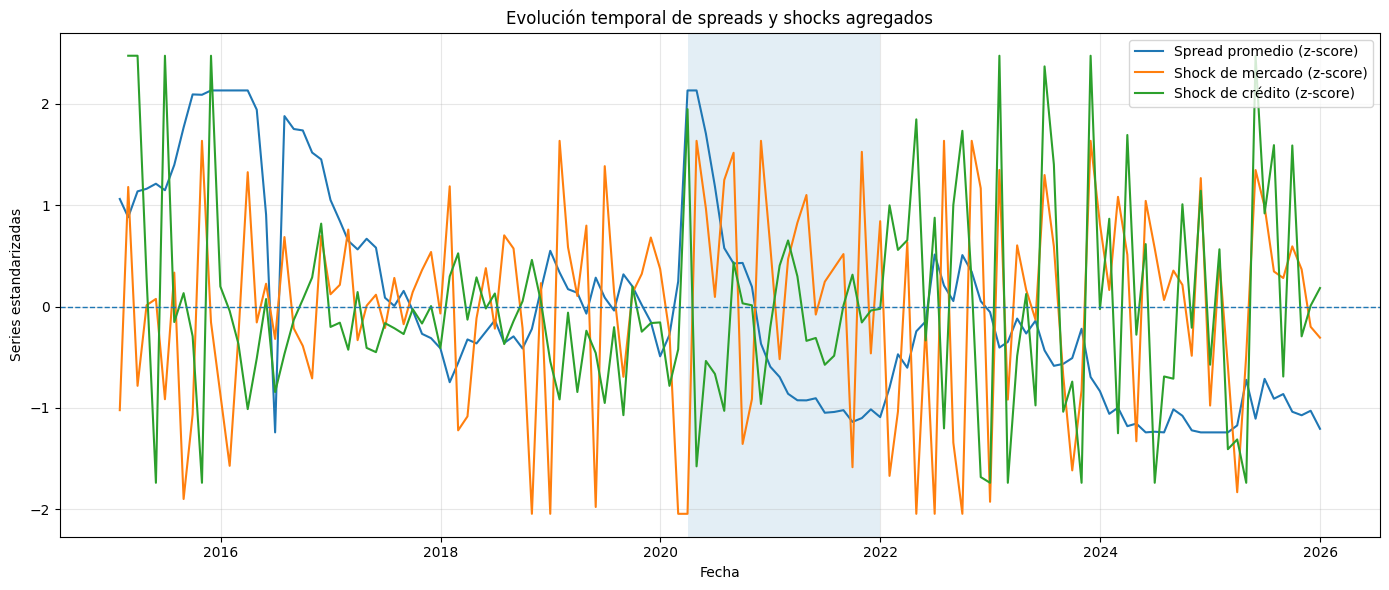

✅ Guardada: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\figures\fig_16_1_evolucion_temporal_spreads_y_shocks_clean.png


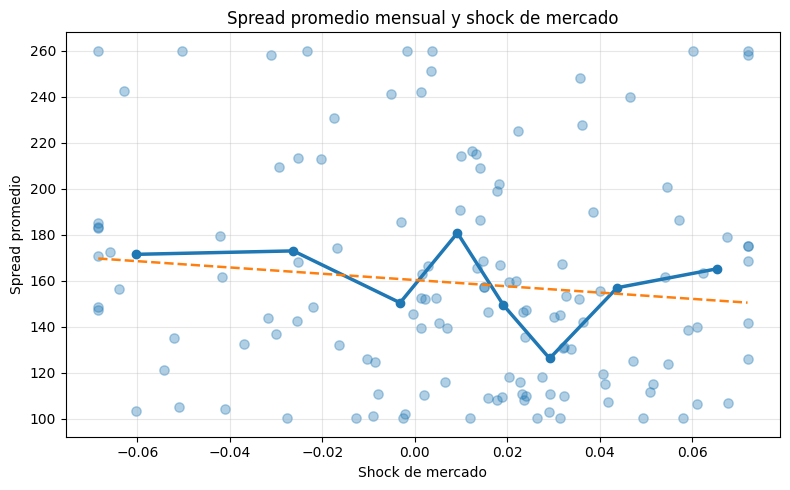

✅ Guardada: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\figures\fig_16_2_market_spread_relation_clean.png


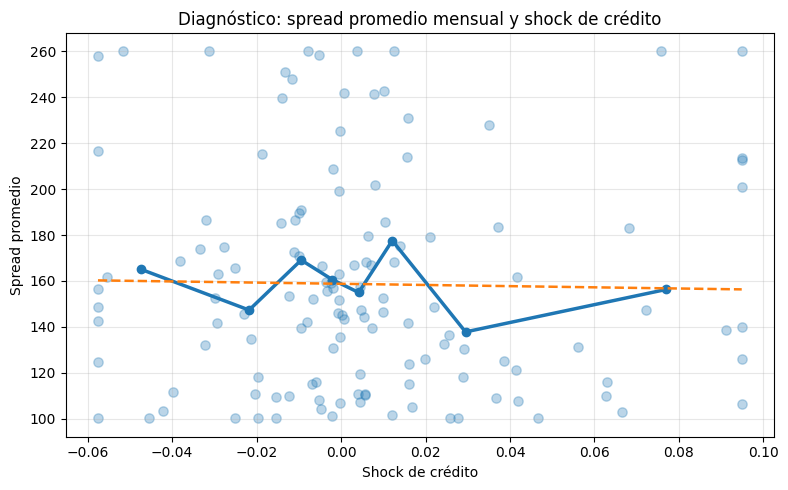

✅ Guardada: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\figures\fig_16_2B_credit_spread_relation_clean.png


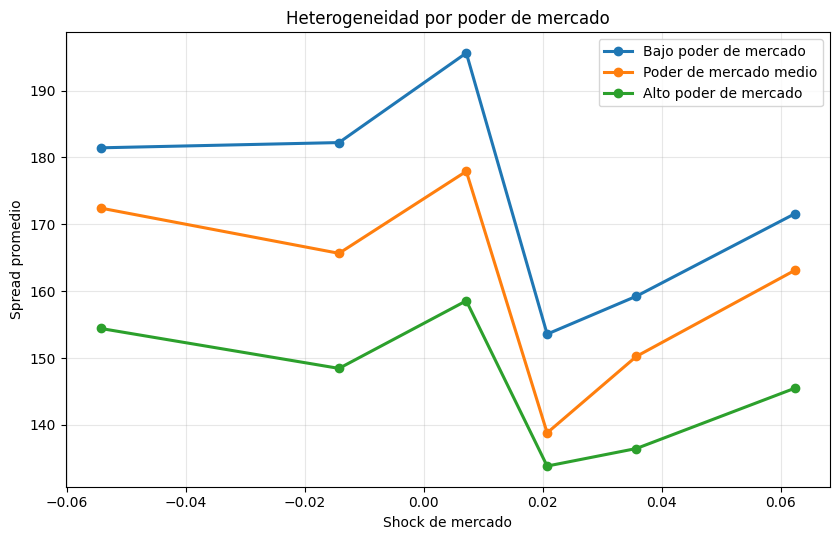

✅ Guardada: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\figures\fig_16_3_heterogeneidad_market_power_bins_clean.png

=== FIGURAS GENERADAS ===
- fig_16_1_evolucion_temporal_spreads_y_shocks_clean.png
- fig_16_2_market_binscatter_clean.csv
- fig_16_2_market_spread_relation_clean.png
- fig_16_2B_credit_binscatter_clean.csv
- fig_16_2B_credit_spread_relation_clean.png
- fig_16_3_heterogeneidad_market_power_bins_clean.png
- fig_16_3_market_power_bins_clean_data.csv
- fig_16_monthly_aggregated_data_raw_and_clean.csv


In [31]:
# ==========================================================
# 16. FIGURAS DESCRIPTIVAS PARA TESIS — VERSIÓN REVISADA
# Limpieza de outliers + foco en mercado + heterogeneidad más limpia
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------------------------
# 0) Parámetros
# -------------------------------------------------
WINSOR_P = 0.05                 # winsorización mensual al 5%-95%
N_BINS = 8                      # bins para binscatter
MIN_ISSUERS_MONTH = 8           # mínimo de emisores para incluir un mes en figuras agregadas
MIN_ISSUERS_TERCILE_MONTH = 3   # mínimo de emisores por tercil y mes en figura de heterogeneidad
EXPORT_DIAGNOSTIC_CREDIT = True # guarda figura secundaria para shock de crédito

# -------------------------------------------------
# 1) Paths y load panel final
# -------------------------------------------------
FIGURES = OUTPUTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

PANEL_FINAL = CLEAN / "panel_master.parquet"
if not PANEL_FINAL.exists():
    raise FileNotFoundError(f"No encontré {PANEL_FINAL}")

panel = pd.read_parquet(PANEL_FINAL).copy()
panel["date"] = pd.to_datetime(panel["date"], errors="coerce").dt.to_period("M").dt.to_timestamp("M")

print("✅ Panel cargado:", PANEL_FINAL)
print("Shape:", panel.shape)

# -------------------------------------------------
# 2) Helpers
# -------------------------------------------------
def pick_first_existing(df: pd.DataFrame, candidates: list[str], label: str) -> str:
    for c in candidates:
        if c in df.columns:
            print(f"✔ {label}: usando '{c}'")
            return c
    raise ValueError(f"No encontré ninguna columna válida para {label}: {candidates}")

def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)

def winsorize_series(s: pd.Series, p: float = 0.05) -> pd.Series:
    s = to_num(s)
    if s.dropna().empty:
        return s
    lo = s.quantile(p)
    hi = s.quantile(1 - p)
    return s.clip(lower=lo, upper=hi)

def zscore(s: pd.Series) -> pd.Series:
    s = to_num(s)
    std = s.std()
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - s.mean()) / std

def add_covid_shading(ax, df_time: pd.DataFrame, covid_col: str | None):
    if covid_col is None or covid_col not in df_time.columns:
        return

    covid_dates = df_time.loc[df_time[covid_col] == 1, "date"].sort_values().tolist()
    if len(covid_dates) == 0:
        return

    start = covid_dates[0]
    prev = covid_dates[0]

    for d in covid_dates[1:]:
        if (d.to_period("M") - prev.to_period("M")).n != 1:
            ax.axvspan(start, prev, alpha=0.12)
            start = d
        prev = d

    ax.axvspan(start, prev, alpha=0.12)

def build_binscatter(df: pd.DataFrame, x: str, y: str, n_bins: int = 8) -> pd.DataFrame:
    tmp = df[[x, y]].copy()
    tmp[x] = to_num(tmp[x])
    tmp[y] = to_num(tmp[y])
    tmp = tmp.dropna()

    if tmp.empty or tmp[x].nunique() < 2:
        return pd.DataFrame(columns=[x, y, "n_obs"])

    n_bins = int(min(n_bins, max(3, tmp[x].nunique())))

    try:
        tmp["bin"] = pd.qcut(tmp[x], q=n_bins, duplicates="drop")
    except ValueError:
        tmp["bin"] = pd.cut(tmp[x], bins=min(5, tmp[x].nunique()))

    out = (
        tmp.groupby("bin", observed=False)
           .agg(
               **{
                   x: (x, "mean"),
                   y: (y, "mean"),
                   "n_obs": (y, "size")
               }
           )
           .reset_index(drop=True)
           .sort_values(x)
    )
    return out

def fit_line(x: pd.Series, y: pd.Series):
    tmp = pd.DataFrame({"x": x, "y": y}).copy()
    tmp["x"] = to_num(tmp["x"])
    tmp["y"] = to_num(tmp["y"])
    tmp = tmp.dropna()

    if len(tmp) < 3 or tmp["x"].nunique() < 2:
        return None

    x_vals = tmp["x"].astype(float).to_numpy()
    y_vals = tmp["y"].astype(float).to_numpy()

    b1, b0 = np.polyfit(x_vals, y_vals, deg=1)
    xs = np.linspace(x_vals.min(), x_vals.max(), 100)
    ys = b1 * xs + b0
    return xs, ys, b1, b0

# -------------------------------------------------
# 3) Definir variables a usar
# -------------------------------------------------
spread_var = pick_first_existing(
    panel,
    ["oas_mean", "spread_mean_bps"],
    "spread principal para figuras"
)

market_shock_var = pick_first_existing(
    panel,
    ["mkt_ret"],
    "shock de mercado"
)

credit_shock_var = pick_first_existing(
    panel,
    ["credit_level", "crc_level_beta"],
    "shock de crédito"
)

market_power_var = pick_first_existing(
    panel,
    [
        "market_share_industry_group",
        "market_share_industry",
        "market_share_sector",
        "market_share_subindustry",
        "market_share_w",
        "market_share_raw",
    ],
    "proxy de poder de mercado"
)

covid_var = "covid_dummy" if "covid_dummy" in panel.columns else None

if "issuer" not in panel.columns:
    raise ValueError("El panel no tiene columna 'issuer'; esta sección la necesita.")

# -------------------------------------------------
# 4) Base mensual agregada
# -------------------------------------------------
monthly = (
    panel.groupby("date", as_index=False)
         .agg(
             spread_avg=(spread_var, "mean"),
             mkt_ret=(market_shock_var, "first"),
             credit_level=(credit_shock_var, "first"),
             covid_dummy=(covid_var, "max") if covid_var else (spread_var, lambda x: np.nan),
             n_issuers=("issuer", "nunique")
         )
         .sort_values("date")
         .reset_index(drop=True)
)

for c in ["spread_avg", "mkt_ret", "credit_level", "covid_dummy", "n_issuers"]:
    if c in monthly.columns:
        monthly[c] = to_num(monthly[c])

monthly["keep_for_plots"] = (monthly["n_issuers"] >= MIN_ISSUERS_MONTH).astype(int)

# Winsorización para gráficos
monthly["spread_avg_w"] = winsorize_series(monthly["spread_avg"], WINSOR_P)
monthly["mkt_ret_w"] = winsorize_series(monthly["mkt_ret"], WINSOR_P)
monthly["credit_level_w"] = winsorize_series(monthly["credit_level"], WINSOR_P)

# Estandarización luego de winsorizar
monthly["spread_z"] = zscore(monthly["spread_avg_w"])
monthly["mkt_ret_z"] = zscore(monthly["mkt_ret_w"])
monthly["credit_level_z"] = zscore(monthly["credit_level_w"])

print("\n=== BASE MENSUAL AGREGADA ===")
print(monthly.head())
print("\nNaN share:")
print(monthly[["spread_avg", "mkt_ret", "credit_level"]].isna().mean().round(4))
print("\nMeses totales:", len(monthly))
print("Meses usados en gráficos agregados:", int(monthly["keep_for_plots"].sum()))
print("Meses excluidos por pocos emisores:", int((monthly["keep_for_plots"] == 0).sum()))

monthly.to_csv(FIGURES / "fig_16_monthly_aggregated_data_raw_and_clean.csv", index=False)

monthly_plot = monthly.loc[monthly["keep_for_plots"] == 1].copy()

# -------------------------------------------------
# 5) Figura 16.1 — Evolución temporal limpia
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_plot["date"], monthly_plot["spread_z"], label="Spread promedio (z-score)")
ax.plot(monthly_plot["date"], monthly_plot["mkt_ret_z"], label="Shock de mercado (z-score)")
ax.plot(monthly_plot["date"], monthly_plot["credit_level_z"], label="Shock de crédito (z-score)")

add_covid_shading(ax, monthly_plot, "covid_dummy" if covid_var else None)

ax.axhline(0, linewidth=1, linestyle="--")
ax.set_title("Evolución temporal de spreads y shocks agregados")
ax.set_xlabel("Fecha")
ax.set_ylabel("Series estandarizadas")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "fig_16_1_evolucion_temporal_spreads_y_shocks_clean.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Guardada:", FIGURES / "fig_16_1_evolucion_temporal_spreads_y_shocks_clean.png")

# -------------------------------------------------
# 6) Figura 16.2 — Relación descriptiva principal
# Solo shock de mercado (figura para tesis)
# -------------------------------------------------
bins_mkt = build_binscatter(monthly_plot, "mkt_ret_w", "spread_avg_w", n_bins=N_BINS)
bins_mkt.to_csv(FIGURES / "fig_16_2_market_binscatter_clean.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    monthly_plot["mkt_ret_w"],
    monthly_plot["spread_avg_w"],
    alpha=0.35,
    s=45
)
ax.plot(
    bins_mkt["mkt_ret_w"],
    bins_mkt["spread_avg_w"],
    marker="o",
    linewidth=2.5
)

fit_mkt = fit_line(monthly_plot["mkt_ret_w"], monthly_plot["spread_avg_w"])
if fit_mkt is not None:
    xs, ys, _, _ = fit_mkt
    ax.plot(xs, ys, linewidth=1.8, linestyle="--")

ax.set_title("Spread promedio mensual y shock de mercado")
ax.set_xlabel("Shock de mercado")
ax.set_ylabel("Spread promedio")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "fig_16_2_market_spread_relation_clean.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Guardada:", FIGURES / "fig_16_2_market_spread_relation_clean.png")

# -------------------------------------------------
# 6B) Figura diagnóstica — shock de crédito
# No la tomaría como principal salvo que quede convincente
# -------------------------------------------------
if EXPORT_DIAGNOSTIC_CREDIT:
    bins_credit = build_binscatter(monthly_plot, "credit_level_w", "spread_avg_w", n_bins=N_BINS)
    bins_credit.to_csv(FIGURES / "fig_16_2B_credit_binscatter_clean.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(
        monthly_plot["credit_level_w"],
        monthly_plot["spread_avg_w"],
        alpha=0.30,
        s=45
    )
    ax.plot(
        bins_credit["credit_level_w"],
        bins_credit["spread_avg_w"],
        marker="o",
        linewidth=2.5
    )

    fit_credit = fit_line(monthly_plot["credit_level_w"], monthly_plot["spread_avg_w"])
    if fit_credit is not None:
        xs, ys, _, _ = fit_credit
        ax.plot(xs, ys, linewidth=1.8, linestyle="--")

    ax.set_title("Diagnóstico: spread promedio mensual y shock de crédito")
    ax.set_xlabel("Shock de crédito")
    ax.set_ylabel("Spread promedio")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES / "fig_16_2B_credit_spread_relation_clean.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("✅ Guardada:", FIGURES / "fig_16_2B_credit_spread_relation_clean.png")

# -------------------------------------------------
# 7) Figura 16.3 — Heterogeneidad revisada
# Binscatter por terciles de market power y shock de mercado
# -------------------------------------------------
firm_mp = (
    panel.groupby("issuer", as_index=False)
         .agg(mp_avg=(market_power_var, "mean"))
         .dropna()
)

if firm_mp.empty:
    raise ValueError(f"No hay datos disponibles para construir terciles con {market_power_var}.")

labels = ["Bajo poder de mercado", "Poder de mercado medio", "Alto poder de mercado"]

try:
    firm_mp["mp_tercile"] = pd.qcut(firm_mp["mp_avg"], q=3, labels=labels, duplicates="drop")
except ValueError:
    ranks = firm_mp["mp_avg"].rank(method="first")
    firm_mp["mp_tercile"] = pd.qcut(ranks, q=3, labels=labels)

panel_het = panel.merge(
    firm_mp[["issuer", "mp_tercile"]],
    on="issuer",
    how="left",
    validate="m:1"
)

monthly_het = (
    panel_het.groupby(["date", "mp_tercile"], as_index=False, observed=False)
             .agg(
                 spread_avg=(spread_var, "mean"),
                 mkt_ret=(market_shock_var, "first"),
                 n_issuers=("issuer", "nunique")
             )
)

for c in ["spread_avg", "mkt_ret", "n_issuers"]:
    if c in monthly_het.columns:
        monthly_het[c] = to_num(monthly_het[c])

monthly_het = monthly_het.loc[monthly_het["n_issuers"] >= MIN_ISSUERS_TERCILE_MONTH].copy()

# winsorización dentro de cada tercil
monthly_het["spread_avg_w"] = (
    monthly_het.groupby("mp_tercile", observed=False)["spread_avg"]
               .transform(lambda s: winsorize_series(s, WINSOR_P))
)
monthly_het["mkt_ret_w"] = (
    monthly_het.groupby("mp_tercile", observed=False)["mkt_ret"]
               .transform(lambda s: winsorize_series(s, WINSOR_P))
)

monthly_het.to_csv(FIGURES / "fig_16_3_market_power_bins_clean_data.csv", index=False)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

for grp in labels:
    sub = monthly_het.loc[monthly_het["mp_tercile"] == grp].copy()
    if sub.empty:
        continue

    bins_sub = build_binscatter(sub, "mkt_ret_w", "spread_avg_w", n_bins=6)
    if bins_sub.empty:
        continue

    ax.plot(
        bins_sub["mkt_ret_w"],
        bins_sub["spread_avg_w"],
        marker="o",
        linewidth=2.2,
        label=grp
    )

ax.set_title("Heterogeneidad por poder de mercado")
ax.set_xlabel("Shock de mercado")
ax.set_ylabel("Spread promedio")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / "fig_16_3_heterogeneidad_market_power_bins_clean.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Guardada:", FIGURES / "fig_16_3_heterogeneidad_market_power_bins_clean.png")

# -------------------------------------------------
# 8) Resumen final
# -------------------------------------------------
print("\n=== FIGURAS GENERADAS ===")
for f in sorted(FIGURES.glob("fig_16_*")):
    print("-", f.name)